# 1. Двухстадийная модель прогнозирования GMV

Модель состоит из двух частей:

1. классификатор оценивает вероятность положительного GMV в следующие 30 дней;
2. регрессор оценивает размер GMV при условии, что он положительный.

Гиперпараметры двух стадий настраиваются в отдельных Optuna-study. Итоговая связка выбирается по end-to-end RMSLE на последовательных временных фолдах.

## 2. Окружение и воспроизводимость

Notebook запускается из папки `notebooks/modeling/two_stage`. Вспомогательные
модули находятся в соседнем пакете `src` и импортируются напрямую.

Подготовка окружения разделена на три шага:

1. проверка рабочей директории и доступности `src`;
2. импорт библиотек и helpers;
3. конфигурация эксперимента и отчёт о версиях.

In [1]:
import sys
from pathlib import Path

MODEL_DIR = Path.cwd().resolve()
SRC_DIR = MODEL_DIR / "src"
SRC_INIT = SRC_DIR / "__init__.py"

if not SRC_INIT.is_file():
    raise FileNotFoundError(
        "Notebook должен запускаться из 'notebooks/modeling/two_stage'"
    )
    
if str(MODEL_DIR) not in sys.path:
    sys.path.insert(0, str(MODEL_DIR))

In [2]:
import os
import random
from datetime import date
from importlib.metadata import version as package_version

import lightgbm as lgb
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import pyarrow.dataset as ds
import shap
from src.artifacts import (
    load_json,
    load_submission_csv,
    save_json,
    save_lightgbm_model,
    save_submission_csv,
)
from src.data_io import find_project_root
from src.inference import (
    combine_two_stage_predictions,
    predict_two_stage,
)
from src.metrics import (
    classification_metrics,
    make_soft_pipeline_rmsle_metric,
    pipeline_metrics,
    positive_regression_metrics,
    rmsle,
)
from src.validation import (
    make_submission,
    validate_feature_matrix,
    validate_submission,
    validate_temporal_split,
)


loaded_src_file = getattr(
    sys.modules["src"],
    "__file__",
    None,
)

if (
    loaded_src_file is None
    or Path(loaded_src_file).resolve() != SRC_INIT.resolve()
):
    raise ImportError(
        "Загружен другой пакет src. "
        "Перезапустите kernel из папки модели."
    )

c:\Users\savin\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Воспроизводимость
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


# Ресурсы и бюджет обучения
CPU_COUNT = os.cpu_count() or 1
LIGHTGBM_NUM_THREADS = max(1, min(10, CPU_COUNT - 2))
OPTUNA_N_JOBS = 1

N_TRIALS_CLASSIFIER = 40
N_TRIALS_REGRESSOR = 40
MAX_BOOST_ROUNDS = 5_000
EARLY_STOPPING_ROUNDS = 150
SHAP_SAMPLE_SIZE = 20_000


# Временная схема
TUNING_FOLDS = (
    {
        "name": "fold_1",
        "train_end": date(2025, 9, 16),
        "valid_date": date(2025, 10, 16),
    },
    {
        "name": "fold_2",
        "train_end": date(2025, 10, 16),
        "valid_date": date(2025, 11, 15),
    },
    {
        "name": "fold_3",
        "train_end": date(2025, 11, 15),
        "valid_date": date(2025, 12, 15),
    },
)

HOLDOUT_DATE = date(2026, 1, 14)
INFERENCE_DATE = date(2026, 2, 13)
FORECAST_START = date(2026, 2, 14)
FORECAST_END = date(2026, 3, 15)


# Пути
PROJECT_ROOT = find_project_root(MODEL_DIR)
DATA_PATH = PROJECT_ROOT / "data" / "Prepared_data.parquet"
ARTIFACT_DIR = PROJECT_ROOT / "data" / "two_stage_artifacts"


# Оформление графиков
plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "figure.dpi": 120,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)


# Версии окружения
versions = pd.Series(
    {
        package: package_version(distribution)
        for package, distribution in {
            "NumPy": "numpy",
            "pandas": "pandas",
            "PyArrow": "pyarrow",
            "LightGBM": "lightgbm",
            "Optuna": "optuna",
            "SHAP": "shap",
            "scikit-learn": "scikit-learn",
            "Matplotlib": "matplotlib",
        }.items()
    },
    name="version",
).to_frame()

versions.loc["Python"] = sys.version.split()[0]

print(f"Dataset: {DATA_PATH}")
print(f"LightGBM threads: {LIGHTGBM_NUM_THREADS}")
display(versions)

Dataset: C:\Users\savin\OneDrive\Документы\Мои документы\Проекты\E-Cup 2026\E-CUP-2026\data\Prepared_data.parquet
LightGBM threads: 10


,version
NumPy,2.3.3
pandas,2.3.3
PyArrow,25.0.1
LightGBM,4.6.0
Optuna,4.8.0
SHAP,0.52.0
scikit-learn,1.8.0
Matplotlib,3.10.7
Python,3.14.0


## 3. Схема и временные срезы данных

Сначала читаем только схему и две небольшие колонки: дату среза и бинарный target. Это позволяет проверить структуру датасета до загрузки матрицы признаков в память.

In [4]:
import pyarrow.parquet as pq


SERVICE_COLUMNS = ("user_id", "cutoff_date")
TARGET_COLUMNS = ("target_gmv_30d", "target_nonzero")
EXPECTED_FEATURE_COUNT = 91


prepared_dataset = ds.dataset(
    DATA_PATH,
    format="parquet",
)
parquet_file = pq.ParquetFile(DATA_PATH)

schema = prepared_dataset.schema
required_columns = set(SERVICE_COLUMNS + TARGET_COLUMNS)
missing_columns = required_columns - set(schema.names)

assert not missing_columns, (
    f"Отсутствуют колонки: {sorted(missing_columns)}"
)


FEATURE_COLUMNS = tuple(
    column
    for column in schema.names
    if column not in required_columns
)

assert len(FEATURE_COLUMNS) == EXPECTED_FEATURE_COUNT, (
    f"Ожидалось {EXPECTED_FEATURE_COUNT} признаков, "
    f"получено {len(FEATURE_COLUMNS)}"
)


cutoff_summary = (
    prepared_dataset
    .to_table(
        columns=[
            "cutoff_date",
            "target_nonzero",
        ]
    )
    .group_by("cutoff_date")
    .aggregate(
        [
            ("cutoff_date", "count"),
            ("target_nonzero", "count"),
            ("target_nonzero", "mean"),
        ]
    )
    .to_pandas()
    .rename(
        columns={
            "cutoff_date_count": "rows",
            "target_nonzero_count": "labeled_rows",
            "target_nonzero_mean": "positive_share",
        }
    )
    .sort_values("cutoff_date")
    .reset_index(drop=True)
)

cutoff_summary["cutoff_date"] = pd.to_datetime(
    cutoff_summary["cutoff_date"]
).dt.date


dataset_summary = pd.Series(
    {
        "rows": parquet_file.metadata.num_rows,
        "columns": len(schema.names),
        "features": len(FEATURE_COLUMNS),
        "cutoffs": len(cutoff_summary),
        "size_gb": DATA_PATH.stat().st_size / 1024**3,
    },
    name="value",
).to_frame()

display(dataset_summary)
display(cutoff_summary)

,value
rows,2.597330e+06
columns,9.500000e+01
features,9.100000e+01
cutoffs,1.100000e+01
size_gb,3.397297e-01


,cutoff_date,rows,labeled_rows,positive_share
0,2025-04-19,216457,216457,0.472080
1,2025-05-19,221154,221154,0.482533
2,2025-06-18,225245,225245,0.494204
3,2025-07-18,229146,229146,0.511032
4,2025-08-17,232977,232977,0.528387
5,2025-09-16,236668,236668,0.536258
6,2025-10-16,240700,240700,0.545858
7,2025-11-15,244983,244983,0.569435
8,2025-12-15,250000,250000,0.563080
9,2026-01-14,250000,250000,0.540660


## 4. Загрузка размеченных данных

Загружаем все размеченные срезы до `HOLDOUT_DATE` включительно. Признаки и target читаются отдельно, чтобы снизить пиковое потребление памяти.

In [5]:
import gc

LABELED_FILTER = (
    ds.field("cutoff_date") <= HOLDOUT_DATE
)

expected_labeled_rows = int(
    cutoff_summary.loc[
        cutoff_summary["cutoff_date"] <= HOLDOUT_DATE,
        "rows",
    ].sum()
)

# Даты и целевые переменные для обучения и валидации
target_table = prepared_dataset.to_table(
    columns=[
        "cutoff_date",
        "target_nonzero",
        "target_gmv_30d",
    ],
    filter=LABELED_FILTER
)

cutoff_dates = pd.to_datetime(
    target_table.column("cutoff_date").to_pandas()
)

y_nonzero = (
    target_table["target_nonzero"].to_numpy(zero_copy_only=False).astype(np.int8, copy=False)
)

y_gmv = (
    target_table["target_gmv_30d"].to_numpy(zero_copy_only=False).astype(np.float64, copy=False)
)

del target_table
gc.collect()

# Матрица признаков
feature_table = prepared_dataset.to_table(
    columns=list(FEATURE_COLUMNS),
    filter=LABELED_FILTER
)

X = feature_table.to_pandas(split_blocks=True)
del feature_table
gc.collect()

# Основной контракт загрузки данных
validate_feature_matrix(X, FEATURE_COLUMNS)

assert (
    len(X)
    == len(cutoff_dates)
    == len(y_nonzero)
    == len(y_gmv)
    == expected_labeled_rows
)

loaded_data_summary = pd.Series(
    {
        "rows": len(X),
        "features": X.shape[1],
        "memory_gb": (X.memory_usage(deep=True, index=True).sum() / 1024**3),
        "cutoff_min": cutoff_dates.min().date(),
        "cutoff_max": cutoff_dates.max().date(),
        "positive_share": y_nonzero.mean(),
        "holdout_rows": (
            cutoff_dates.dt.date == HOLDOUT_DATE
        ).sum(),
    },
    name="value",
).to_frame()

display(loaded_data_summary)

,value
rows,2347330
features,91
memory_gb,0.762956
cutoff_min,2025-04-19
cutoff_max,2026-01-14
positive_share,0.525771
holdout_rows,250000


## 5. Проверка качества данных

Проверяем согласованность двух целевых переменных и оцениваем пропуски в признаках. `NaN` сохраняем: LightGBM обрабатывает их напрямую.

In [6]:
# Контракт целевых переменных
assert np.isfinite(y_gmv).all()
assert (y_gmv >= 0).all()
assert np.isin(y_nonzero, [0, 1]).all()
assert np.array_equal(
    y_nonzero,
    (y_gmv > 0).astype(np.int8),
)


# Пропуски считаем по одной колонке,
# не создавая большую boolean-матрицу.
missing_share = pd.Series(
    {
        column: X[column].isna().mean()
        for column in FEATURE_COLUMNS
    },
    name="missing_share",
).sort_values(ascending=False)

features_with_missing = missing_share[
    missing_share > 0
]


quality_summary = pd.Series(
    {
        "rows": len(X),
        "positive_rows": int(y_nonzero.sum()),
        "positive_share": y_nonzero.mean(),
        "zero_gmv_rows": int((y_gmv == 0).sum()),
        "features_with_missing": len(
            features_with_missing
        ),
        "maximum_missing_share": (
            missing_share.max()
        ),
    },
    name="value",
).to_frame()

display(quality_summary)
display(
    features_with_missing
    .head(20)
    .to_frame()
)

,value
rows,2.347330e+06
positive_rows,1.234159e+06
positive_share,5.257714e-01
zero_gmv_rows,1.113171e+06
features_with_missing,2.600000e+01
maximum_missing_share,4.856923e-01


,missing_share
purchase_velocity_7d_vs_30d,0.485692
search_gmv_share_30d,0.485692
category_cart_to_purchase_rate,0.441753
median_purchase_gap_days,0.306660
recency_ratio,0.306660
search_gmv_share_90d,0.303235
cart_velocity_7d_vs_30d,0.261570
search_gmv_share,0.208121
gmv_per_item,0.208121
search_to_purchase_freq,0.208121


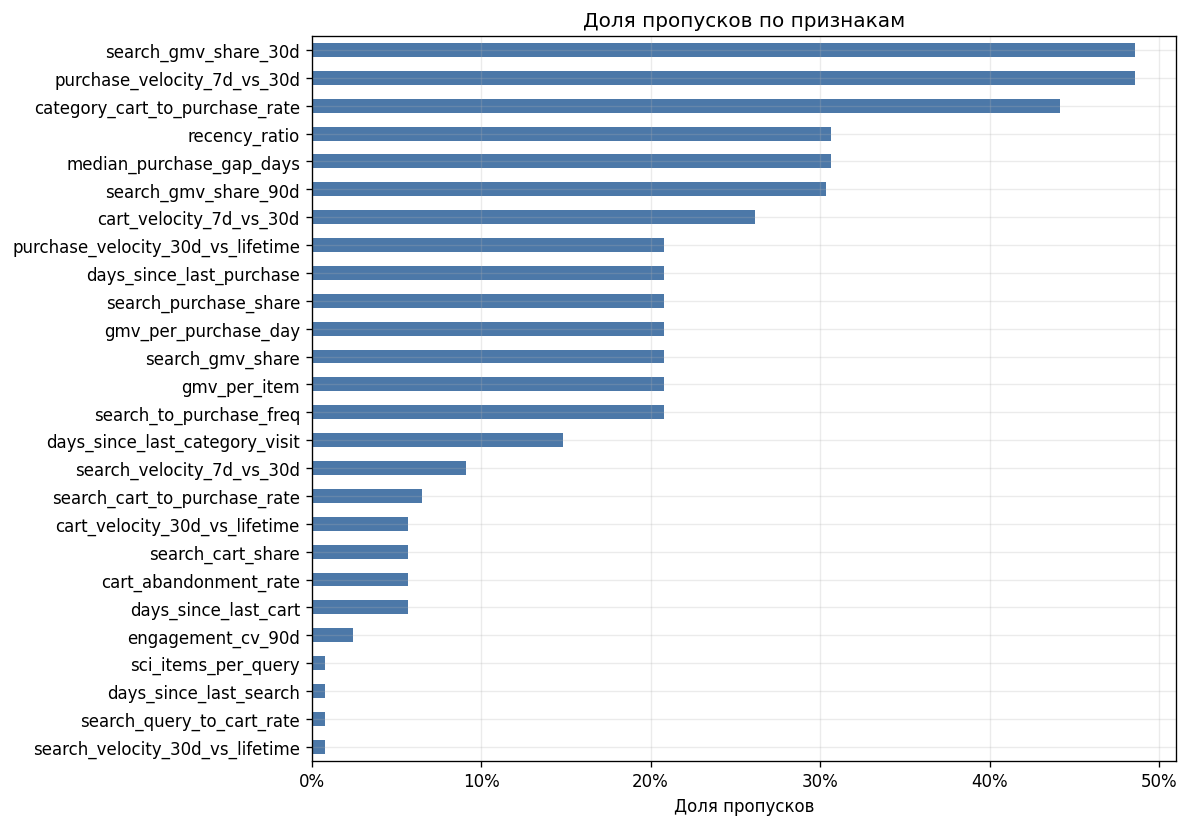

In [7]:
plot_data = features_with_missing.sort_values()

ax = plot_data.plot.barh(
    figsize=(10, 7),
    color="#4C78A8",
)

ax.set_title("Доля пропусков по признакам")
ax.set_xlabel("Доля пропусков")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(
    matplotlib.ticker.PercentFormatter(1.0)
)

plt.tight_layout()
plt.show()

## 6. Временная валидация

Для настройки модели используем три expanding-window фолда. 
Январский срез полностью изолируется как финальный holdout и не участвует в подборе параметров.

Ожидаемая схема:
- fold_1: обучение до сентября, валидация - октябрь
- fold_2: обучение до октября, валидация - ноябрь
- fold_3: обучение до ноября, валидация - декабрь
- holdout: обучение до декабря, валидация - январь

In [8]:
assert cutoff_dates.is_monotonic_increasing

TUNING_SPLITS = {}
split_records = []

for fold in TUNING_FOLDS:
    train_end = pd.Timestamp(fold["train_end"])
    valid_date = pd.Timestamp(fold["valid_date"])
    
    train_slice = slice(
        0,
        cutoff_dates.searchsorted(train_end, side="right")
    )
    train_dates = cutoff_dates.iloc[train_slice]
    
    valid_slice = slice(
        cutoff_dates.searchsorted(valid_date, side="left"),
        cutoff_dates.searchsorted(valid_date, side="right")
    )
    valid_dates = cutoff_dates.iloc[valid_slice]
    
    validate_temporal_split(train_dates, valid_dates)
    
    TUNING_SPLITS[fold["name"]] = {
        "train": train_slice,
        "valid": valid_slice,
    }
    
    split_records.append(
        {
            "split": fold["name"],
            "train_end": train_dates.max().date(),
            "valid_date": valid_dates.min().date(),
            "train_rows": len(train_dates),
            "valid_rows": len(valid_dates),
            "train_positive_share": (
                y_nonzero[train_slice].mean()
            ),
            "valid_positive_share": (
                y_nonzero[valid_slice].mean()
            ),
        }
    )
    

# Закрытый holdout
holdout_start = cutoff_dates.searchsorted(
    pd.Timestamp(HOLDOUT_DATE),
    side="left"
)

HOLDOUT_SPLIT = {
    "train": slice(0, holdout_start),
    "valid": slice(holdout_start, len(X)),
}

holdout_train_dates = cutoff_dates.iloc[HOLDOUT_SPLIT["train"]]
holdout_valid_dates = cutoff_dates.iloc[HOLDOUT_SPLIT["valid"]]
validate_temporal_split(holdout_train_dates, holdout_valid_dates)

split_records.append(
    {
        "split": "holdout",
        "train_end": (holdout_train_dates.max().date()),
        "valid_date": (holdout_valid_dates.min().date()),
        "train_rows": len(holdout_train_dates),
        "valid_rows": len(holdout_valid_dates),
        "train_positive_share": (y_nonzero[HOLDOUT_SPLIT["train"]].mean()),
        "valid_positive_share": (y_nonzero[HOLDOUT_SPLIT["valid"]].mean()),
    }
)


split_summary = (
    pd.DataFrame(split_records)
    .set_index("split")
)

display(split_summary)

,train_end,valid_date,train_rows,valid_rows,train_positive_share,valid_positive_share
split,,,,,,
fold_1,2025-09-16,2025-10-16,1361647,240700,0.504781,0.545858
fold_2,2025-10-16,2025-11-15,1602347,244983,0.510952,0.569435
fold_3,2025-11-15,2025-12-15,1847330,250000,0.518708,0.563080
holdout,2025-12-15,2026-01-14,2097330,250000,0.523997,0.540660


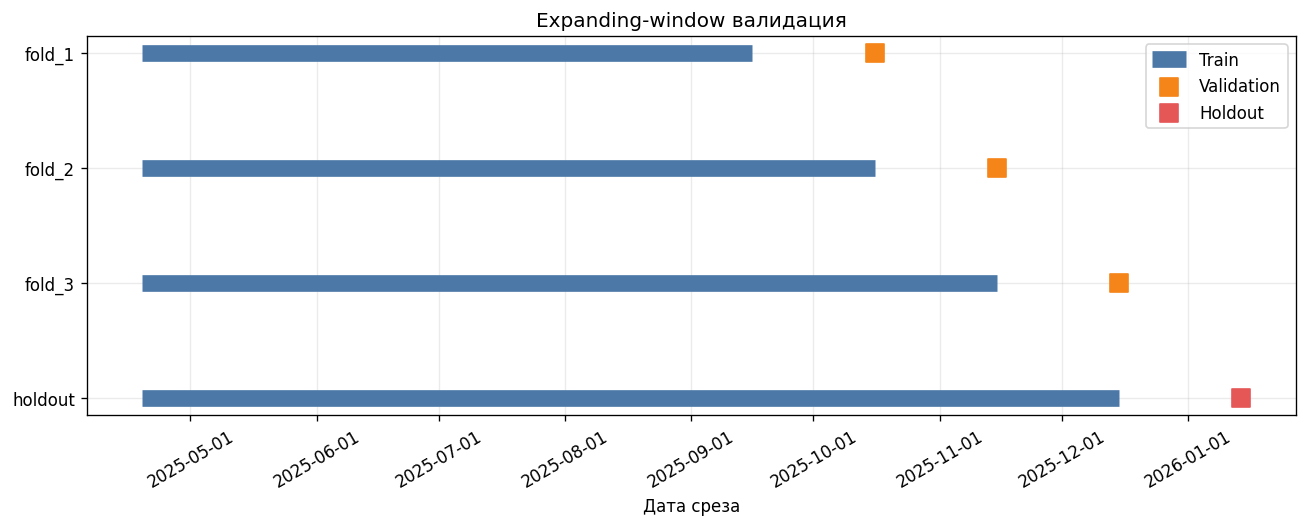

In [9]:
train_start = cutoff_dates.min()

fig, ax = plt.subplots(
    figsize=(11, 4.5)
)

for row_number, (split_name, row) in enumerate(
    split_summary.iterrows()
):
    is_holdout = split_name == "holdout"

    ax.hlines(
        y=row_number,
        xmin=train_start,
        xmax=pd.Timestamp(row["train_end"]),
        linewidth=10,
        color="#4C78A8",
        label=(
            "Train"
            if row_number == 0
            else None
        ),
    )

    ax.scatter(
        pd.Timestamp(row["valid_date"]),
        row_number,
        s=110,
        marker="s",
        color=(
            "#E45756"
            if is_holdout
            else "#F58518"
        ),
        label=(
            "Validation"
            if row_number == 0
            else "Holdout"
            if is_holdout
            else None
        ),
        zorder=3,
    )


ax.set_yticks(
    range(len(split_summary)),
    split_summary.index,
)
ax.invert_yaxis()

ax.set_title(
    "Expanding-window валидация"
)
ax.set_xlabel("Дата среза")
ax.set_ylabel("")

ax.xaxis.set_major_formatter(
    matplotlib.dates.DateFormatter(
        "%Y-%m-%d"
    )
)

ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 7. Smoke-тест двухстадийного пайплайна

Перед полным обучением проверяем обе стадии на небольшой выборке. Smoke-тест должен подтвердить, что обучение, early stopping, прогноз и объединение стадий работают без ошибок.

Почему эти параметры модели:
- random_state - воспроизводимость случайных операций
- n_jobs - явное ограничение используемых CPU
- verbosity=-1 - убирает технический шум
- deterministic=True - усиливает воспроизводимость на CPU
- force_col_wise=True нужен вместе с deterministic=True и помогает контролировать расход памяти. LightGBM рекомендует при детерминированном режиме явно выбирать force_col_wise либо force_row_wise

In [10]:
from time import perf_counter

BASE_LGBM_PARAMS = {
    "random_state": RANDOM_STATE,
    "n_jobs": LIGHTGBM_NUM_THREADS,
    "deterministic": True,
    "force_col_wise": True,
    "verbosity": -1,
}

SMOKE_TRAIN_ROWS = 100_000
SMOKE_VALID_ROWS = 50_000
SMOKE_BOOST_ROUNDS = 500
SMOKE_EARLY_STOPPING_ROUNDS = 50

first_split = TUNING_SPLITS["fold_1"]

smoke_train_slice = slice(
    first_split["train"].stop
    - SMOKE_TRAIN_ROWS,
    first_split["train"].stop,
)

smoke_valid_slice = slice(
    first_split["valid"].start,
    first_split["valid"].start
    + SMOKE_VALID_ROWS,
)

smoke_sample_summary = pd.DataFrame(
    {
        "rows": [
            SMOKE_TRAIN_ROWS,
            SMOKE_VALID_ROWS,
        ],
        "positive_share": [
            y_nonzero[smoke_train_slice].mean(),
            y_nonzero[smoke_valid_slice].mean(),
        ],
    },
    index=["train", "validation"],
)

display(smoke_sample_summary)

,rows,positive_share
train,100000,0.53635
validation,50000,0.54630


In [11]:
X_smoke_train = X.iloc[smoke_train_slice]
y_smoke_train_class = y_nonzero[smoke_train_slice]

X_smoke_valid = X.iloc[smoke_valid_slice]
y_smoke_valid_class = y_nonzero[smoke_valid_slice]


# Обучение классификатора на небольшом подмножестве данных
classifier_started = perf_counter()

smoke_classifier = lgb.LGBMClassifier(
    **BASE_LGBM_PARAMS,
    objective="binary",
    metric="None",
    n_estimators=SMOKE_BOOST_ROUNDS,
)

smoke_classifier.fit(
    X_smoke_train,
    y_smoke_train_class,
    eval_set=[
        (X_smoke_train, y_smoke_train_class),
        (X_smoke_valid, y_smoke_valid_class),
    ],
    eval_names=["train", "validation"],
    eval_metric="binary_logloss",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=(
                SMOKE_EARLY_STOPPING_ROUNDS
            ),
            verbose=False,
        )
    ],
)

# Вероятности положительного GMV
smoke_probability = (
    smoke_classifier.predict_proba(
    X_smoke_valid,
    num_iteration=smoke_classifier.best_iteration_
    )[:, 1]
)

# Метрики для диагностики
smoke_classifier_metrics = pd.Series(
    classification_metrics(
        y_smoke_valid_class,
        smoke_probability,
        threshold=0.5,
    ),
    name="value",
).to_frame()

print("Best iteration:", smoke_classifier.best_iteration_)
print("Training time:", f"{perf_counter() - classifier_started:.1f} sec",)

display(smoke_classifier_metrics)

Best iteration: 48
Training time: 1.4 sec


,value
average_precision,0.883734
logloss,0.468046
brier,0.153883
precision,0.785804
recall,0.803295
f1,0.794453


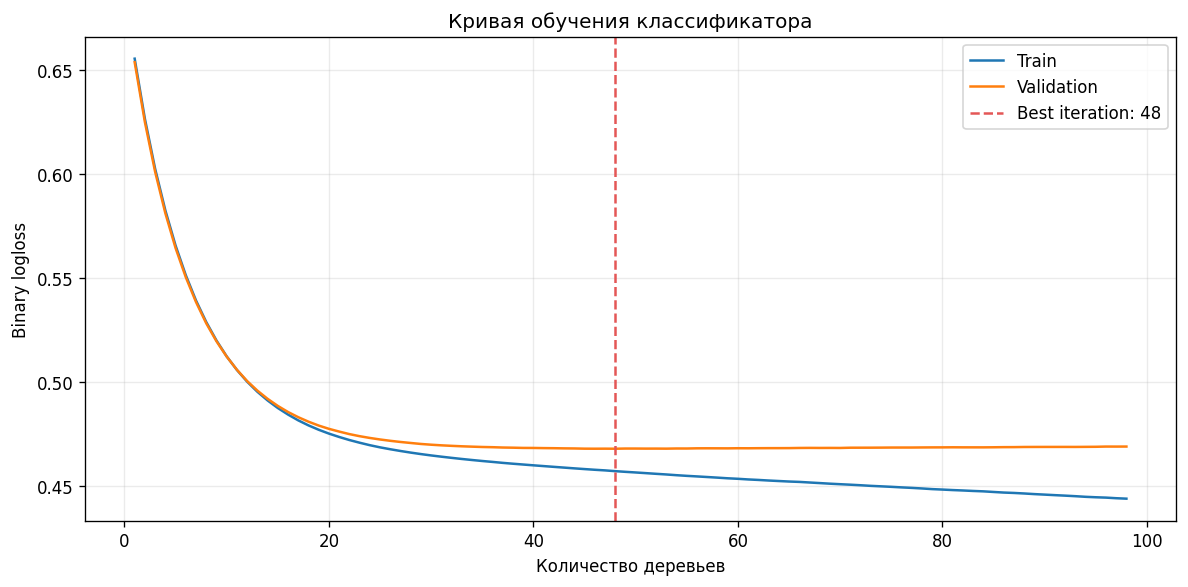

In [12]:
classifier_history = (smoke_classifier.evals_result_)

train_logloss = classifier_history["train"]["binary_logloss"]

valid_logloss = classifier_history["validation"]["binary_logloss"]

iterations = np.arange(1,len(train_logloss) + 1)


fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    iterations,
    train_logloss,
    label="Train",
)

ax.plot(
    iterations,
    valid_logloss,
    label="Validation",
)

ax.axvline(
    smoke_classifier.best_iteration_,
    color="#E45756",
    linestyle="--",
    label=(
        "Best iteration: "
        f"{smoke_classifier.best_iteration_}"
    ),
)

ax.set_title(
    "Кривая обучения классификатора"
)
ax.set_xlabel("Количество деревьев")
ax.set_ylabel("Binary logloss")
ax.legend()

plt.tight_layout()
plt.show()

### Stage 2 - регрессор положительного GMV

Регрессор обучается только на пользователях с положительным GMV и прогнозирует `log1p(GMV)`. При инференсе он применяется ко всем пользователям.

In [13]:
y_smoke_train_gmv = y_gmv[smoke_train_slice]
y_smoke_valid_gmv = y_gmv[smoke_valid_slice]

smoke_train_positive = (y_smoke_train_class == 1)
smoke_valid_positive = (y_smoke_valid_class == 1)

X_smoke_train_positive = X_smoke_train.loc[smoke_train_positive]
X_smoke_valid_positive = X_smoke_valid.loc[smoke_valid_positive]

y_smoke_train_positive_log = np.log1p(
    y_smoke_train_gmv[smoke_train_positive]
)
y_smoke_valid_positive_log = np.log1p(
    y_smoke_valid_gmv[smoke_valid_positive]
)


regressor_started = perf_counter()

smoke_regressor = lgb.LGBMRegressor(
    objective="regression_l2",
    metric="None",
    n_estimators=SMOKE_BOOST_ROUNDS,
    **BASE_LGBM_PARAMS,
)

smoke_regressor.fit(
    X_smoke_train_positive,
    y_smoke_train_positive_log,
    eval_set=[
        (X_smoke_train_positive, y_smoke_train_positive_log),
        (X_smoke_valid_positive, y_smoke_valid_positive_log),
    ],
    eval_names=["train", "validation"],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(
            stopping_rounds=(SMOKE_EARLY_STOPPING_ROUNDS),
            verbose=False,
        )
    ],
)


# Прогноз для всех validation-строк
smoke_predicted_log = smoke_regressor.predict(
    X_smoke_valid,
    num_iteration=(smoke_regressor.best_iteration_),
)


smoke_regressor_metrics = pd.Series(
    positive_regression_metrics(
        y_smoke_valid_gmv[smoke_valid_positive],
        smoke_predicted_log[smoke_valid_positive]
    ),
    name="value",
).to_frame()

print(
    "Best iteration:",
    smoke_regressor.best_iteration_,
)
print(
    "Training time:",
    f"{perf_counter() - regressor_started:.1f} sec",
)

display(smoke_regressor_metrics)

Best iteration: 38
Training time: 0.7 sec


,value
rmse_log,1.125141
mae_log,0.895438
log_bias,0.057233
sum_ratio,0.603559
negative_log_prediction_share,0.000000


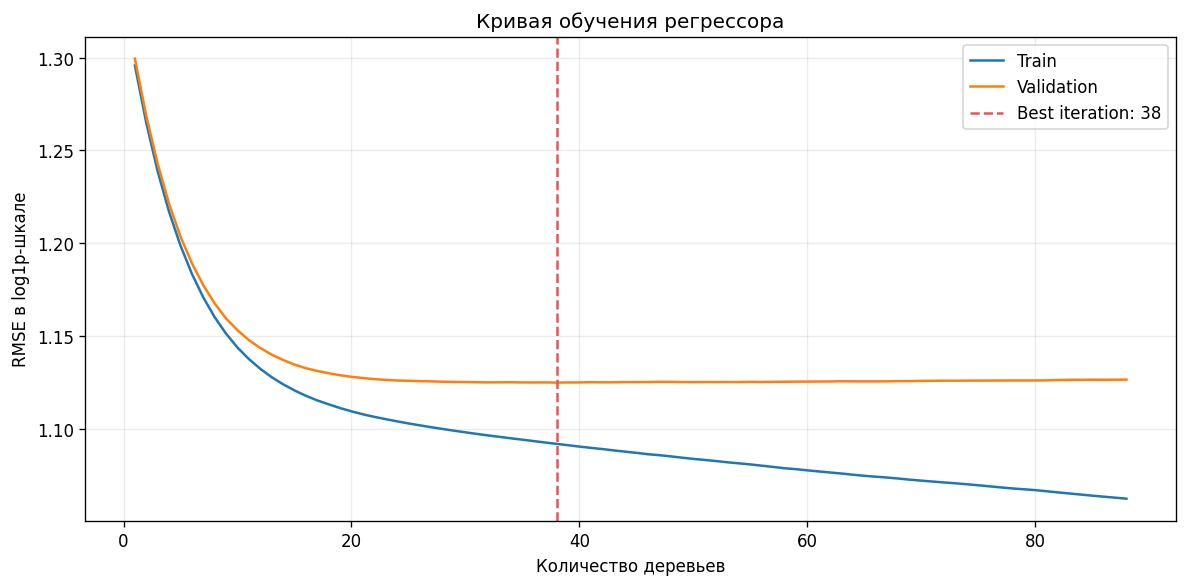

In [14]:
regressor_history = (smoke_regressor.evals_result_)

train_rmse = regressor_history["train"]["rmse"]
valid_rmse = regressor_history["validation"]["rmse"]

iterations = np.arange(
    1,
    len(train_rmse) + 1,
)


fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.plot(
    iterations,
    train_rmse,
    label="Train",
)

ax.plot(
    iterations,
    valid_rmse,
    label="Validation",
)

ax.axvline(
    smoke_regressor.best_iteration_,
    color="#E45756",
    linestyle="--",
    label=(
        "Best iteration: "
        f"{smoke_regressor.best_iteration_}"
    ),
)

ax.set_title(
    "Кривая обучения регрессора"
)
ax.set_xlabel("Количество деревьев")
ax.set_ylabel("RMSE в log1p-шкале")
ax.legend()

plt.tight_layout()
plt.show()

Регрессор работает стабильно:
- validation RMSE достигает минимума на 38-й итерации
- после этого начинается умеренное переобучение
- negative_log_prediction_share = 0 - ограничение снизу пока ничего не меняет
- log_bias = 0.057 означает небольшое завышение в log-шкале
- sum_ratio = 0.604 показывает сильное занижение общей суммы в исходной шкале.

Последние два результата не противоречат друг другу: обучение по RMSE в log1p-шкале сглаживает крупных покупателей, поэтому модель может быть почти несмещённой в логарифмах, но недооценивать денежную сумму из-за тяжёлого хвоста. Для конкурса RMSLE остаётся главным критерием, а sum_ratio - диагностикой.

### Объединение стадий

Сравниваем мягкий RMSLE-ориентированный прогноз, математическое ожидание GMV и жёсткий hurdle. Oracle-вариант показывает потенциальный выигрыш при идеальной классификации.

In [16]:
smoke_predicted_log_clipped = np.maximum(smoke_predicted_log, 0.0)

smoke_positive_gmv = np.expm1(smoke_predicted_log_clipped)


smoke_predictions = {
    "zero_baseline": np.zeros_like(
        y_smoke_valid_gmv
    ),

    "soft_log": combine_two_stage_predictions(
        smoke_probability,
        smoke_predicted_log,
        scale=1.0,
        gamma=1.0,
    ).prediction,

    "expected_gmv": (
        smoke_probability
        * smoke_positive_gmv
    ),

    "hard_threshold_05": np.where(
        smoke_probability >= 0.5,
        smoke_positive_gmv,
        0.0,
    ),

    "oracle_classifier": np.where(
        y_smoke_valid_class == 1,
        smoke_positive_gmv,
        0.0,
    ),
}


smoke_pipeline_metrics = pd.DataFrame(
    {
        method: pipeline_metrics(
            y_smoke_valid_gmv,
            prediction,
        )
        for method, prediction
        in smoke_predictions.items()
    }
).T.sort_values("rmsle")

display(smoke_pipeline_metrics)

,rmsle,sum_ratio,log_bias
oracle_classifier,0.831615,0.603559,0.031267
soft_log,1.718166,0.441275,0.074459
hard_threshold_05,2.012343,0.634423,0.115652
expected_gmv,2.022799,0.608244,0.966824
zero_baseline,3.305260,0.000000,-2.331355


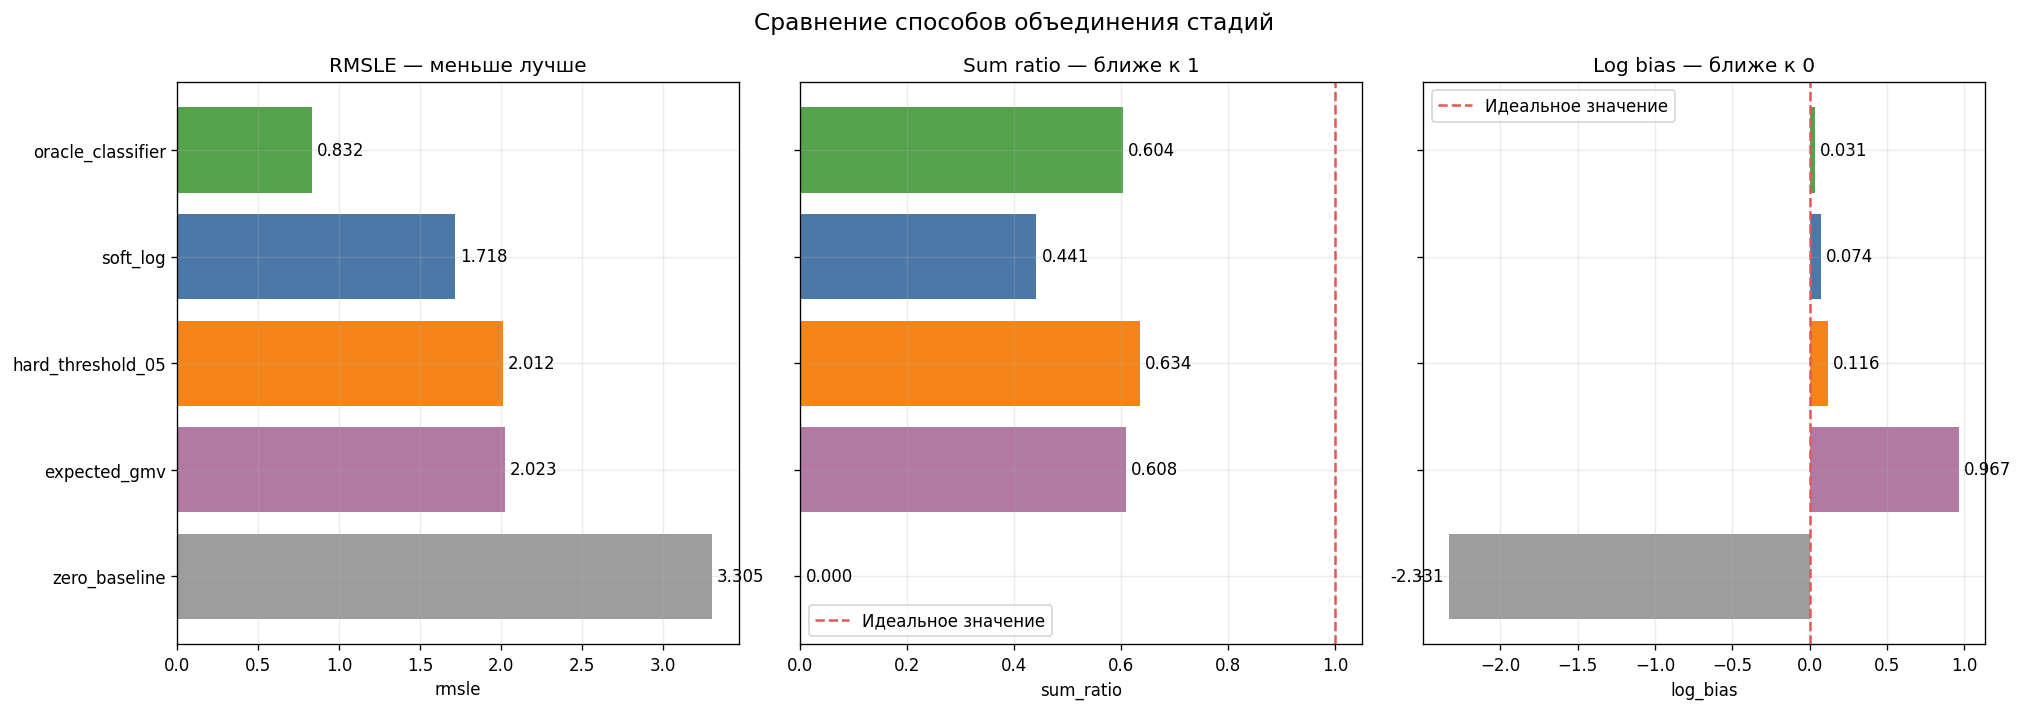

In [17]:
plot_data = smoke_pipeline_metrics[
    [
        "rmsle",
        "sum_ratio",
        "log_bias",
    ]
]

method_colors = {
    "oracle_classifier": "#54A24B",
    "soft_log": "#4C78A8",
    "hard_threshold_05": "#F58518",
    "expected_gmv": "#B279A2",
    "zero_baseline": "#9D9D9D",
}

colors = [
    method_colors[method]
    for method in plot_data.index
]


fig, axes = plt.subplots(
    ncols=3,
    figsize=(17, 6),
    sharey=True,
)

metric_titles = {
    "rmsle": "RMSLE — меньше лучше",
    "sum_ratio": "Sum ratio — ближе к 1",
    "log_bias": "Log bias — ближе к 0",
}


for ax, metric in zip(
    axes,
    plot_data.columns,
):
    bars = ax.barh(
        plot_data.index,
        plot_data[metric],
        color=colors,
    )

    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=3,
    )

    ax.set_title(
        metric_titles[metric]
    )
    ax.set_xlabel(metric)
    ax.grid(
        axis="x",
        alpha=0.25,
    )


axes[1].axvline(
    1.0,
    color="#E45756",
    linestyle="--",
    label="Идеальное значение",
)

axes[2].axvline(
    0.0,
    color="#E45756",
    linestyle="--",
    label="Идеальное значение",
)

axes[1].legend()
axes[2].legend()

axes[0].invert_yaxis()

fig.suptitle(
    "Сравнение способов объединения стадий",
    fontsize=14,
)

plt.tight_layout()
plt.show()

Интерпретация результатов:
- soft_log - лучший реальный вариант: RMSLE 1.718
- hard threshold 0.5 теряет много покупателей и ухудшает RMSLE
- expected_gmv восстанавливает сумму, но создаёт слишком большие ошибки на нулевых строках
- oracle снижает RMSLE до 0.832, подтверждая большой потенциал первой стадии
- oracle sum_ratio = 0.604 показывает отдельное занижение крупных GMV регрессором, но для RMSLE оно менее критично.

## 8. Полный OOF-baseline

Базовые модели обучаются на трёх expanding-window фолдах. Сначала получаем OOF-вероятности классификатора. Январский holdout не используется.

In [18]:
baseline_oof_probability = np.full(
    len(X),
    np.nan,
    dtype=np.float32,
)

baseline_classifier_records = []
baseline_classifier_histories = {}


for fold_name, split in TUNING_SPLITS.items():
    fold_started = perf_counter()

    train_slice = split["train"]
    valid_slice = split["valid"]

    X_train = X.iloc[train_slice]
    X_valid = X.iloc[valid_slice]

    y_train = y_nonzero[train_slice]
    y_valid = y_nonzero[valid_slice]


    classifier = lgb.LGBMClassifier(
        objective="binary",
        metric="None",
        n_estimators=MAX_BOOST_ROUNDS,
        **BASE_LGBM_PARAMS,
    )

    classifier.fit(
        X_train,
        y_train,
        eval_set=[
            (X_train, y_train),
            (X_valid, y_valid),
        ],
        eval_names=["train", "validation"],
        eval_metric="binary_logloss",
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=(
                    EARLY_STOPPING_ROUNDS
                ),
                verbose=False,
            )
        ],
    )


    best_iteration = int(classifier.best_iteration_)

    valid_probability = (
        classifier.predict_proba(
            X_valid,
            num_iteration=best_iteration,
        )[:, 1]
    )

    baseline_oof_probability[valid_slice] = valid_probability.astype(
        np.float32,
        copy=False,
    )


    fold_metrics = classification_metrics(
        y_valid,
        valid_probability,
        threshold=0.5,
    )

    baseline_classifier_records.append(
        {
            "fold": fold_name,
            "best_iteration": best_iteration,
            "train_rows": len(X_train),
            "valid_rows": len(X_valid),
            "duration_seconds": (perf_counter() - fold_started),
            **fold_metrics,
        }
    )

    baseline_classifier_histories[
        fold_name
    ] = classifier.evals_result_


    print(
        f"{fold_name}: "
        f"logloss={fold_metrics['logloss']:.6f}, "
        f"AP={fold_metrics['average_precision']:.6f}, "
        f"F1={fold_metrics['f1']:.6f}, "
        f"iteration={best_iteration}, "
        f"time={perf_counter() - fold_started:.1f}s"
    )

    del classifier, X_train, X_valid
    gc.collect()


baseline_classifier_results = (
    pd.DataFrame(
        baseline_classifier_records
    )
    .set_index("fold")
)

expected_oof_rows = sum(
    split["valid"].stop
    - split["valid"].start
    for split in TUNING_SPLITS.values()
)

assert (
    np.isfinite(
        baseline_oof_probability
    ).sum()
    == expected_oof_rows
)

display(baseline_classifier_results)

fold_1: logloss=0.468394, AP=0.882563, F1=0.795711, iteration=106, time=29.8s
fold_2: logloss=0.471731, AP=0.888646, F1=0.801489, iteration=166, time=41.7s
fold_3: logloss=0.477083, AP=0.884723, F1=0.801717, iteration=161, time=47.3s


,best_iteration,train_rows,valid_rows,duration_seconds,average_precision,logloss,brier,precision,recall,f1
fold,,,,,,,,,,
fold_1,106,1361647,240700,29.784349,0.882563,0.468394,0.153840,0.786208,0.805446,0.795711
fold_2,166,1602347,244983,41.748409,0.888646,0.471731,0.155393,0.795816,0.807243,0.801489
fold_3,161,1847330,250000,47.275649,0.884723,0.477083,0.157468,0.770925,0.835071,0.801717


Классификатор стабилен по ранжированию, но заметен временной drift вероятностей:
- AP держится около 0.883–0.889
- F1 стабилен около 0.80
- logloss ухудшается 0.468 -> 0.477
- Brier ухудшается 0.154 -> 0.157
- на третьем фолде recall вырос до 0.835, но precision снизился до 0.771.

Это хороший аргумент в пользу запланированной walk-forward калибровки: ранжирование почти не меняется, а качество вероятностей постепенно ухудшается.

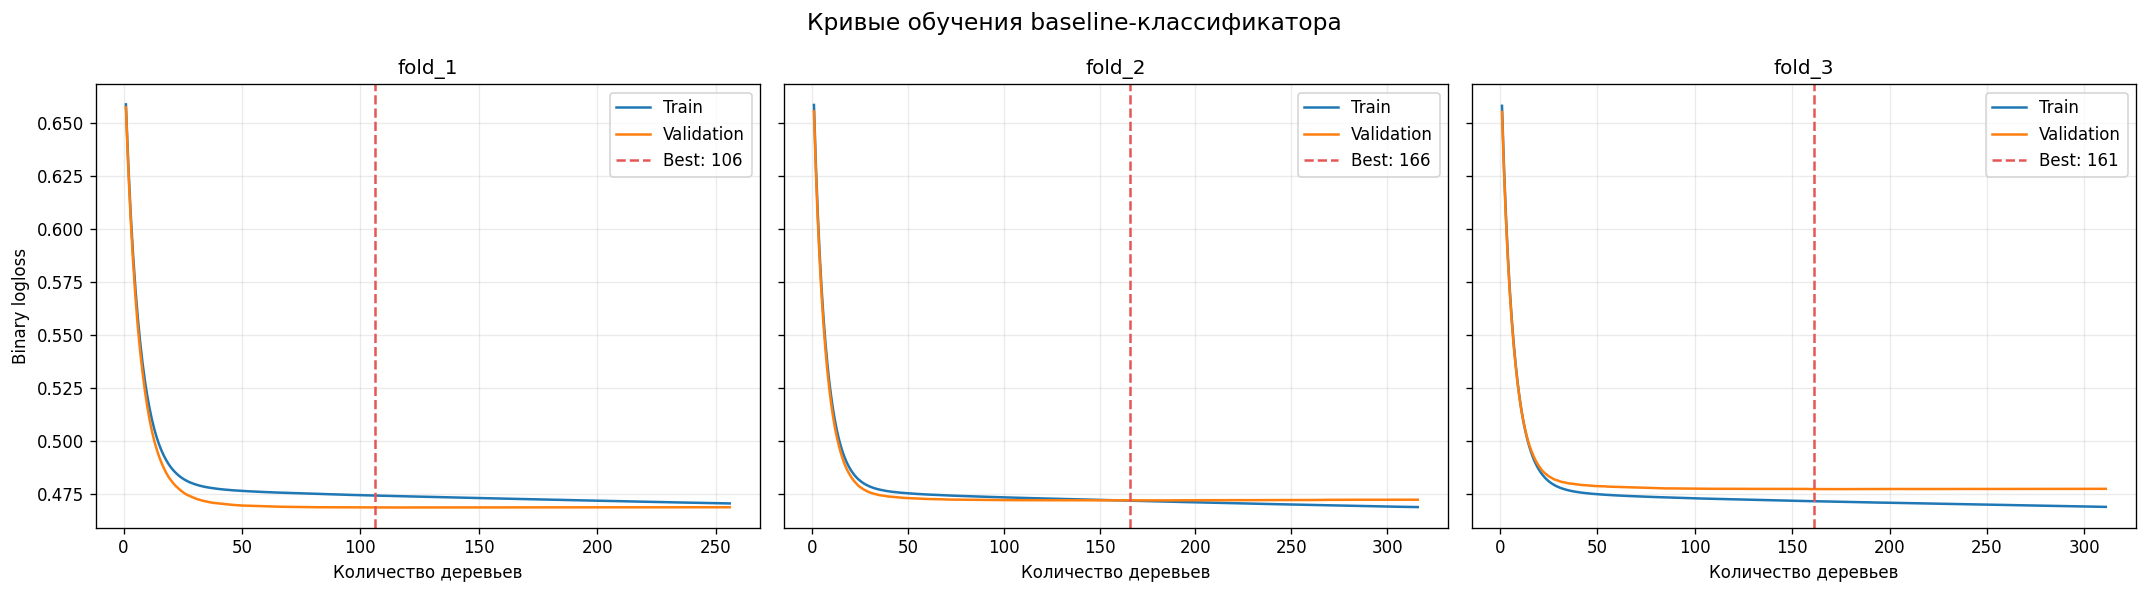

In [19]:
fig, axes = plt.subplots(
    ncols=3,
    figsize=(18, 5),
    sharey=True,
)

for ax, (
    fold_name,
    history,
) in zip(
    axes,
    baseline_classifier_histories.items(),
):
    train_logloss = history[
        "train"
    ]["binary_logloss"]

    valid_logloss = history[
        "validation"
    ]["binary_logloss"]

    iterations = np.arange(
        1,
        len(train_logloss) + 1,
    )

    best_iteration = int(
        baseline_classifier_results.loc[
            fold_name,
            "best_iteration",
        ]
    )

    ax.plot(
        iterations,
        train_logloss,
        label="Train",
    )

    ax.plot(
        iterations,
        valid_logloss,
        label="Validation",
    )

    ax.axvline(
        best_iteration,
        color="#E45756",
        linestyle="--",
        label=(
            f"Best: {best_iteration}"
        ),
    )

    ax.set_title(fold_name)
    ax.set_xlabel("Количество деревьев")
    ax.grid(alpha=0.25)
    ax.legend()


axes[0].set_ylabel(
    "Binary logloss"
)

fig.suptitle(
    "Кривые обучения baseline-классификатора",
    fontsize=14,
)

plt.tight_layout()
plt.show()

Кривые выглядят корректно, но показывают изменение распределения:
- fold_1: validation немного легче объединённого train
- fold_2: кривые практически совпадают
- fold_3: validation устойчиво хуже train - временной drift усиливается
- после лучших итераций validation почти не меняется, тогда как train продолжает улучшаться.

Это умеренное, контролируемое early stopping переобучение.

### OOF-baseline положительного регрессора

Регрессор обучается только на положительных наблюдениях, но формирует OOF-прогноз для всех validation-строк. Эти прогнозы будут зафиксированы во время настройки классификатора.

In [20]:
baseline_oof_predicted_log = np.full(
    len(X),
    np.nan,
    dtype=np.float32,
)

baseline_regressor_records = []
baseline_regressor_histories = {}


for fold_name, split in TUNING_SPLITS.items():
    fold_started = perf_counter()

    train_slice = split["train"]
    valid_slice = split["valid"]

    X_train = X.iloc[train_slice]
    X_valid = X.iloc[valid_slice]

    y_train_class = y_nonzero[train_slice]
    y_valid_class = y_nonzero[valid_slice]

    y_train_gmv = y_gmv[train_slice]
    y_valid_gmv = y_gmv[valid_slice]

    train_positive = y_train_class == 1
    valid_positive = y_valid_class == 1


    X_train_positive = X_train.loc[train_positive]
    X_valid_positive = X_valid.loc[valid_positive]

    y_train_positive_log = np.log1p(y_train_gmv[train_positive])
    y_valid_positive_log = np.log1p(y_valid_gmv[valid_positive])


    regressor = lgb.LGBMRegressor(
        objective="regression_l2",
        metric="None",
        n_estimators=MAX_BOOST_ROUNDS,
        **BASE_LGBM_PARAMS,
    )

    regressor.fit(
        X_train_positive,
        y_train_positive_log,
        eval_set=[
            (X_train_positive, y_train_positive_log),
            (X_valid_positive, y_valid_positive_log),
        ],
        eval_names=["train", "validation"],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=(
                    EARLY_STOPPING_ROUNDS
                ),
                verbose=False,
            )
        ],
    )


    best_iteration = int(
        regressor.best_iteration_
    )

    valid_predicted_log = regressor.predict(
        X_valid,
        num_iteration=best_iteration,
    )

    baseline_oof_predicted_log[valid_slice] = valid_predicted_log.astype(
        np.float32,
        copy=False,
    )


    positive_metrics = (
        positive_regression_metrics(
            y_valid_gmv[valid_positive],
            valid_predicted_log[
                valid_positive
            ],
        )
    )

    pipeline_prediction = (
        combine_two_stage_predictions(
            baseline_oof_probability[
                valid_slice
            ],
            valid_predicted_log,
            scale=1.0,
            gamma=1.0,
        ).prediction
    )

    fold_pipeline_metrics = pipeline_metrics(
        y_valid_gmv,
        pipeline_prediction,
    )


    baseline_regressor_records.append(
        {
            "fold": fold_name,
            "best_iteration": best_iteration,
            "duration_seconds": (
                perf_counter() - fold_started
            ),
            **{
                f"positive_{metric}": value
                for metric, value
                in positive_metrics.items()
            },
            **{
                f"pipeline_{metric}": value
                for metric, value
                in fold_pipeline_metrics.items()
            },
        }
    )

    baseline_regressor_histories[
        fold_name
    ] = regressor.evals_result_


    print(
        f"{fold_name}: "
        f"RMSE(log)="
        f"{positive_metrics['rmse_log']:.6f}, "
        f"pipeline RMSLE="
        f"{fold_pipeline_metrics['rmsle']:.6f}, "
        f"iteration={best_iteration}, "
        f"time={perf_counter() - fold_started:.1f}s"
    )


    del (
        regressor,
        X_train,
        X_valid,
        X_train_positive,
        X_valid_positive,
        y_train_positive_log,
        y_valid_positive_log,
    )
    gc.collect()


baseline_regressor_results = (
    pd.DataFrame(
        baseline_regressor_records
    )
    .set_index("fold")
)

assert np.array_equal(
    np.isfinite(
        baseline_oof_predicted_log
    ),
    np.isfinite(
        baseline_oof_probability
    ),
)

display(baseline_regressor_results)

fold_1: RMSE(log)=1.122053, pipeline RMSLE=1.715699, iteration=325, time=18.8s
fold_2: RMSE(log)=1.111983, pipeline RMSLE=1.733250, iteration=275, time=21.7s
fold_3: RMSE(log)=1.125971, pipeline RMSLE=1.746871, iteration=287, time=26.5s


,best_iteration,duration_seconds,positive_rmse_log,positive_mae_log,positive_log_bias,positive_sum_ratio,positive_negative_log_prediction_share,pipeline_rmsle,pipeline_sum_ratio,pipeline_log_bias
fold,,,,,,,,,,
fold_1,325,18.836078,1.122053,0.891378,0.055089,0.607495,0.0,1.715699,0.457461,0.077081
fold_2,275,21.670123,1.111983,0.883415,-0.016541,0.563437,0.0,1.733250,0.425500,-0.001404
fold_3,287,26.547709,1.125971,0.893471,0.062405,0.620965,0.0,1.746871,0.485386,0.166571


Результаты хорошо разделяют источники ошибки:
- положительный регрессор стабилен между месяцами
- positive_log_bias остаётся относительно небольшим
- pipeline RMSLE ухудшается каждый месяц
- pipeline_log_bias на третьем фолде вырастает до 0.167, хотя bias регрессора всего 0.062.

Следовательно, ухудшение создаётся главным образом вероятностями и их взаимодействием с регрессором. Низкий sum_ratio остаётся общей особенностью обучения в log1p-шкале.

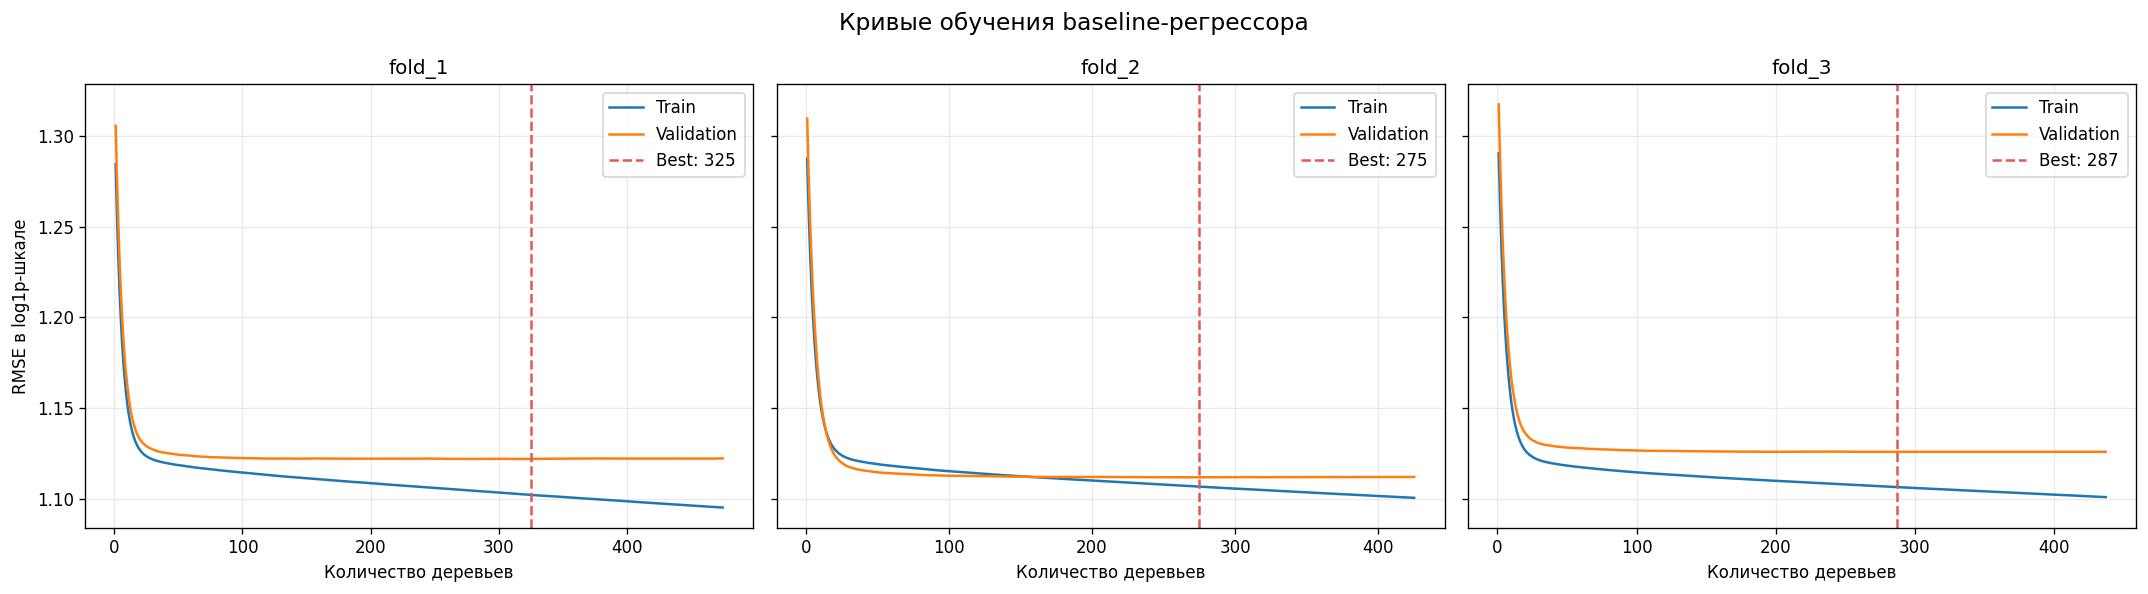

In [21]:
fig, axes = plt.subplots(
    ncols=3,
    figsize=(18, 5),
    sharey=True,
)

for ax, (
    fold_name,
    history,
) in zip(
    axes,
    baseline_regressor_histories.items(),
):
    train_rmse = history[
        "train"
    ]["rmse"]

    valid_rmse = history[
        "validation"
    ]["rmse"]

    iterations = np.arange(
        1,
        len(train_rmse) + 1,
    )

    best_iteration = int(
        baseline_regressor_results.loc[
            fold_name,
            "best_iteration",
        ]
    )

    ax.plot(
        iterations,
        train_rmse,
        label="Train",
    )

    ax.plot(
        iterations,
        valid_rmse,
        label="Validation",
    )

    ax.axvline(
        best_iteration,
        color="#E45756",
        linestyle="--",
        label=f"Best: {best_iteration}",
    )

    ax.set_title(fold_name)
    ax.set_xlabel("Количество деревьев")
    ax.grid(alpha=0.25)
    ax.legend()


axes[0].set_ylabel(
    "RMSE в log1p-шкале"
)

fig.suptitle(
    "Кривые обучения baseline-регрессора",
    fontsize=14,
)

plt.tight_layout()
plt.show()

### Stacking эксперимент

Что ожидаем:
- fold_2 обучается только на validation-строках fold_1
- fold_3 - на validation-строках fold_1 и fold_2
- вероятности везде конечные
- обучающие даты строго предшествуют проверочным.

fold_1 здесь служит начальным обучающим OOF-периодом, поэтому отдельной stacking-оценки для него не будет.

In [22]:
STACKING_FOLD_SPECS = (
    {
        "name": "fold_2",
        "train_folds": ("fold_1",),
        "valid_fold": "fold_2",
    },
    {
        "name": "fold_3",
        "train_folds": ("fold_1", "fold_2"),
        "valid_fold": "fold_3",
    },
)

stacking_splits = {}
stacking_split_records = []


for fold_spec in STACKING_FOLD_SPECS:
    fold_name = fold_spec["name"]

    train_positions = np.concatenate(
        [
            np.arange(
                TUNING_SPLITS[train_fold]["valid"].start,
                TUNING_SPLITS[train_fold]["valid"].stop,
            )
            for train_fold in fold_spec["train_folds"]
        ]
    )

    valid_slice = TUNING_SPLITS[
        fold_spec["valid_fold"]
    ]["valid"]

    valid_positions = np.arange(
        valid_slice.start,
        valid_slice.stop,
    )

    train_probability = baseline_oof_probability[
        train_positions
    ]
    valid_probability = baseline_oof_probability[
        valid_positions
    ]

    # OOF-прогнозы должны существовать для каждой строки.
    assert np.isfinite(train_probability).all()
    assert np.isfinite(valid_probability).all()

    # Обучение должно полностью предшествовать валидации.
    assert train_positions.max() < valid_positions.min()

    # Одна строка не может одновременно участвовать
    # в обучении и валидации.
    assert not np.intersect1d(
        train_positions,
        valid_positions,
    ).size

    stacking_splits[fold_name] = {
        "train": train_positions,
        "valid": valid_positions,
    }

    stacking_split_records.append(
        {
            "fold": fold_name,
            "train_periods": " + ".join(
                fold_spec["train_folds"]
            ),
            "train_rows": len(train_positions),
            "train_positive_rows": int(
                y_nonzero[train_positions].sum()
            ),
            "valid_rows": len(valid_positions),
            "valid_positive_rows": int(
                y_nonzero[valid_positions].sum()
            ),
            "train_probability_mean": float(
                train_probability.mean()
            ),
            "valid_probability_mean": float(
                valid_probability.mean()
            ),
        }
    )


stacking_split_summary = (
    pd.DataFrame(stacking_split_records)
    .set_index("fold")
)

display(stacking_split_summary)

,train_periods,train_rows,train_positive_rows,valid_rows,valid_positive_rows,train_probability_mean,valid_probability_mean
fold,,,,,,,
fold_2,fold_1,240700,131388,244983,139502,0.557684,0.571511
fold_3,fold_1 + fold_2,485683,270890,250000,140770,0.564659,0.596871


Следующая ячейка обучает парные регрессоры:
- control - исходные признаки;
- probability_feature - исходные признаки плюс честная OOF-вероятность.

In [23]:
stacking_oof_predicted_log = {
    "control": np.full(
        len(X),
        np.nan,
        dtype=np.float32,
    ),
    "probability_feature": np.full(
        len(X),
        np.nan,
        dtype=np.float32,
    ),
}

stacking_regressor_records = []
stacking_regressor_histories = {
    "control": {},
    "probability_feature": {},
}


for fold_name, split in stacking_splits.items():
    train_positions = split["train"]
    valid_positions = split["valid"]

    train_probability = baseline_oof_probability[
        train_positions
    ].astype(np.float64)

    valid_probability = baseline_oof_probability[
        valid_positions
    ].astype(np.float64)

    X_train = X.iloc[train_positions]
    X_valid = X.iloc[valid_positions]

    y_train_class = y_nonzero[train_positions]
    y_valid_class = y_nonzero[valid_positions]

    y_train_gmv = y_gmv[train_positions]
    y_valid_gmv = y_gmv[valid_positions]

    train_positive_mask = y_train_class == 1
    valid_positive_mask = y_valid_class == 1

    X_train_positive = X_train.iloc[
        np.flatnonzero(train_positive_mask)
    ]

    X_valid_positive = X_valid.iloc[
        np.flatnonzero(valid_positive_mask)
    ]

    y_train_positive_log = np.log1p(
        y_train_gmv[train_positive_mask]
    )

    y_valid_positive_log = np.log1p(
        y_valid_gmv[valid_positive_mask]
    )

    for variant, use_probability in {
        "control": False,
        "probability_feature": True,
    }.items():
        model_started = perf_counter()

        if use_probability:
            X_train_model = X_train_positive.assign(
                classifier_probability=(
                    train_probability[
                        train_positive_mask
                    ]
                )
            )

            X_valid_positive_model = (
                X_valid_positive.assign(
                    classifier_probability=(
                        valid_probability[
                            valid_positive_mask
                        ]
                    )
                )
            )

            X_valid_model = X_valid.assign(
                classifier_probability=valid_probability
            )
        else:
            X_train_model = X_train_positive
            X_valid_positive_model = X_valid_positive
            X_valid_model = X_valid

        regressor = lgb.LGBMRegressor(
            objective="regression_l2",
            metric="None",
            n_estimators=MAX_BOOST_ROUNDS,
            **BASE_LGBM_PARAMS,
        )

        regressor.fit(
            X_train_model,
            y_train_positive_log,
            eval_set=[
                (
                    X_train_model,
                    y_train_positive_log,
                ),
                (
                    X_valid_positive_model,
                    y_valid_positive_log,
                ),
            ],
            eval_names=["train", "validation"],
            eval_metric="rmse",
            callbacks=[
                lgb.early_stopping(
                    stopping_rounds=(
                        EARLY_STOPPING_ROUNDS
                    ),
                    verbose=False,
                )
            ],
        )

        best_iteration = int(
            regressor.best_iteration_
        )

        valid_predicted_log = regressor.predict(
            X_valid_model,
            num_iteration=best_iteration,
        )

        valid_predicted_log = np.maximum(
            valid_predicted_log,
            0.0,
        )

        stacking_oof_predicted_log[
            variant
        ][valid_positions] = (
            valid_predicted_log.astype(
                np.float32,
                copy=False,
            )
        )

        positive_metrics = (
            positive_regression_metrics(
                y_valid_gmv[valid_positive_mask],
                valid_predicted_log[
                    valid_positive_mask
                ],
            )
        )

        pipeline_prediction = (
            combine_two_stage_predictions(
                valid_probability,
                valid_predicted_log,
                scale=1.0,
                gamma=1.0,
            ).prediction
        )

        combined_metrics = pipeline_metrics(
            y_valid_gmv,
            pipeline_prediction,
        )

        duration = (
            perf_counter() - model_started
        )

        stacking_regressor_records.append(
            {
                "fold": fold_name,
                "variant": variant,
                "best_iteration": best_iteration,
                "duration_seconds": duration,
                **{
                    f"positive_{metric}": value
                    for metric, value
                    in positive_metrics.items()
                },
                **{
                    f"pipeline_{metric}": value
                    for metric, value
                    in combined_metrics.items()
                },
            }
        )

        stacking_regressor_histories[
            variant
        ][fold_name] = regressor.evals_result_

        print(
            f"{fold_name} | {variant}: "
            f"RMSE(log)="
            f"{positive_metrics['rmse_log']:.6f}, "
            f"pipeline RMSLE="
            f"{combined_metrics['rmsle']:.6f}, "
            f"iteration={best_iteration}, "
            f"time={duration:.1f}s"
        )

        del (
            regressor,
            X_train_model,
            X_valid_positive_model,
            X_valid_model,
            valid_predicted_log,
            pipeline_prediction,
        )
        gc.collect()

    del (
        X_train,
        X_valid,
        X_train_positive,
        X_valid_positive,
        y_train_positive_log,
        y_valid_positive_log,
    )
    gc.collect()


stacking_regressor_results = (
    pd.DataFrame(stacking_regressor_records)
    .set_index(["fold", "variant"])
    .sort_index()
)

display(stacking_regressor_results)

fold_2 | control: RMSE(log)=1.115058, pipeline RMSLE=1.734171, iteration=56, time=2.9s
fold_2 | probability_feature: RMSE(log)=1.114716, pipeline RMSLE=1.734105, iteration=71, time=3.2s
fold_3 | control: RMSE(log)=1.126500, pipeline RMSLE=1.746094, iteration=143, time=8.0s
fold_3 | probability_feature: RMSE(log)=1.126312, pipeline RMSLE=1.745973, iteration=112, time=7.7s


best_iteration  duration_seconds  \
fold   variant                                                 
fold_2 control                          56          2.889493   
       probability_feature              71          3.249643   
fold_3 control                         143          7.965085   
       probability_feature             112          7.675257   

                            positive_rmse_log  positive_mae_log  \
fold   variant                                                    
fold_2 control                       1.115058          0.886114   
       probability_feature           1.114716          0.885724   
fold_3 control                       1.126500          0.893177   
       probability_feature           1.126312          0.893298   

                            positive_log_bias  positive_sum_ratio  \
fold   variant                                                      
fold_2 control                      -0.039095            0.546209   
       probability_feature          -0.038136            0.550442   
fold_3 control                       0.044232            0.618622   
       probability_feature           0.041412            0.614764   

                            positive_negative_log_prediction_share  \
fold   variant                                                       
fold_2 control                                                 0.0   
       probability_feature                                     0.0   
fold_3 control                                                 0.0   
       probability_feature                                     0.0   

                            pipeline_rmsle  pipeline_sum_ratio  \
fold   variant                                                   
fold_2 control                    1.734171            0.412638   
       probability_feature        1.734105            0.416851   
fold_3 control                    1.746094            0.485550   
       probability_feature        1.745973            0.482811   

                            pipeline_log_bias  
fold   variant                                 
fold_2 control                      -0.013959  
       probability_feature          -0.013442  
fold_3 control                       0.155221  
       probability_feature           0.153614

Результат однозначный: вероятность как дополнительная колонка работает, но выигрыш практически нулевой.
- fold_2: RMSLE улучшился на 0.000066 — примерно 0.0038%.
- fold_3: RMSLE улучшился на 0.000121 — примерно 0.0069%.
- Среднее улучшение: около 0.000094, или 0.0054%.

Причина ожидаемая: вероятность классификатора полностью вычисляется из тех же 91 признака. Регрессор уже способен извлечь большую часть этого сигнала самостоятельно.

По агрегатам эффект смешанный:
- fold_2: sum_ratio улучшился с 0.4126 до 0.4169;
- fold_3: ухудшился с 0.4856 до 0.4828;
- log_bias немного улучшился на обоих фолдах;
- число итераций меняется заметно, но качество почти не меняется.

In [24]:
stacking_effect_records = []

for fold_name in stacking_splits:
    control = stacking_regressor_results.loc[
        (fold_name, "control")
    ]

    stacked = stacking_regressor_results.loc[
        (fold_name, "probability_feature")
    ]

    stacking_effect_records.append(
        {
            "fold": fold_name,
            "control_rmsle": control[
                "pipeline_rmsle"
            ],
            "stacked_rmsle": stacked[
                "pipeline_rmsle"
            ],
            "rmsle_improvement": (
                control["pipeline_rmsle"]
                - stacked["pipeline_rmsle"]
            ),
            "rmsle_improvement_percent": (
                (
                    control["pipeline_rmsle"]
                    - stacked["pipeline_rmsle"]
                )
                / control["pipeline_rmsle"]
                * 100
            ),
            "positive_rmse_improvement": (
                control["positive_rmse_log"]
                - stacked["positive_rmse_log"]
            ),
            "sum_ratio_gap_improvement": (
                abs(control["pipeline_sum_ratio"] - 1.0)
                - abs(
                    stacked["pipeline_sum_ratio"]
                    - 1.0
                )
            ),
            "absolute_log_bias_improvement": (
                abs(control["pipeline_log_bias"])
                - abs(
                    stacked["pipeline_log_bias"]
                )
            ),
        }
    )


stacking_effect = (
    pd.DataFrame(stacking_effect_records)
    .set_index("fold")
)

stacking_effect.loc["mean"] = (
    stacking_effect.mean()
)

display(stacking_effect)

,control_rmsle,stacked_rmsle,rmsle_improvement,rmsle_improvement_percent,positive_rmse_improvement,sum_ratio_gap_improvement,absolute_log_bias_improvement
fold,,,,,,,
fold_2,1.734171,1.734105,0.000065,0.003759,0.000342,0.004213,0.000517
fold_3,1.746094,1.745973,0.000121,0.006906,0.000188,-0.002739,0.001607
mean,1.740132,1.740039,0.000093,0.005332,0.000265,0.000737,0.001062


Мой вывод: не включать stacking-признак в основной пайплайн. 

Выигрыш слишком мал, чтобы оправдать:
- временную cross-fitting-схему
- сокращение доступной обучающей истории
- различие распределений OOF- и production-вероятностей
- дополнительную связанность классификатора и регрессора.

Основной потенциал улучшения сейчас находится в настройке классификатора, калибровке и выборе функции объединения, а не в передаче вероятности в регрессор.

## 9. Настройка классификатора по pipeline RMSLE

В каждом trial меняются только параметры классификатора. OOF-прогноз положительного регрессора остаётся фиксированным. Early stopping работает по binary logloss, а Optuna минимизирует средний soft-log RMSLE трёх временных фолдов.

In [25]:
CLASSIFIER_STUDY_NAME = (
    "classifier_soft_log_rmsle_v2"
)

CLASSIFIER_REPORT_THRESHOLD = 0.5

baseline_mean_rmsle = float(
    baseline_regressor_results[
        "pipeline_rmsle"
    ].mean()
)


def classifier_objective(trial):
    max_depth = trial.suggest_int(
        "max_depth",
        5,
        10,
    )

    trial_params = {
        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.02,
            0.10,
            log=True,
        ),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int(
            "num_leaves",
            31,
            min(255, 2**max_depth),
        ),
        "min_child_samples": trial.suggest_int(
            "min_child_samples",
            100,
            2_000,
            log=True,
        ),
        "subsample": trial.suggest_float(
            "subsample",
            0.70,
            1.00,
        ),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.65,
            1.00,
        ),
        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-3,
            10.0,
            log=True,
        ),
        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-3,
            10.0,
            log=True,
        ),
    }

    model_params = {
        **BASE_LGBM_PARAMS,
        **trial_params,
    }

    fold_rmsle_values = []
    fold_logloss_values = []
    fold_brier_values = []
    fold_ap_values = []
    fold_f1_values = []
    fold_best_iterations = []

    for fold_number, (
        fold_name,
        split,
    ) in enumerate(TUNING_SPLITS.items()):
        train_slice = split["train"]
        valid_slice = split["valid"]

        X_train = X.iloc[train_slice]
        X_valid = X.iloc[valid_slice]

        y_train_class = y_nonzero[
            train_slice
        ]
        y_valid_class = y_nonzero[
            valid_slice
        ]
        y_valid_gmv = y_gmv[valid_slice]

        fixed_regressor_log = (
            baseline_oof_predicted_log[
                valid_slice
            ].astype(np.float64)
        )

        assert np.isfinite(
            fixed_regressor_log
        ).all()

        classifier = lgb.LGBMClassifier(
            objective="binary",
            metric="None",
            n_estimators=MAX_BOOST_ROUNDS,
            **model_params,
        )

        classifier.fit(
            X_train,
            y_train_class,
            eval_set=[
                (
                    X_valid,
                    y_valid_class,
                )
            ],
            eval_names=["validation"],
            eval_metric="binary_logloss",
            callbacks=[
                lgb.early_stopping(
                    stopping_rounds=(
                        EARLY_STOPPING_ROUNDS
                    ),
                    first_metric_only=True,
                    verbose=False,
                )
            ],
        )

        best_iteration = int(
            classifier.best_iteration_
        )

        valid_probability = (
            classifier.predict_proba(
                X_valid,
                num_iteration=best_iteration,
            )[:, 1]
        )

        pipeline_prediction = (
            combine_two_stage_predictions(
                valid_probability,
                fixed_regressor_log,
                scale=1.0,
                gamma=1.0,
            ).prediction
        )

        combined_metrics = pipeline_metrics(
            y_valid_gmv,
            pipeline_prediction,
        )

        classifier_metrics = (
            classification_metrics(
                y_valid_class,
                valid_probability,
                threshold=(
                    CLASSIFIER_REPORT_THRESHOLD
                ),
            )
        )

        fold_rmsle_values.append(
            float(combined_metrics["rmsle"])
        )
        fold_logloss_values.append(
            float(classifier_metrics["logloss"])
        )
        fold_brier_values.append(
            float(classifier_metrics["brier"])
        )
        fold_ap_values.append(
            float(
                classifier_metrics[
                    "average_precision"
                ]
            )
        )
        fold_f1_values.append(
            float(classifier_metrics["f1"])
        )
        fold_best_iterations.append(
            best_iteration
        )

        partial_mean_rmsle = float(
            np.mean(fold_rmsle_values)
        )

        del (
            classifier,
            X_train,
            X_valid,
            valid_probability,
            pipeline_prediction,
        )
        gc.collect()

        trial.report(
            partial_mean_rmsle,
            step=fold_number,
        )

        if trial.should_prune():
            raise optuna.TrialPruned()

    mean_rmsle = float(
        np.mean(fold_rmsle_values)
    )

    trial.set_user_attr(
        "fold_rmsle",
        fold_rmsle_values,
    )
    trial.set_user_attr(
        "mean_logloss",
        float(np.mean(fold_logloss_values)),
    )
    trial.set_user_attr(
        "mean_brier",
        float(np.mean(fold_brier_values)),
    )
    trial.set_user_attr(
        "mean_average_precision",
        float(np.mean(fold_ap_values)),
    )
    trial.set_user_attr(
        "mean_f1",
        float(np.mean(fold_f1_values)),
    )
    trial.set_user_attr(
        "best_iterations",
        fold_best_iterations,
    )

    return mean_rmsle


print(
    "Classifier objective is ready.\n"
    f"Baseline mean RMSLE: "
    f"{baseline_mean_rmsle:.6f}"
)

Classifier objective is ready.
Baseline mean RMSLE: 1.731940


In [26]:
ARTIFACT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

classifier_storage_path = (
    ARTIFACT_DIR
    / "classifier_optuna.db"
).resolve()

classifier_storage_url = (
    f"sqlite:///"
    f"{classifier_storage_path.as_posix()}"
)


def print_classifier_trial(study, trial):
    if (
        trial.state
        != optuna.trial.TrialState.COMPLETE
    ):
        return

    print(
        f"Trial {trial.number:02d}: "
        f"RMSLE={trial.value:.6f}, "
        f"logloss="
        f"{trial.user_attrs['mean_logloss']:.6f}, "
        f"AP="
        f"{trial.user_attrs['mean_average_precision']:.6f}, "
        f"F1="
        f"{trial.user_attrs['mean_f1']:.6f}"
    )


classifier_sampler = (
    optuna.samplers.TPESampler(
        seed=RANDOM_STATE,
        n_startup_trials=8,
    )
)

classifier_pruner = (
    optuna.pruners.MedianPruner(
        n_startup_trials=8,
        n_warmup_steps=1,
    )
)

classifier_study = optuna.create_study(
    study_name=CLASSIFIER_STUDY_NAME,
    storage=classifier_storage_url,
    load_if_exists=True,
    direction="minimize",
    sampler=classifier_sampler,
    pruner=classifier_pruner,
)


finished_states = {
    optuna.trial.TrialState.COMPLETE,
    optuna.trial.TrialState.PRUNED,
}

finished_trial_count = sum(
    trial.state in finished_states
    for trial in classifier_study.trials
)

remaining_trial_count = max(
    0,
    N_TRIALS_CLASSIFIER
    - finished_trial_count,
)

print(f"Study: {CLASSIFIER_STUDY_NAME}")
print(
    f"Storage: {classifier_storage_path}"
)
print(
    f"Finished trials: "
    f"{finished_trial_count}"
)
print(
    f"Remaining trials: "
    f"{remaining_trial_count}"
)
print(
    f"Baseline mean RMSLE: "
    f"{baseline_mean_rmsle:.6f}"
)


classifier_tuning_started = perf_counter()

if remaining_trial_count > 0:
    classifier_study.optimize(
        classifier_objective,
        n_trials=remaining_trial_count,
        n_jobs=OPTUNA_N_JOBS,
        gc_after_trial=True,
        callbacks=[print_classifier_trial],
    )

classifier_tuning_duration = (
    perf_counter()
    - classifier_tuning_started
)


classifier_best_trial = (
    classifier_study.best_trial
)

classifier_best_params = {
    **BASE_LGBM_PARAMS,
    **classifier_best_trial.params,
    "subsample_freq": 1,
}


complete_trials = [
    trial
    for trial in classifier_study.trials
    if (
        trial.state
        == optuna.trial.TrialState.COMPLETE
    )
]

classifier_trial_summary = pd.DataFrame(
    [
        {
            "trial": trial.number,
            "rmsle": trial.value,
            "mean_logloss": trial.user_attrs[
                "mean_logloss"
            ],
            "mean_brier": trial.user_attrs[
                "mean_brier"
            ],
            "mean_average_precision": (
                trial.user_attrs[
                    "mean_average_precision"
                ]
            ),
            "mean_f1": trial.user_attrs[
                "mean_f1"
            ],
            "fold_rmsle": trial.user_attrs[
                "fold_rmsle"
            ],
            "best_iterations": trial.user_attrs[
                "best_iterations"
            ],
        }
        for trial in complete_trials
    ]
).sort_values("rmsle")


print()
print(
    f"Tuning time: "
    f"{classifier_tuning_duration / 60:.1f} min"
)
print(
    f"Best trial: "
    f"{classifier_best_trial.number}"
)
print(
    f"Best mean RMSLE: "
    f"{classifier_best_trial.value:.6f}"
)
print(
    f"Absolute improvement: "
    f"{baseline_mean_rmsle - classifier_best_trial.value:.6f}"
)
print(
    f"Relative improvement: "
    f"{(
        baseline_mean_rmsle
        - classifier_best_trial.value
    ) / baseline_mean_rmsle * 100:.4f}%"
)

print()
print("Best classifier parameters:")

display(
    pd.Series(
        classifier_best_trial.params,
        name="value",
    ).to_frame()
)

display(
    classifier_trial_summary.head(10)
)

[I 2026-08-21 03:22:25,101] A new study created in RDB with name: classifier_soft_log_rmsle_v2


Study: classifier_soft_log_rmsle_v2
Storage: C:\Users\savin\OneDrive\Документы\Мои документы\Проекты\E-Cup 2026\E-CUP-2026\data\two_stage_artifacts\classifier_optuna.db
Finished trials: 0
Remaining trials: 40
Baseline mean RMSLE: 1.731940


[I 2026-08-21 03:24:39,347] Trial 0 finished with value: 1.731204736694522 and parameters: {'max_depth': 7, 'learning_rate': 0.09237421878009823, 'num_leaves': 102, 'min_child_samples': 600, 'subsample': 0.7468055921327309, 'colsample_bytree': 0.7045980821176709, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 1.731204736694522.


Trial 00: RMSLE=1.731205, logloss=0.471946, AP=0.885532, F1=0.799465


[I 2026-08-21 03:28:00,401] Trial 1 finished with value: 1.7311488631116678 and parameters: {'max_depth': 8, 'learning_rate': 0.06251028636335225, 'num_leaves': 35, 'min_child_samples': 1828, 'subsample': 0.9497327922401265, 'colsample_bytree': 0.7243186887373967, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 1 with value: 1.7311488631116678.


...

Trial 38: RMSLE=1.730701, logloss=0.471623, AP=0.885726, F1=0.799833


[I 2026-08-21 07:18:32,662] Trial 39 finished with value: 1.7306373933383694 and parameters: {'max_depth': 10, 'learning_rate': 0.02003696739003453, 'num_leaves': 209, 'min_child_samples': 153, 'subsample': 0.7728250160043499, 'colsample_bytree': 0.848447353799867, 'reg_alpha': 0.09246688159115868, 'reg_lambda': 0.07232718269239151}. Best is trial 11 with value: 1.730421874994244.


Trial 39: RMSLE=1.730637, logloss=0.471627, AP=0.885639, F1=0.799607

Tuning time: 236.1 min
Best trial: 11
Best mean RMSLE: 1.730422
Absolute improvement: 0.001518
Relative improvement: 0.0877%

Best classifier parameters:


,value
max_depth,10.000000
learning_rate,0.021111
num_leaves,209.000000
min_child_samples,102.000000
subsample,0.723347
colsample_bytree,0.809790
reg_alpha,9.941451
reg_lambda,0.687875


,trial,rmsle,mean_logloss,mean_brier,mean_average_precision,mean_f1,fold_rmsle,best_iterations
11,11,1.730422,0.471466,0.155254,0.885717,0.799699,"[1.7149677681746403, 1.7319674499794593, 1.744...","[453, 618, 722]"
10,10,1.730436,0.471478,0.155262,0.885709,0.799683,"[1.7149482287062936, 1.731982186414726, 1.7443...","[573, 603, 748]"
33,33,1.730507,0.471551,0.155277,0.885697,0.799687,"[1.7147984530089768, 1.7320599288890304, 1.744...","[403, 488, 538]"
22,22,1.730519,0.471536,0.155277,0.885704,0.799774,"[1.7148666765299145, 1.7319200686053877, 1.744...","[393, 603, 662]"
30,30,1.730524,0.471571,0.155271,0.885646,0.799763,"[1.7149255714681808, 1.732060356019471, 1.7445...","[246, 295, 316]"
23,23,1.730526,0.471520,0.155270,0.885685,0.799735,"[1.7149717092912093, 1.7321862481345611, 1.744...","[340, 485, 521]"
12,12,1.730530,0.471509,0.155265,0.885711,0.799662,"[1.7148962489994306, 1.732039394216794, 1.7446...","[568, 713, 818]"
25,25,1.730538,0.471564,0.155281,0.885685,0.799716,"[1.7148535014495039, 1.7320242224593674, 1.744...","[393, 490, 534]"
32,32,1.730552,0.471575,0.155277,0.885650,0.799770,"[1.7151068645700756, 1.7320025195406306, 1.744...","[375, 362, 373]"
15,15,1.730569,0.471583,0.155282,0.885634,0.799693,"[1.7150085027971562, 1.7321491350192633, 1.744...","[403, 417, 768]"


Результат хороший, хотя улучшение умеренное:
- RMSLE: 1.731940 -> 1.730422
- абсолютный выигрыш: 0.001518
- относительный: 0.0877%
- это примерно в 16 раз больше эффекта stacking
- все 40 trials завершились
- несколько лучших trials близки друг к другу, поэтому результат не похож на случайный одиночный выброс.

In [27]:
tuned_classifier_oof_probability = np.full(
    len(X),
    np.nan,
    dtype=np.float32
)

tuned_classifier_records = []
tuned_classifier_histories = {}
tuned_classifier_best_iterations = []

for fold_name, split in TUNING_SPLITS.items():
    fold_started = perf_counter()
    
    train_slice = split["train"]
    valid_slice = split["valid"]
    
    X_train = X.iloc[train_slice]
    X_valid = X.iloc[valid_slice]
    
    y_train_class = y_nonzero[train_slice]
    y_valid_class = y_nonzero[valid_slice]
    y_valid_gmv = y_gmv[valid_slice]
    
    fixed_regressor_log = (
        baseline_oof_predicted_log[valid_slice]
        .astype(np.float64)
    )
    
    classifier_history = {}
    
    classifier = lgb.LGBMClassifier(
        objective="binary",
        metric="None",
        n_estimators=MAX_BOOST_ROUNDS,
        **classifier_best_params,
    )
    
    classifier.fit(
        X_train,
        y_train_class,
        eval_set=[
            (X_train, y_train_class),
            (X_valid, y_valid_class),
            ],
        eval_names=["train", "validation"],
        eval_metric="binary_logloss",
        callbacks=[
            lgb.early_stopping(
                stopping_rounds=EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False,
            ),
            lgb.record_evaluation(classifier_history)
        ],
    )
    
    best_iteration = int(classifier.best_iteration_)
    
    valid_probability = (
        classifier.predict_proba(
            X_valid,
            num_iteration=best_iteration
        )[:, 1]
    )
    
    tuned_classifier_oof_probability[valid_slice] = valid_probability.astype(
        np.float32,
        copy=False
    )
    
    classifier_result = (
        classification_metrics(
            y_valid_class,
            valid_probability,
            threshold=(
                CLASSIFIER_REPORT_THRESHOLD
            ),
        )
    )

    pipeline_prediction = (
        combine_two_stage_predictions(
            valid_probability,
            fixed_regressor_log,
            scale=1.0,
            gamma=1.0,
        ).prediction
    )

    pipeline_result = pipeline_metrics(
        y_valid_gmv,
        pipeline_prediction,
    )

    tuned_classifier_records.append(
        {
            "fold": fold_name,
            "best_iteration": best_iteration,
            "duration_seconds": (
                perf_counter()
                - fold_started
            ),
            **{
                metric: value
                for metric, value
                in classifier_result.items()
            },
            **{
                f"pipeline_{metric}": value
                for metric, value
                in pipeline_result.items()
            },
        }
    )

    tuned_classifier_histories[
        fold_name
    ] = classifier_history

    tuned_classifier_best_iterations.append(
        best_iteration
    )

    print(
        f"{fold_name}: "
        f"logloss="
        f"{classifier_result['logloss']:.6f}, "
        f"AP="
        f"{classifier_result['average_precision']:.6f}, "
        f"F1="
        f"{classifier_result['f1']:.6f}, "
        f"pipeline RMSLE="
        f"{pipeline_result['rmsle']:.6f}, "
        f"iteration={best_iteration}, "
        f"time="
        f"{perf_counter() - fold_started:.1f}s"
    )

    del (
        classifier,
        X_train,
        X_valid,
        valid_probability,
        pipeline_prediction,
    )
    gc.collect()


tuned_classifier_results = (
    pd.DataFrame(
        tuned_classifier_records
    )
    .set_index("fold")
)


tuned_classifier_oof_mask = (
    np.isfinite(
        tuned_classifier_oof_probability
    )
)

baseline_classifier_oof_mask = (
    np.isfinite(
        baseline_oof_probability
    )
)

assert np.array_equal(
    tuned_classifier_oof_mask,
    baseline_classifier_oof_mask,
)

reproduced_mean_rmsle = float(
    tuned_classifier_results[
        "pipeline_rmsle"
    ].mean()
)

np.testing.assert_allclose(
    reproduced_mean_rmsle,
    classifier_best_trial.value,
    atol=1e-8,
    rtol=0.0,
)

assert (
    tuned_classifier_best_iterations
    == classifier_best_trial.user_attrs[
        "best_iterations"
    ]
)


print()
print(
    "OOF reproduction: PASS"
)
print(
    f"Reproduced mean RMSLE: "
    f"{reproduced_mean_rmsle:.6f}"
)

display(tuned_classifier_results)

fold_1: logloss=0.467839, AP=0.882878, F1=0.795755, pipeline RMSLE=1.714968, iteration=453, time=138.4s
fold_2: logloss=0.470944, AP=0.889064, F1=0.802018, pipeline RMSLE=1.731967, iteration=618, time=189.7s
fold_3: logloss=0.475615, AP=0.885210, F1=0.801325, pipeline RMSLE=1.744330, iteration=722, time=231.5s

OOF reproduction: PASS
Reproduced mean RMSLE: 1.730422


,best_iteration,duration_seconds,average_precision,logloss,brier,precision,recall,f1,pipeline_rmsle,pipeline_sum_ratio,pipeline_log_bias
fold,,,,,,,,,,,
fold_1,453,138.363303,0.882878,0.467839,0.153687,0.788145,0.803513,0.795755,1.714968,0.458092,0.076502
fold_2,618,189.671906,0.889064,0.470944,0.155162,0.795767,0.808368,0.802018,1.731967,0.425406,-0.001278
fold_3,722,231.457831,0.885210,0.475615,0.156913,0.774597,0.829964,0.801325,1.744330,0.486122,0.154788


Настроенный классификатор воспроизвёл Optuna objective и улучшил pipeline на каждом фолде:
- fold_1: 1.715699 -> 1.714968, выигрыш 0.000731
- fold_2: 1.733250 -> 1.731967, выигрыш 0.001283
- fold_3: 1.746871 -> 1.744330, выигрыш 0.002541.

Особенно важно улучшение на fold_3, где дрейф был сильнее. Logloss, Brier и AP тоже улучшились. F1 на fold_3 слегка снизился, но это допустимо: мы оптимизировали вероятности для итогового GMV, а не бинарный порог 0.5.

In [28]:
comparison_columns = [
    "average_precision",
    "logloss",
    "brier",
    "precision",
    "recall",
    "f1",
    "pipeline_rmsle",
    "pipeline_sum_ratio",
    "pipeline_log_bias",
]


baseline_classifier_comparison = (
    baseline_classifier_results[
        [
            "average_precision",
            "logloss",
            "brier",
            "precision",
            "recall",
            "f1",
        ]
    ]
    .join(
        baseline_regressor_results[
            [
                "pipeline_rmsle",
                "pipeline_sum_ratio",
                "pipeline_log_bias",
            ]
        ]
    )
)


classifier_fold_comparison = pd.concat(
    {
        "baseline": (
            baseline_classifier_comparison[
                comparison_columns
            ]
        ),
        "tuned": (
            tuned_classifier_results[
                comparison_columns
            ]
        ),
    },
    names=["model", "fold"],
)


classifier_improvement = pd.DataFrame(
    {
        "average_precision": (
            tuned_classifier_results[
                "average_precision"
            ]
            - baseline_classifier_comparison[
                "average_precision"
            ]
        ),
        "logloss": (
            baseline_classifier_comparison[
                "logloss"
            ]
            - tuned_classifier_results[
                "logloss"
            ]
        ),
        "brier": (
            baseline_classifier_comparison[
                "brier"
            ]
            - tuned_classifier_results[
                "brier"
            ]
        ),
        "f1": (
            tuned_classifier_results["f1"]
            - baseline_classifier_comparison[
                "f1"
            ]
        ),
        "pipeline_rmsle": (
            baseline_classifier_comparison[
                "pipeline_rmsle"
            ]
            - tuned_classifier_results[
                "pipeline_rmsle"
            ]
        ),
        "sum_ratio_gap": (
            abs(
                baseline_classifier_comparison[
                    "pipeline_sum_ratio"
                ]
                - 1.0
            )
            - abs(
                tuned_classifier_results[
                    "pipeline_sum_ratio"
                ]
                - 1.0
            )
        ),
        "absolute_log_bias": (
            abs(
                baseline_classifier_comparison[
                    "pipeline_log_bias"
                ]
            )
            - abs(
                tuned_classifier_results[
                    "pipeline_log_bias"
                ]
            )
        ),
    }
)

classifier_improvement.loc["mean"] = (
    classifier_improvement.mean()
)


print(
    "В таблице improvement "
    "положительное значение означает улучшение."
)

display(classifier_fold_comparison)
display(classifier_improvement)

В таблице improvement положительное значение означает улучшение.


average_precision   logloss     brier  precision    recall  \
model    fold                                                                 
baseline fold_1           0.882563  0.468394  0.153840   0.786208  0.805446   
         fold_2           0.888646  0.471731  0.155393   0.795816  0.807243   
         fold_3           0.884723  0.477083  0.157468   0.770925  0.835071   
tuned    fold_1           0.882878  0.467839  0.153687   0.788145  0.803513   
         fold_2           0.889064  0.470944  0.155162   0.795767  0.808368   
         fold_3           0.885210  0.475615  0.156913   0.774597  0.829964   

                       f1  pipeline_rmsle  pipeline_sum_ratio  \
model    fold                                                   
baseline fold_1  0.795711        1.715699            0.457461   
         fold_2  0.801489        1.733250            0.425500   
         fold_3  0.801717        1.746871            0.485386   
tuned    fold_1  0.795755        1.714968            0.458092   
         fold_2  0.802018        1.731967            0.425406   
         fold_3  0.801325        1.744330            0.486122   

                 pipeline_log_bias  
model    fold                       
baseline fold_1           0.077081  
         fold_2          -0.001404  
         fold_3           0.166571  
tuned    fold_1           0.076502  
         fold_2          -0.001278  
         fold_3           0.154788

,average_precision,logloss,brier,f1,pipeline_rmsle,sum_ratio_gap,absolute_log_bias
fold,,,,,,,
fold_1,0.000315,0.000555,0.000152,0.000044,0.000731,0.000632,0.000578
fold_2,0.000419,0.000787,0.000231,0.000529,0.001282,-0.000094,0.000126
fold_3,0.000488,0.001469,0.000554,-0.000392,0.002541,0.000736,0.011783
mean,0.000407,0.000937,0.000313,0.000060,0.001518,0.000425,0.004162


### Диагностика настроенного классификатора

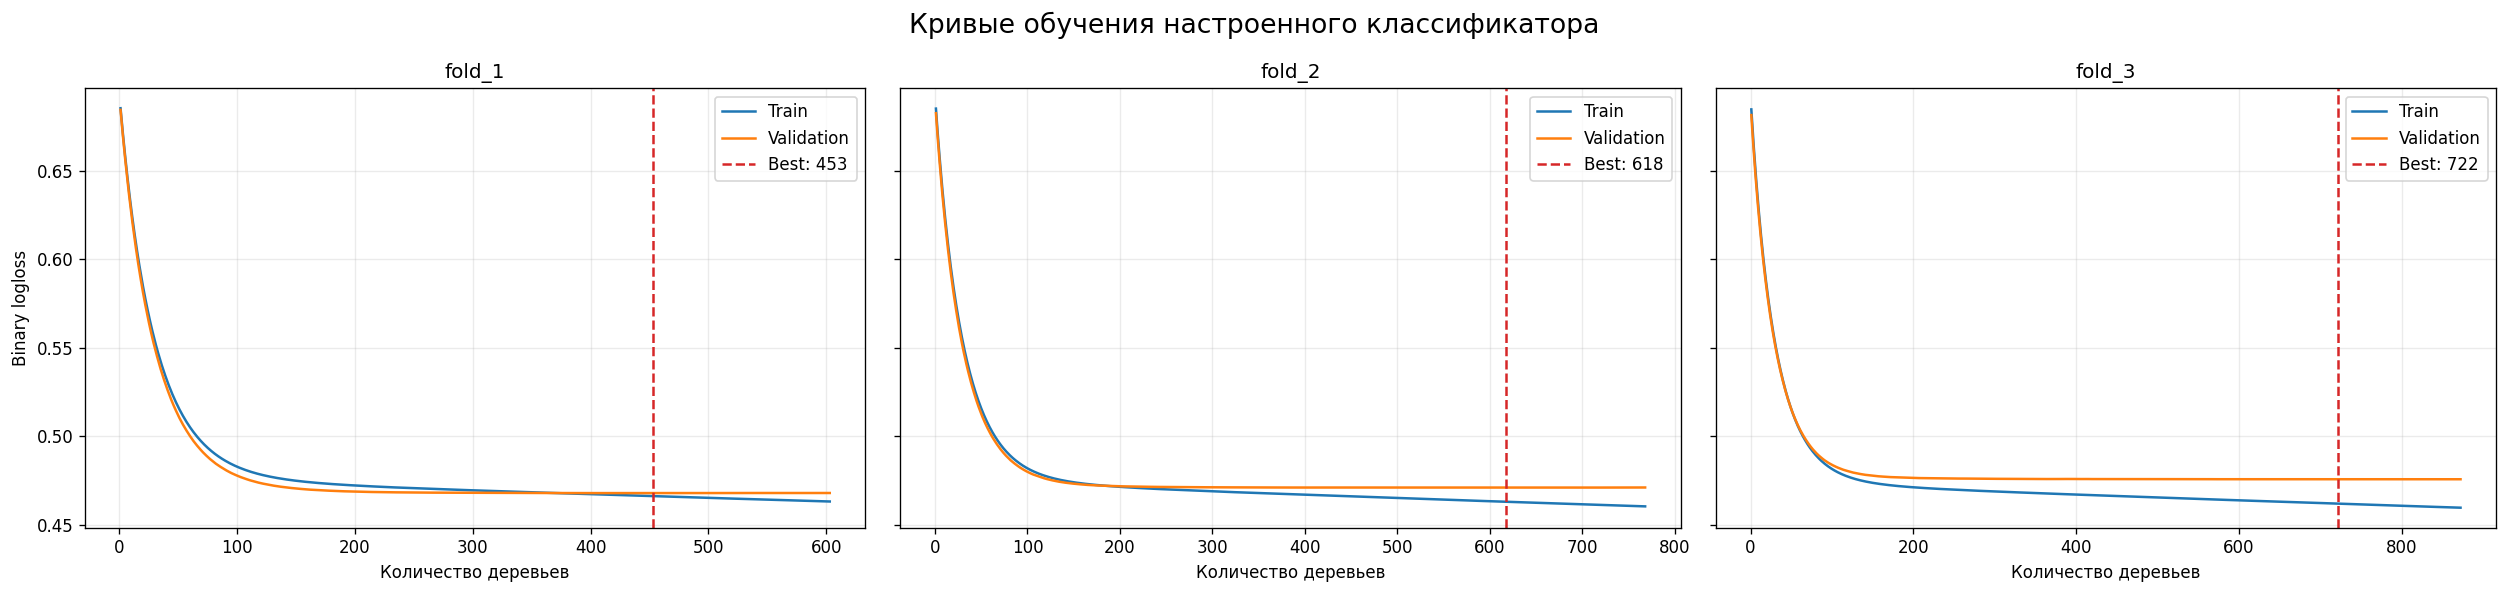

In [29]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(TUNING_SPLITS),
    figsize=(21, 5),
    sharey=True,
)

for axis, fold_name in zip(
    axes,
    TUNING_SPLITS,
):
    history = tuned_classifier_histories[
        fold_name
    ]

    train_logloss = np.asarray(
        history["train"]["binary_logloss"]
    )
    valid_logloss = np.asarray(
        history["validation"][
            "binary_logloss"
        ]
    )

    iterations = np.arange(
        1,
        len(train_logloss) + 1,
    )

    best_iteration = int(
        tuned_classifier_results.loc[
            fold_name,
            "best_iteration",
        ]
    )

    axis.plot(
        iterations,
        train_logloss,
        label="Train",
    )
    axis.plot(
        iterations,
        valid_logloss,
        label="Validation",
    )
    axis.axvline(
        best_iteration,
        color="tab:red",
        linestyle="--",
        label=f"Best: {best_iteration}",
    )

    axis.set_title(fold_name)
    axis.set_xlabel("Количество деревьев")
    axis.grid(alpha=0.25)
    axis.legend()

axes[0].set_ylabel("Binary logloss")

fig.suptitle(
    "Кривые обучения настроенного классификатора",
    fontsize=16,
)

plt.tight_layout()
plt.show()

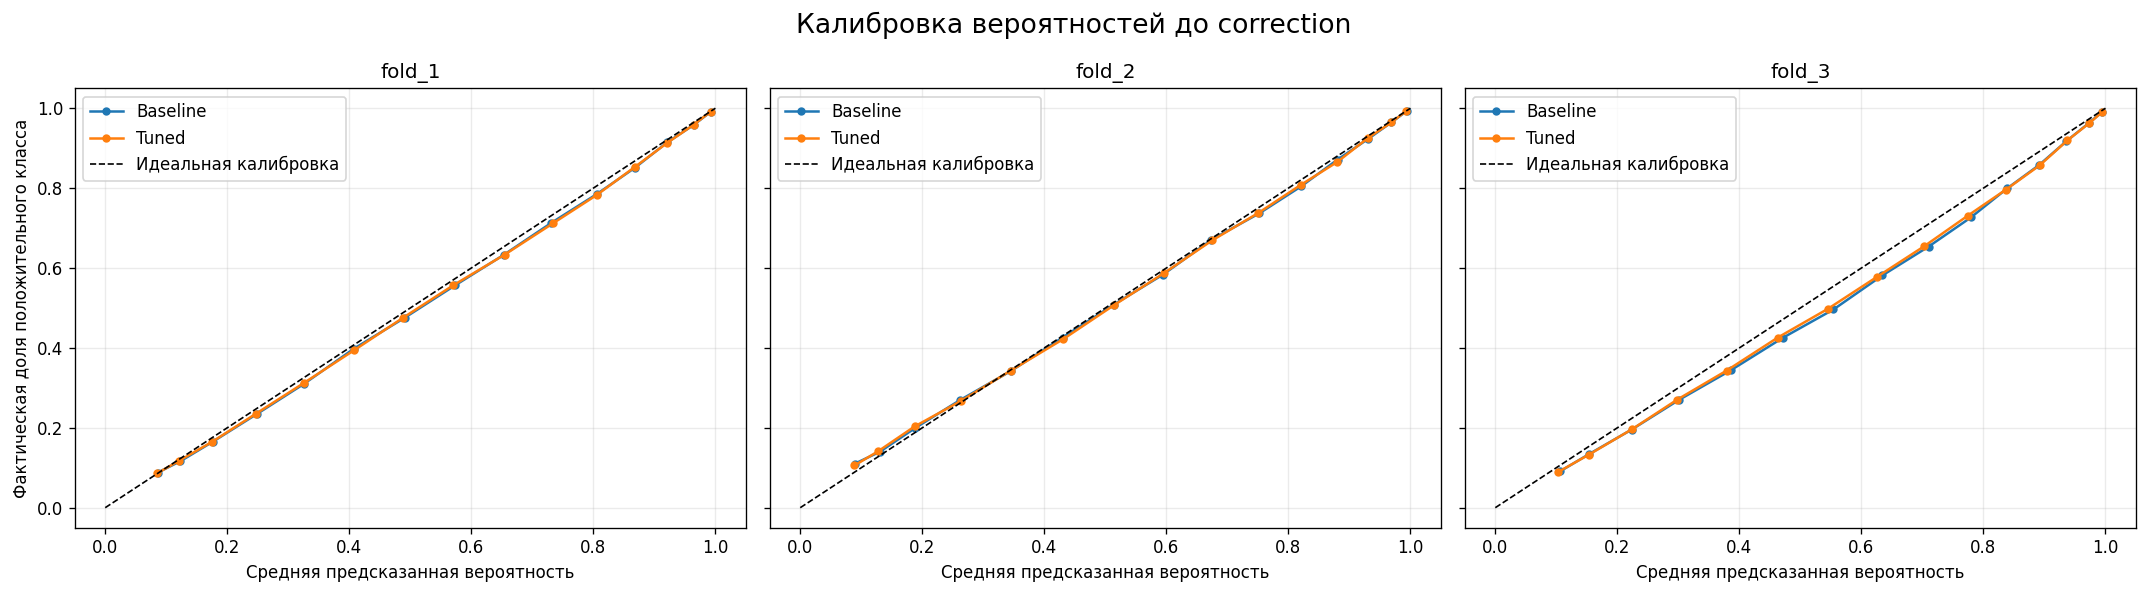

In [30]:
from sklearn.calibration import calibration_curve


fig, axes = plt.subplots(
    nrows=1,
    ncols=len(TUNING_SPLITS),
    figsize=(18, 5),
    sharex=True,
    sharey=True,
)

for axis, (
    fold_name,
    split,
) in zip(
    axes,
    TUNING_SPLITS.items(),
):
    valid_slice = split["valid"]
    actual_class = y_nonzero[valid_slice]

    probability_variants = {
        "Baseline": (
            baseline_oof_probability[
                valid_slice
            ]
        ),
        "Tuned": (
            tuned_classifier_oof_probability[
                valid_slice
            ]
        ),
    }

    for model_name, probability in (
        probability_variants.items()
    ):
        observed_share, predicted_mean = (
            calibration_curve(
                actual_class,
                probability,
                n_bins=15,
                strategy="quantile",
            )
        )

        axis.plot(
            predicted_mean,
            observed_share,
            marker="o",
            markersize=4,
            label=model_name,
        )

    axis.plot(
        [0, 1],
        [0, 1],
        color="black",
        linestyle="--",
        linewidth=1,
        label="Идеальная калибровка",
    )

    axis.set_title(fold_name)
    axis.set_xlabel(
        "Средняя предсказанная вероятность"
    )
    axis.grid(alpha=0.25)
    axis.legend()

axes[0].set_ylabel(
    "Фактическая доля положительного класса"
)

fig.suptitle(
    "Калибровка вероятностей до correction",
    fontsize=16,
)

plt.tight_layout()
plt.show()

Кривые обучения выглядят нормально:
- validation logloss выходит на плато
- после optimum train продолжает улучшаться, а validation почти не меняется
- early stopping корректно ограничивает переобучение
- увеличивающийся разрыв на fold_3 снова показывает временной дрейф.

Reliability diagram показывает:
- fold_2 откалиброван достаточно хорошо
- на fold_1 и особенно fold_3 фактическая доля покупателей преимущественно ниже предсказанной
- значит, классификатор систематически завышает вероятность
- baseline и tuned почти совпадают: настройка улучшила ранжирование и logloss, но не устранила временную ошибку калибровки.

## 10. Walk-forward-калибровка вероятностей

Калибратор обучается только на предшествующих OOF-периодах. Fold 1 используется для калибровки fold 2, а fold 1 и fold 2 — для калибровки fold 3. Holdout не используется.

In [32]:
from sklearn.isotonic import (IsotonicRegression)
from sklearn.linear_model import (LogisticRegression)


def to_logit(probability):
    clipped_probability = np.clip(
        np.asarray(
            probability,
            dtype=np.float64,
        ),
        1e-6,
        1.0 - 1e-6,
    )

    return np.log(clipped_probability / (1.0 - clipped_probability)).reshape(-1, 1)


CALIBRATION_FOLD_SPECS = (
    {
        "fold": "fold_2",
        "calibration_folds": [
            "fold_1",
        ],
    },
    {
        "fold": "fold_3",
        "calibration_folds": [
            "fold_1",
            "fold_2",
        ],
    },
)

for fold_spec in CALIBRATION_FOLD_SPECS:
    assert all(
        calibration_fold in TUNING_SPLITS
        for calibration_fold
        in fold_spec["calibration_folds"]
    )

print("Calibration fold specification: PASS")

walk_forward_probability = {
    method: np.full(
        len(X),
        np.nan,
        dtype=np.float32,
    )
    for method in ("raw", "sigmoid", "isotonic")
}

walk_forward_calibrators = {
    "sigmoid": {},
    "isotonic": {},
}

calibration_records = []


for fold_spec in CALIBRATION_FOLD_SPECS:
    fold_name = fold_spec["fold"]

    calibration_positions = np.concatenate(
        [
            np.arange(
                TUNING_SPLITS[calibration_fold]["valid"].start,
                TUNING_SPLITS[calibration_fold]["valid"].stop,
            )
            for calibration_fold in fold_spec["calibration_folds"]
        ]
    )

    valid_slice = TUNING_SPLITS[fold_name]["valid"]

    valid_positions = np.arange(valid_slice.start, valid_slice.stop)

    assert (calibration_positions.max() < valid_positions.min())

    calibration_probability = (
        tuned_classifier_oof_probability[calibration_positions].astype(np.float64)
    )

    calibration_target = y_nonzero[calibration_positions]

    valid_raw_probability = (
        tuned_classifier_oof_probability[valid_positions].astype(np.float64)
    )

    valid_target = y_nonzero[valid_positions]
    valid_gmv = y_gmv[valid_positions]

    fixed_regressor_log = (
        baseline_oof_predicted_log[
            valid_positions
        ].astype(np.float64)
    )

    assert np.isfinite(calibration_probability).all()
    assert np.isfinite(valid_raw_probability).all()
    assert np.isfinite(fixed_regressor_log).all()

    sigmoid_calibrator = (
        LogisticRegression(
            C=1e6,
            solver="lbfgs",
            max_iter=1_000,
        )
    )

    sigmoid_calibrator.fit(
        to_logit(calibration_probability),
        calibration_target,
    )

    valid_sigmoid_probability = (
        sigmoid_calibrator.predict_proba(
            to_logit(valid_raw_probability)
        )[:, 1]
    )

    isotonic_calibrator = (
        IsotonicRegression(
            y_min=0.0,
            y_max=1.0,
            out_of_bounds="clip",
        )
    )

    isotonic_calibrator.fit(calibration_probability, calibration_target)

    valid_isotonic_probability = (
        isotonic_calibrator.predict(valid_raw_probability)
    )

    probability_variants = {
        "raw": valid_raw_probability,
        "sigmoid": (valid_sigmoid_probability),
        "isotonic": (valid_isotonic_probability),
    }

    walk_forward_calibrators["sigmoid"][fold_name] = sigmoid_calibrator

    walk_forward_calibrators["isotonic"][fold_name] = isotonic_calibrator

    for method, probability in probability_variants.items():
        probability = np.clip(
            probability,
            0.0,
            1.0,
        )

        walk_forward_probability[method][valid_positions] = (
            probability.astype(
                np.float32,
                copy=False,
            )
        )

        classifier_result = (
            classification_metrics(
                valid_target,
                probability,
                threshold=0.5,
            )
        )

        pipeline_prediction = (
            combine_two_stage_predictions(
                probability,
                fixed_regressor_log,
                scale=1.0,
                gamma=1.0,
            ).prediction
        )

        pipeline_result = (
            pipeline_metrics(
                valid_gmv,
                pipeline_prediction,
            )
        )

        calibration_records.append(
            {
                "fold": fold_name,
                "method": method,
                "calibration_rows": len(calibration_positions),
                "average_precision": (classifier_result["average_precision"]),
                "logloss": (classifier_result["logloss"]),
                "brier": (classifier_result["brier"]),
                "precision": (classifier_result["precision"]),
                "recall": (classifier_result["recall"]),
                "f1": classifier_result["f1"],
                "pipeline_rmsle": (pipeline_result["rmsle"]),
                "pipeline_sum_ratio": (pipeline_result["sum_ratio"]),
                "pipeline_log_bias": (pipeline_result["log_bias"]),
            }
        )


walk_forward_calibration_results = (
    pd.DataFrame(calibration_records)
    .set_index(["fold", "method"])
    .sort_index()
)

display(
    walk_forward_calibration_results
)

Calibration fold specification: PASS


calibration_rows  average_precision   logloss     brier  \
fold   method                                                              
fold_2 isotonic            240700           0.886617  0.471217  0.155252   
       raw                 240700           0.889064  0.470944  0.155162   
       sigmoid             240700           0.889064  0.471013  0.155195   
fold_3 isotonic            485683           0.883182  0.475327  0.156447   
       raw                 485683           0.885210  0.475615  0.156913   
       sigmoid             485683           0.885210  0.474114  0.156424   

                 precision    recall        f1  pipeline_rmsle  \
fold   method                                                    
fold_2 isotonic   0.804415  0.793372  0.798855        1.732588   
       raw        0.795767  0.808368  0.802018        1.731967   
       sigmoid    0.803247  0.795243  0.799225        1.732337   
fold_3 isotonic   0.778670  0.823691  0.800548        1.741595   
       raw        0.774597  0.829964  0.801325        1.744330   
       sigmoid    0.779224  0.822732  0.800387        1.741452   

                 pipeline_sum_ratio  pipeline_log_bias  
fold   method                                           
fold_2 isotonic            0.416292          -0.047059  
       raw                 0.425406          -0.001278  
       sigmoid             0.414496          -0.046545  
fold_3 isotonic            0.477861           0.124601  
       raw                 0.486122           0.154788  
       sigmoid             0.474679           0.125282

Калибровка даёт смешанный, но полезный результат:
- На fold_2 raw лучше: sigmoid ухудшает RMSLE на 0.000370
- На fold_3 sigmoid улучшает RMSLE на 0.002878
- Среднее по fold_2 + fold_3:
  - raw: 1.738149
  - sigmoid: 1.736895
  - isotonic: 1.737092.
  
Sigmoid пока лидирует: он устойчивее isotonic, сохраняет AP и даёт лучший средний RMSLE. Однако калибровка дополнительно уменьшает sum_ratio, поэтому окончательный выбор cделаем только вместе со способом объединения.

In [33]:
from scipy.optimize import minimize_scalar


def fit_hard_threshold(
    probability,
    predicted_log,
    actual_gmv,
):
    probability = np.asarray(
        probability,
        dtype=np.float64,
    )
    predicted_log = np.asarray(
        predicted_log,
        dtype=np.float64,
    )
    actual_log = np.log1p(
        np.asarray(
            actual_gmv,
            dtype=np.float64,
        )
    )

    threshold_grid = np.linspace(
        0.0,
        1.0,
        201,
    )

    best_threshold = None
    best_rmsle = np.inf

    for threshold in threshold_grid:
        pipeline_log = np.where(
            probability >= threshold,
            predicted_log,
            0.0,
        )

        rmsle = float(
            np.sqrt(
                np.mean(
                    np.square(
                        pipeline_log
                        - actual_log
                    )
                )
            )
        )

        if rmsle < best_rmsle:
            best_rmsle = rmsle
            best_threshold = float(
                threshold
            )

    return best_threshold, best_rmsle


def fit_scale_gamma(
    probability,
    predicted_log,
    actual_gmv,
):
    probability = np.clip(
        np.asarray(
            probability,
            dtype=np.float64,
        ),
        1e-8,
        1.0,
    )
    predicted_log = np.asarray(
        predicted_log,
        dtype=np.float64,
    )
    actual_log = np.log1p(
        np.asarray(
            actual_gmv,
            dtype=np.float64,
        )
    )

    def scale_for_gamma(gamma):
        signal = (
            np.power(probability, gamma)
            * predicted_log
        )

        denominator = np.dot(
            signal,
            signal,
        )

        if denominator == 0.0:
            return 0.0, signal

        scale = np.dot(
            signal,
            actual_log,
        ) / denominator

        scale = float(
            np.clip(
                scale,
                0.0,
                5.0,
            )
        )

        return scale, signal

    def objective(gamma):
        scale, signal = (
            scale_for_gamma(gamma)
        )

        return float(
            np.mean(
                np.square(
                    scale * signal
                    - actual_log
                )
            )
        )

    optimization_result = minimize_scalar(
        objective,
        bounds=(0.1, 3.0),
        method="bounded",
        options={
            "xatol": 1e-4,
        },
    )

    gamma = float(
        optimization_result.x
    )

    scale, signal = scale_for_gamma(
        gamma
    )

    fitted_rmsle = float(
        np.sqrt(
            np.mean(
                np.square(
                    scale * signal
                    - actual_log
                )
            )
        )
    )

    assert optimization_result.success
    assert np.isfinite(
        [
            scale,
            gamma,
            fitted_rmsle,
        ]
    ).all()

    return scale, gamma, fitted_rmsle


print("Combiner fitting functions: PASS")

Combiner fitting functions: PASS


In [34]:
combination_records = []
walk_forward_combiner_parameters = {}


for fold_spec in CALIBRATION_FOLD_SPECS:
    fold_name = fold_spec["fold"]

    calibration_positions = np.concatenate(
        [
            np.arange(
                TUNING_SPLITS[
                    calibration_fold
                ]["valid"].start,
                TUNING_SPLITS[
                    calibration_fold
                ]["valid"].stop,
            )
            for calibration_fold
            in fold_spec[
                "calibration_folds"
            ]
        ]
    )

    valid_slice = TUNING_SPLITS[
        fold_name
    ]["valid"]

    valid_positions = np.arange(
        valid_slice.start,
        valid_slice.stop,
    )

    calibration_raw_probability = (
        tuned_classifier_oof_probability[
            calibration_positions
        ].astype(np.float64)
    )

    calibration_predicted_log = (
        baseline_oof_predicted_log[
            calibration_positions
        ].astype(np.float64)
    )

    calibration_actual_gmv = y_gmv[
        calibration_positions
    ]

    valid_predicted_log = (
        baseline_oof_predicted_log[
            valid_positions
        ].astype(np.float64)
    )

    valid_actual_gmv = y_gmv[
        valid_positions
    ]

    sigmoid_calibrator = (
        walk_forward_calibrators[
            "sigmoid"
        ][fold_name]
    )

    isotonic_calibrator = (
        walk_forward_calibrators[
            "isotonic"
        ][fold_name]
    )

    calibration_probability_variants = {
        "raw": calibration_raw_probability,
        "sigmoid": (
            sigmoid_calibrator.predict_proba(
                to_logit(
                    calibration_raw_probability
                )
            )[:, 1]
        ),
        "isotonic": (
            isotonic_calibrator.predict(
                calibration_raw_probability
            )
        ),
    }

    valid_probability_variants = {
        method: (
            walk_forward_probability[
                method
            ][valid_positions].astype(
                np.float64
            )
        )
        for method in (
            "raw",
            "sigmoid",
            "isotonic",
        )
    }

    for probability_method in (
        "raw",
        "sigmoid",
        "isotonic",
    ):
        calibration_probability = (
            calibration_probability_variants[
                probability_method
            ]
        )

        valid_probability = (
            valid_probability_variants[
                probability_method
            ]
        )

        assert np.isfinite(
            calibration_probability
        ).all()
        assert np.isfinite(
            valid_probability
        ).all()

        (
            fitted_threshold,
            threshold_train_rmsle,
        ) = fit_hard_threshold(
            calibration_probability,
            calibration_predicted_log,
            calibration_actual_gmv,
        )

        (
            fitted_scale,
            fitted_gamma,
            scale_gamma_train_rmsle,
        ) = fit_scale_gamma(
            calibration_probability,
            calibration_predicted_log,
            calibration_actual_gmv,
        )

        walk_forward_combiner_parameters[
            (
                fold_name,
                probability_method,
            )
        ] = {
            "threshold": fitted_threshold,
            "scale": fitted_scale,
            "gamma": fitted_gamma,
        }

        positive_gmv_prediction = np.expm1(
            valid_predicted_log
        )

        prediction_variants = {
            "soft_log": (
                combine_two_stage_predictions(
                    valid_probability,
                    valid_predicted_log,
                    scale=1.0,
                    gamma=1.0,
                ).prediction
            ),
            "expected_gmv": (
                valid_probability
                * positive_gmv_prediction
            ),
            "hard_threshold": np.where(
                (
                    valid_probability
                    >= fitted_threshold
                ),
                positive_gmv_prediction,
                0.0,
            ),
            "scale_gamma": (
                combine_two_stage_predictions(
                    valid_probability,
                    valid_predicted_log,
                    scale=fitted_scale,
                    gamma=fitted_gamma,
                ).prediction
            ),
        }

        for combiner, prediction in (
            prediction_variants.items()
        ):
            result = pipeline_metrics(
                valid_actual_gmv,
                prediction,
            )

            combination_records.append(
                {
                    "fold": fold_name,
                    "probability_method": (
                        probability_method
                    ),
                    "combiner": combiner,
                    "rmsle": result["rmsle"],
                    "sum_ratio": (
                        result["sum_ratio"]
                    ),
                    "log_bias": (
                        result["log_bias"]
                    ),
                    "threshold": (
                        fitted_threshold
                        if combiner
                        == "hard_threshold"
                        else np.nan
                    ),
                    "scale": (
                        fitted_scale
                        if combiner
                        == "scale_gamma"
                        else np.nan
                    ),
                    "gamma": (
                        fitted_gamma
                        if combiner
                        == "scale_gamma"
                        else np.nan
                    ),
                    "train_rmsle": (
                        threshold_train_rmsle
                        if combiner
                        == "hard_threshold"
                        else (
                            scale_gamma_train_rmsle
                            if combiner
                            == "scale_gamma"
                            else np.nan
                        )
                    ),
                }
            )


walk_forward_combination_results = (
    pd.DataFrame(combination_records)
    .set_index(
        [
            "fold",
            "probability_method",
            "combiner",
        ]
    )
    .sort_index()
)


walk_forward_combination_summary = (
    walk_forward_combination_results
    .reset_index()
    .groupby(
        [
            "probability_method",
            "combiner",
        ]
    )
    .agg(
        mean_rmsle=(
            "rmsle",
            "mean",
        ),
        worst_rmsle=(
            "rmsle",
            "max",
        ),
        rmsle_range=(
            "rmsle",
            lambda values: (
                values.max()
                - values.min()
            ),
        ),
        mean_sum_ratio=(
            "sum_ratio",
            "mean",
        ),
        mean_absolute_log_bias=(
            "log_bias",
            lambda values: (
                values.abs().mean()
            ),
        ),
    )
    .sort_values(
        [
            "mean_rmsle",
            "worst_rmsle",
        ]
    )
)


display(
    walk_forward_combination_results
)

display(
    walk_forward_combination_summary
)

rmsle  sum_ratio  log_bias  \
fold   probability_method combiner                                        
fold_2 isotonic           expected_gmv    1.973720   0.558687  0.827437   
                          hard_threshold  2.005282   0.581062 -0.003036   
                          scale_gamma     1.733850   0.388986 -0.079676   
                          soft_log        1.732588   0.416292 -0.047059   
       raw                expected_gmv    1.987161   0.564809  0.853551   
                          hard_threshold  2.005583   0.581628  0.002199   
                          scale_gamma     1.733870   0.379918 -0.080960   
                          soft_log        1.731967   0.425406 -0.001278   
       sigmoid            expected_gmv    1.974841   0.558506  0.830378   
                          hard_threshold  2.005480   0.581992  0.005558   
                          scale_gamma     1.733604   0.387034 -0.078838   
                          soft_log        1.732337   0.414496 -0.046545   
fold_3 isotonic           expected_gmv    2.056712   0.633150  0.989079   
                          hard_threshold  2.033268   0.657252  0.162807   
                          scale_gamma     1.740901   0.471843  0.114684   
                          soft_log        1.741595   0.477861  0.124601   
       raw                expected_gmv    2.061236   0.637756  0.998938   
                          hard_threshold  2.035223   0.661323  0.198179   
                          scale_gamma     1.741016   0.459275  0.113200   
                          soft_log        1.744330   0.486122  0.154788   
       sigmoid            expected_gmv    2.057262   0.632782  0.990472   
                          hard_threshold  2.033415   0.657392  0.164032   
                          scale_gamma     1.740722   0.470216  0.114920   
                          soft_log        1.741452   0.474679  0.125282   

                                          threshold     scale     gamma  \
fold   probability_method combiner                                        
fold_2 isotonic           expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.510       NaN       NaN   
                          scale_gamma           NaN  0.986928  1.001432   
                          soft_log              NaN       NaN       NaN   
       raw                expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.520       NaN       NaN   
                          scale_gamma           NaN  0.979846  1.037204   
                          soft_log              NaN       NaN       NaN   
       sigmoid            expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.500       NaN       NaN   
                          scale_gamma           NaN  0.986711  1.000431   
                          soft_log              NaN       NaN       NaN   
fold_3 isotonic           expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.505       NaN       NaN   
                          scale_gamma           NaN  0.997823  1.005077   
                          soft_log              NaN       NaN       NaN   
       raw                expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.510       NaN       NaN   
                          scale_gamma           NaN  0.990011  1.019121   
                          soft_log              NaN       NaN       NaN   
       sigmoid            expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.510       NaN       NaN   
                          scale_gamma           NaN  0.998578  1.007810   
                          soft_log              NaN       NaN       NaN   

                                          train_rmsle  
fold   probability_method combiner                     
fold_2 isotonic           expec

mean_rmsle  worst_rmsle  rmsle_range  \
probability_method combiner                                               
sigmoid            soft_log          1.736894     1.741452     0.009115   
isotonic           soft_log          1.737091     1.741595     0.009007   
sigmoid            scale_gamma       1.737163     1.740722     0.007118   
isotonic           scale_gamma       1.737376     1.740901     0.007051   
raw                scale_gamma       1.737443     1.741016     0.007146   
                   soft_log          1.738149     1.744330     0.012363   
isotonic           expected_gmv      2.015216     2.056712     0.082992   
sigmoid            expected_gmv      2.016052     2.057262     0.082420   
isotonic           hard_threshold    2.019275     2.033268     0.027986   
sigmoid            hard_threshold    2.019447     2.033415     0.027935   
raw                hard_threshold    2.020403     2.035223     0.029640   
                   expected_gmv      2.024198     2.061236     0.074074   

                                   mean_sum_ratio  mean_absolute_log_bias  
probability_method combiner                                                
sigmoid            soft_log              0.444588                0.085913  
isotonic           soft_log              0.447077                0.085830  
sigmoid            scale_gamma           0.428625                0.096879  
isotonic           scale_gamma           0.430414                0.097180  
raw                scale_gamma           0.419596                0.097080  
                   soft_log              0.455764                0.078033  
isotonic           expected_gmv          0.595918                0.908258  
sigmoid            expected_gmv          0.595644                0.910425  
isotonic           hard_threshold        0.619157                0.082921  
sigmoid            hard_threshold        0.619692                0.084795  
raw                hard_threshold        0.621475                0.100189  
                   expected_gmv          0.601282                0.926244

Промежуточный победитель - sigmoid + soft_log:
- средний RMSLE: 1.736894
- худший фолд: 1.741452
- по сравнению с raw + soft_log: улучшение среднего RMSLE на 0.001255
- относительно исходного baseline на fold_2 + fold_3: улучшение примерно на 0.003166.

Почему не scale_gamma:
- средний RMSLE хуже на 0.000269
- sum_ratio ниже: 0.4286 против 0.4446
- абсолютный log-bias хуже;
- решение сложнее
- найденные scale ≈ 1 и gamma ≈ 1 показывают, что базовая soft-log формула уже почти оптимальна.
Также:
- expected_gmv и hard threshold сильно проигрывают — исключаем
- isotonic немного хуже sigmoid и создаёт ступенчатые вероятности - исключаем
- stacking-признак исключаем из основного пайплайна.

Sigmoid + soft_log работает в три шага.
1. Классификатор прогнозирует исходную вероятность покупки:
$$p_{\text{raw}} = P(GMV > 0 \mid X)$$
2. Sigmoid-калибратор корректирует систематическое смещение вероятности:
$$p_{\text{cal}} =
\sigma\left(a \cdot \operatorname{logit}(p_{\text{raw}}) + b\right)
$$
Калибратор обучается на предшествующих OOF-прогнозах, поэтому не видит будущий период.
3. Регрессор, обученный только на покупателях, прогнозирует:
$$
m = E[\log(1 + GMV)\mid GMV>0, X]
$$
Финальный прогноз строится в логарифмической шкале:
$$
\widehat{GMV}
=
\exp\left(p_{\text{cal}}\cdot m\right)-1
$$
В коде:
```Python
calibrated_probability = (
    sigmoid_calibrator.predict_proba(
        to_logit(raw_probability)
    )[:, 1]
)

prediction = np.expm1(
    calibrated_probability
    * predicted_log_gmv
)
```
Интуитивно:
- высокая вероятность сохраняет большую часть прогноза регрессора;
- низкая вероятность плавно уменьшает прогноз;
- пользователи не зануляются жёстким порогом;
- калибровка исправляет временное завышение или занижение вероятностей;
- вычисление в log1p-шкале напрямую согласовано с RMSLE.

## 11. Настройка положительного регрессора

Регрессор обучается только на строках с положительным GMV и прогнозирует log1p(GMV). OOF-вероятности настроенного классификатора остаются фиксированными. Early stopping работает по RMSE положительного GMV, а Optuna минимизирует средний soft-log pipeline RMSLE трёх временных фолдов.

In [35]:
REGRESSOR_STUDY_NAME = "positive_regressor_soft_log_rmsle_v2"

regressor_baseline_mean_rmsle = float(
    tuned_classifier_results["pipeline_rmsle"].mean()
)


def regressor_objective(trial):
    max_depth = trial.suggest_int("max_depth", 5, 10)

    trial_params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.10, log=True),
        "max_depth": max_depth,
        "num_leaves": trial.suggest_int("num_leaves", 31, min(255, 2**max_depth)),
        "min_child_samples": trial.suggest_int(
            "min_child_samples", 100, 2_000, log=True
        ),
        "subsample": trial.suggest_float("subsample", 0.70, 1.00),
        "subsample_freq": 1,
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.00),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    }

    model_params = {**BASE_LGBM_PARAMS, **trial_params}
    fold_records = []

    for fold_number, (fold_name, split) in enumerate(TUNING_SPLITS.items()):
        train_slice = split["train"]
        valid_slice = split["valid"]

        X_train = X.iloc[train_slice]
        X_valid = X.iloc[valid_slice]

        y_train_class = y_nonzero[train_slice]
        y_valid_class = y_nonzero[valid_slice]
        y_train_gmv = y_gmv[train_slice]
        y_valid_gmv = y_gmv[valid_slice]

        train_positive = y_train_class == 1
        valid_positive = y_valid_class == 1

        X_train_positive = X_train.iloc[np.flatnonzero(train_positive)]
        X_valid_positive = X_valid.iloc[np.flatnonzero(valid_positive)]

        y_train_positive_log = np.log1p(y_train_gmv[train_positive])
        y_valid_positive_log = np.log1p(y_valid_gmv[valid_positive])

        fixed_probability = tuned_classifier_oof_probability[
            valid_slice
        ].astype(np.float64)

        assert np.isfinite(fixed_probability).all()

        regressor = lgb.LGBMRegressor(
            objective="regression_l2",
            metric="None",
            n_estimators=MAX_BOOST_ROUNDS,
            **model_params,
        )

        regressor.fit(
            X_train_positive,
            y_train_positive_log,
            eval_set=[(X_valid_positive, y_valid_positive_log)],
            eval_names=["validation"],
            eval_metric="rmse",
            callbacks=[
                lgb.early_stopping(
                    EARLY_STOPPING_ROUNDS,
                    first_metric_only=True,
                    verbose=False,
                )
            ],
        )

        best_iteration = int(regressor.best_iteration_)

        valid_predicted_log = np.maximum(
            regressor.predict(X_valid, num_iteration=best_iteration),
            0.0,
        )

        positive_result = positive_regression_metrics(
            y_valid_gmv[valid_positive],
            valid_predicted_log[valid_positive],
        )

        pipeline_prediction = combine_two_stage_predictions(
            fixed_probability,
            valid_predicted_log,
            scale=1.0,
            gamma=1.0,
        ).prediction

        pipeline_result = pipeline_metrics(
            y_valid_gmv,
            pipeline_prediction,
        )

        fold_records.append(
            {
                "fold": fold_name,
                "rmsle": float(pipeline_result["rmsle"]),
                "positive_rmse_log": float(positive_result["rmse_log"]),
                "sum_ratio": float(pipeline_result["sum_ratio"]),
                "log_bias": float(pipeline_result["log_bias"]),
                "best_iteration": best_iteration,
            }
        )

        partial_mean_rmsle = float(
            np.mean([record["rmsle"] for record in fold_records])
        )

        del (
            regressor,
            X_train,
            X_valid,
            X_train_positive,
            X_valid_positive,
            valid_predicted_log,
            pipeline_prediction,
        )
        gc.collect()

        trial.report(partial_mean_rmsle, step=fold_number)

        if trial.should_prune():
            raise optuna.TrialPruned()

    fold_results = pd.DataFrame(fold_records)

    trial.set_user_attr("fold_rmsle", fold_results["rmsle"].tolist())
    trial.set_user_attr(
        "mean_positive_rmse_log",
        float(fold_results["positive_rmse_log"].mean()),
    )
    trial.set_user_attr(
        "mean_sum_ratio",
        float(fold_results["sum_ratio"].mean()),
    )
    trial.set_user_attr(
        "mean_log_bias",
        float(fold_results["log_bias"].mean()),
    )
    trial.set_user_attr(
        "best_iterations",
        fold_results["best_iteration"].tolist(),
    )

    return float(fold_results["rmsle"].mean())


print(
    "Regressor objective is ready.\n"
    f"Baseline mean RMSLE: {regressor_baseline_mean_rmsle:.6f}"
)

Regressor objective is ready.
Baseline mean RMSLE: 1.730422


In [37]:
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

regressor_storage_path = (
    ARTIFACT_DIR / "regressor_optuna.db"
).resolve()

regressor_storage_url = (
    f"sqlite:///{regressor_storage_path.as_posix()}"
)


def print_regressor_trial(study, trial):
    if trial.state != optuna.trial.TrialState.COMPLETE:
        return

    print(
        f"Trial {trial.number:02d}: "
        f"RMSLE={trial.value:.6f}, "
        f"positive RMSE(log)="
        f"{trial.user_attrs['mean_positive_rmse_log']:.6f}, "
        f"sum_ratio={trial.user_attrs['mean_sum_ratio']:.6f}"
    )


regressor_study = optuna.create_study(
    study_name=REGRESSOR_STUDY_NAME,
    storage=regressor_storage_url,
    load_if_exists=True,
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=RANDOM_STATE,
        n_startup_trials=8,
    ),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=8,
        n_warmup_steps=1,
    ),
)

finished_states = {
    optuna.trial.TrialState.COMPLETE,
    optuna.trial.TrialState.PRUNED,
}

finished_trial_count = sum(
    trial.state in finished_states
    for trial in regressor_study.trials
)

remaining_trial_count = max(
    0,
    N_TRIALS_REGRESSOR - finished_trial_count,
)

print(f"Study: {REGRESSOR_STUDY_NAME}")
print(f"Storage: {regressor_storage_path}")
print(f"Finished trials: {finished_trial_count}")
print(f"Remaining trials: {remaining_trial_count}")
print(f"Baseline mean RMSLE: {regressor_baseline_mean_rmsle:.6f}")


regressor_tuning_started = perf_counter()

if remaining_trial_count > 0:
    regressor_study.optimize(
        regressor_objective,
        n_trials=remaining_trial_count,
        n_jobs=OPTUNA_N_JOBS,
        gc_after_trial=True,
        callbacks=[print_regressor_trial],
    )

regressor_tuning_duration = perf_counter() - regressor_tuning_started
regressor_best_trial = regressor_study.best_trial

regressor_best_params = {
    **BASE_LGBM_PARAMS,
    **regressor_best_trial.params,
    "subsample_freq": 1,
}

complete_trials = [
    trial
    for trial in regressor_study.trials
    if trial.state == optuna.trial.TrialState.COMPLETE
]

regressor_trial_summary = pd.DataFrame(
    [
        {
            "trial": trial.number,
            "rmsle": trial.value,
            "positive_rmse_log": trial.user_attrs[
                "mean_positive_rmse_log"
            ],
            "mean_sum_ratio": trial.user_attrs["mean_sum_ratio"],
            "mean_log_bias": trial.user_attrs["mean_log_bias"],
            "fold_rmsle": trial.user_attrs["fold_rmsle"],
            "best_iterations": trial.user_attrs["best_iterations"],
        }
        for trial in complete_trials
    ]
).sort_values("rmsle")


absolute_improvement = (
    regressor_baseline_mean_rmsle - regressor_best_trial.value
)
relative_improvement = (
    absolute_improvement / regressor_baseline_mean_rmsle * 100
)

print()
print(f"Tuning time: {regressor_tuning_duration / 60:.1f} min")
print(f"Best trial: {regressor_best_trial.number}")
print(f"Best mean RMSLE: {regressor_best_trial.value:.6f}")
print(f"Absolute improvement: {absolute_improvement:.6f}")
print(f"Relative improvement: {relative_improvement:.4f}%")

print()
print("Best regressor parameters:")

display(
    pd.Series(
        regressor_best_trial.params,
        name="value",
    ).to_frame()
)

display(regressor_trial_summary.head(10))

[I 2026-08-21 18:35:35,497] A new study created in RDB with name: positive_regressor_soft_log_rmsle_v2


Study: positive_regressor_soft_log_rmsle_v2
Storage: C:\Users\savin\OneDrive\Документы\Мои документы\Проекты\E-Cup 2026\E-CUP-2026\data\two_stage_artifacts\regressor_optuna.db
Finished trials: 0
Remaining trials: 40
Baseline mean RMSLE: 1.730422


[I 2026-08-21 18:36:44,104] Trial 0 finished with value: 1.7301606360468231 and parameters: {'max_depth': 7, 'learning_rate': 0.09237421878009823, 'num_leaves': 102, 'min_child_samples': 600, 'subsample': 0.7468055921327309, 'colsample_bytree': 0.7045980821176709, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 1.7301606360468231.


Trial 00: RMSLE=1.730161, positive RMSE(log)=1.119322, sum_ratio=0.456797


[I 2026-08-21 18:38:53,477] Trial 1 finished with value: 1.7301684969586073 and parameters: {'max_depth': 8, 'learning_rate': 0.06251028636335225, 'num_leaves': 35, 'min_child_samples': 1828, 'subsample': 0.9497327922401265, 'colsample_bytree': 0.7243186887373967, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 0 with value: 1.7301606360468231.


...

Trial 38: RMSLE=1.729940, positive RMSE(log)=1.118521, sum_ratio=0.455641


[I 2026-08-21 21:12:19,037] Trial 39 finished with value: 1.7298881507314388 and parameters: {'max_depth': 6, 'learning_rate': 0.021291498426857465, 'num_leaves': 45, 'min_child_samples': 1115, 'subsample': 0.8080113202759351, 'colsample_bytree': 0.9767149425570801, 'reg_alpha': 0.27680721612417575, 'reg_lambda': 0.0024064096825501436}. Best is trial 36 with value: 1.7298074279202134.


Trial 39: RMSLE=1.729888, positive RMSE(log)=1.118411, sum_ratio=0.457402

Tuning time: 156.7 min
Best trial: 36
Best mean RMSLE: 1.729807
Absolute improvement: 0.000614
Relative improvement: 0.0355%

Best regressor parameters:


,value
max_depth,6.000000
learning_rate,0.026346
num_leaves,44.000000
min_child_samples,1774.000000
subsample,0.784380
colsample_bytree,0.975931
reg_alpha,0.001068
reg_lambda,0.003170


,trial,rmsle,positive_rmse_log,mean_sum_ratio,mean_log_bias,fold_rmsle,best_iterations
36,36,1.729807,1.118334,0.456643,0.075787,"[1.7142533174733663, 1.731478838507819, 1.7436...","[1413, 1865, 1666]"
37,37,1.729843,1.118377,0.456751,0.075807,"[1.7142420005658578, 1.7315037315541326, 1.743...","[1370, 1927, 1680]"
34,34,1.729850,1.118306,0.457196,0.075693,"[1.7142823879573532, 1.7315201366972477, 1.743...","[1375, 1755, 2123]"
9,9,1.729855,1.118432,0.455949,0.075320,"[1.71440961057908, 1.7315441753199843, 1.74361...","[901, 1089, 1349]"
33,33,1.729868,1.118382,0.457045,0.075654,"[1.714327698878155, 1.7315302340007706, 1.7437...","[1382, 1473, 1894]"
24,24,1.729883,1.118573,0.455478,0.074942,"[1.714437010859394, 1.7316317193102262, 1.7435...","[743, 690, 1141]"
39,39,1.729888,1.118411,0.457402,0.076205,"[1.7143296474492755, 1.7314981368195406, 1.743...","[1114, 2236, 2076]"
31,31,1.729894,1.118440,0.457264,0.076029,"[1.7143437205047354, 1.7314962416946105, 1.743...","[1123, 1608, 1991]"
5,5,1.729894,1.118518,0.458820,0.076677,"[1.714393409471174, 1.7315216147475403, 1.7437...","[1060, 1392, 1615]"
28,28,1.729904,1.118350,0.457356,0.076476,"[1.714292056401208, 1.7314909277591495, 1.7439...","[1375, 1613, 1955]"


Регрессор дал небольшой, но устойчивый выигрыш:
- средний RMSLE: 1.730422 -> 1.729807
- улучшение: 0.000614, или 0.0355%
- улучшены все три фолда
- trials 34, 36 и 37 близки, поэтому результат не выглядит случайным

In [38]:
tuned_regressor_oof_predicted_log = np.full(
    len(X), np.nan, dtype=np.float32
)

tuned_regressor_records = []
tuned_regressor_histories = {}
tuned_regressor_best_iterations = []


for fold_name, split in TUNING_SPLITS.items():
    fold_started = perf_counter()

    train_slice = split["train"]
    valid_slice = split["valid"]

    X_train = X.iloc[train_slice]
    X_valid = X.iloc[valid_slice]

    y_train_class = y_nonzero[train_slice]
    y_valid_class = y_nonzero[valid_slice]
    y_train_gmv = y_gmv[train_slice]
    y_valid_gmv = y_gmv[valid_slice]

    train_positive = y_train_class == 1
    valid_positive = y_valid_class == 1

    X_train_positive = X_train.iloc[np.flatnonzero(train_positive)]
    X_valid_positive = X_valid.iloc[np.flatnonzero(valid_positive)]

    y_train_positive_log = np.log1p(y_train_gmv[train_positive])
    y_valid_positive_log = np.log1p(y_valid_gmv[valid_positive])

    fixed_probability = tuned_classifier_oof_probability[
        valid_slice
    ].astype(np.float64)

    regressor_history = {}

    regressor = lgb.LGBMRegressor(
        objective="regression_l2",
        metric="None",
        n_estimators=MAX_BOOST_ROUNDS,
        **regressor_best_params,
    )

    regressor.fit(
        X_train_positive,
        y_train_positive_log,
        eval_set=[
            (X_train_positive, y_train_positive_log),
            (X_valid_positive, y_valid_positive_log),
        ],
        eval_names=["train", "validation"],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(
                EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False,
            ),
            lgb.record_evaluation(regressor_history),
        ],
    )

    best_iteration = int(regressor.best_iteration_)

    valid_predicted_log = np.maximum(
        regressor.predict(X_valid, num_iteration=best_iteration),
        0.0,
    )

    tuned_regressor_oof_predicted_log[valid_slice] = (
        valid_predicted_log.astype(np.float32, copy=False)
    )

    positive_result = positive_regression_metrics(
        y_valid_gmv[valid_positive],
        valid_predicted_log[valid_positive],
    )

    pipeline_prediction = combine_two_stage_predictions(
        fixed_probability,
        valid_predicted_log,
        scale=1.0,
        gamma=1.0,
    ).prediction

    pipeline_result = pipeline_metrics(
        y_valid_gmv,
        pipeline_prediction,
    )

    duration = perf_counter() - fold_started

    tuned_regressor_records.append(
        {
            "fold": fold_name,
            "best_iteration": best_iteration,
            "duration_seconds": duration,
            **{
                f"positive_{metric}": value
                for metric, value in positive_result.items()
            },
            **{
                f"pipeline_{metric}": value
                for metric, value in pipeline_result.items()
            },
        }
    )

    tuned_regressor_histories[fold_name] = regressor_history
    tuned_regressor_best_iterations.append(best_iteration)

    print(
        f"{fold_name}: "
        f"RMSE(log)={positive_result['rmse_log']:.6f}, "
        f"pipeline RMSLE={pipeline_result['rmsle']:.6f}, "
        f"iteration={best_iteration}, "
        f"time={duration:.1f}s"
    )

    del (
        regressor,
        X_train,
        X_valid,
        X_train_positive,
        X_valid_positive,
        valid_predicted_log,
        pipeline_prediction,
    )
    gc.collect()


tuned_regressor_results = (
    pd.DataFrame(tuned_regressor_records)
    .set_index("fold")
)

tuned_regressor_oof_mask = np.isfinite(
    tuned_regressor_oof_predicted_log
)

assert np.array_equal(
    tuned_regressor_oof_mask,
    tuned_classifier_oof_mask,
)

reproduced_regressor_rmsle = float(
    tuned_regressor_results["pipeline_rmsle"].mean()
)

np.testing.assert_allclose(
    reproduced_regressor_rmsle,
    regressor_best_trial.value,
    atol=1e-8,
    rtol=0.0,
)

assert (
    tuned_regressor_best_iterations
    == regressor_best_trial.user_attrs["best_iterations"]
)

print()
print("Regressor OOF reproduction: PASS")
print(f"Reproduced mean RMSLE: {reproduced_regressor_rmsle:.6f}")

display(tuned_regressor_results)

fold_1: RMSE(log)=1.120191, pipeline RMSLE=1.714253, iteration=1413, time=88.2s
fold_2: RMSE(log)=1.110644, pipeline RMSLE=1.731479, iteration=1865, time=133.3s
fold_3: RMSE(log)=1.124168, pipeline RMSLE=1.743690, iteration=1666, time=127.0s

Regressor OOF reproduction: PASS
Reproduced mean RMSLE: 1.729807


,best_iteration,duration_seconds,positive_rmse_log,positive_mae_log,positive_log_bias,positive_sum_ratio,positive_negative_log_prediction_share,pipeline_rmsle,pipeline_sum_ratio,pipeline_log_bias
fold,,,,,,,,,,
fold_1,1413,88.245325,1.120191,0.889809,0.054096,0.607174,0.0,1.714253,0.457979,0.075811
fold_2,1865,133.293428,1.110644,0.881995,-0.018599,0.564041,0.0,1.731479,0.426138,-0.002573
fold_3,1666,127.027525,1.124168,0.891766,0.061443,0.620801,0.0,1.743690,0.485811,0.154123


### История оптимизации Optuna

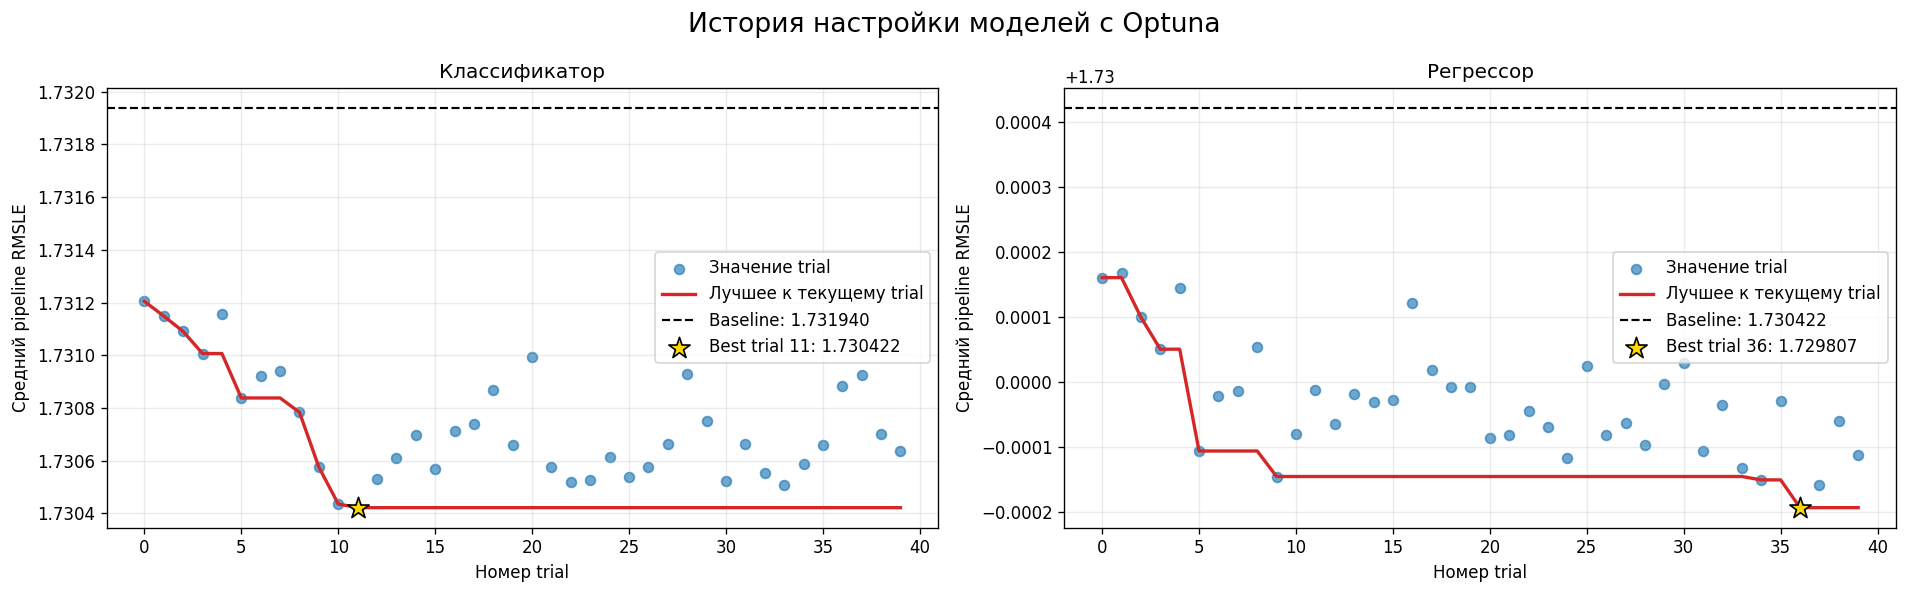

In [39]:
def optuna_history_frame(study):
    records = [
        {
            "trial": trial.number,
            "value": trial.value,
        }
        for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
        )
    ]

    history = (
        pd.DataFrame(records)
        .sort_values("trial")
        .reset_index(drop=True)
    )

    history["best_so_far"] = (
        history["value"].cummin()
    )

    return history


study_specs = {
    "Классификатор": {
        "study": classifier_study,
        "baseline": baseline_mean_rmsle,
    },
    "Регрессор": {
        "study": regressor_study,
        "baseline": regressor_baseline_mean_rmsle,
    },
}


fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 5),
)

for axis, (title, spec) in zip(
    axes,
    study_specs.items(),
):
    history = optuna_history_frame(
        spec["study"]
    )

    best_row = history.loc[
        history["value"].idxmin()
    ]

    axis.scatter(
        history["trial"],
        history["value"],
        alpha=0.65,
        s=35,
        label="Значение trial",
    )

    axis.plot(
        history["trial"],
        history["best_so_far"],
        color="tab:red",
        linewidth=2,
        label="Лучшее к текущему trial",
    )

    axis.axhline(
        spec["baseline"],
        color="black",
        linestyle="--",
        linewidth=1.3,
        label=f"Baseline: {spec['baseline']:.6f}",
    )

    axis.scatter(
        best_row["trial"],
        best_row["value"],
        color="gold",
        edgecolor="black",
        marker="*",
        s=180,
        zorder=5,
        label=(
            f"Best trial {int(best_row['trial'])}: "
            f"{best_row['value']:.6f}"
        ),
    )

    axis.set_title(title)
    axis.set_xlabel("Номер trial")
    axis.set_ylabel("Средний pipeline RMSLE")
    axis.grid(alpha=0.25)
    axis.legend()

fig.suptitle(
    "История настройки моделей с Optuna",
    fontsize=16,
)

plt.tight_layout()
plt.show()

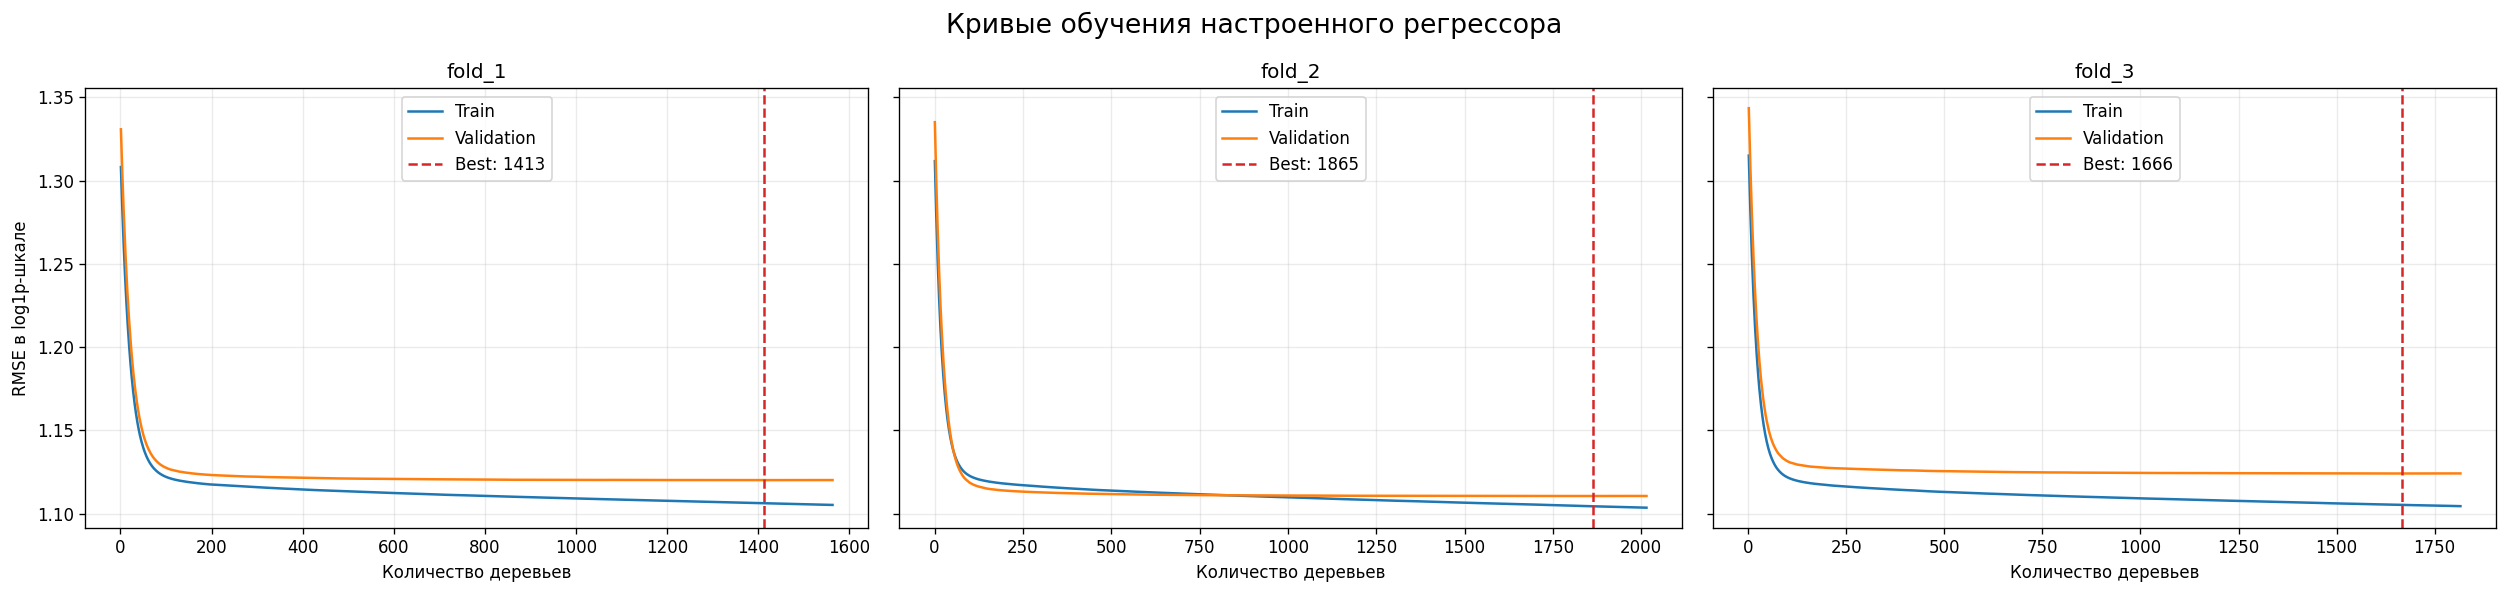

In [40]:
fig, axes = plt.subplots(
    1,
    len(TUNING_SPLITS),
    figsize=(21, 5),
    sharey=True,
)

for axis, fold_name in zip(axes, TUNING_SPLITS):
    history = tuned_regressor_histories[fold_name]

    train_rmse = np.asarray(history["train"]["rmse"])
    valid_rmse = np.asarray(history["validation"]["rmse"])
    iterations = np.arange(1, len(train_rmse) + 1)

    best_iteration = int(
        tuned_regressor_results.loc[fold_name, "best_iteration"]
    )

    axis.plot(iterations, train_rmse, label="Train")
    axis.plot(iterations, valid_rmse, label="Validation")

    axis.axvline(
        best_iteration,
        color="tab:red",
        linestyle="--",
        label=f"Best: {best_iteration}",
    )

    axis.set_title(fold_name)
    axis.set_xlabel("Количество деревьев")
    axis.grid(alpha=0.25)
    axis.legend()

axes[0].set_ylabel("RMSE в log1p-шкале")

fig.suptitle(
    "Кривые обучения настроенного регрессора",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [41]:
tuned_combination_records = []
tuned_walk_forward_combiner_parameters = {}


for fold_spec in CALIBRATION_FOLD_SPECS:
    fold_name = fold_spec["fold"]

    calibration_positions = np.concatenate(
        [
            np.arange(
                TUNING_SPLITS[calibration_fold]["valid"].start,
                TUNING_SPLITS[calibration_fold]["valid"].stop,
            )
            for calibration_fold in fold_spec["calibration_folds"]
        ]
    )

    valid_slice = TUNING_SPLITS[fold_name]["valid"]
    valid_positions = np.arange(valid_slice.start, valid_slice.stop)

    calibration_raw_probability = tuned_classifier_oof_probability[
        calibration_positions
    ].astype(np.float64)

    calibration_predicted_log = tuned_regressor_oof_predicted_log[
        calibration_positions
    ].astype(np.float64)

    calibration_actual_gmv = y_gmv[calibration_positions]

    valid_predicted_log = tuned_regressor_oof_predicted_log[
        valid_positions
    ].astype(np.float64)

    valid_actual_gmv = y_gmv[valid_positions]

    sigmoid_calibrator = walk_forward_calibrators["sigmoid"][fold_name]
    isotonic_calibrator = walk_forward_calibrators["isotonic"][fold_name]

    calibration_probability_variants = {
        "raw": calibration_raw_probability,
        "sigmoid": sigmoid_calibrator.predict_proba(
            to_logit(calibration_raw_probability)
        )[:, 1],
        "isotonic": isotonic_calibrator.predict(
            calibration_raw_probability
        ),
    }

    valid_probability_variants = {
        method: walk_forward_probability[method][valid_positions].astype(
            np.float64
        )
        for method in ("raw", "sigmoid", "isotonic")
    }

    for probability_method in ("raw", "sigmoid", "isotonic"):
        calibration_probability = calibration_probability_variants[
            probability_method
        ]
        valid_probability = valid_probability_variants[
            probability_method
        ]

        assert np.isfinite(calibration_probability).all()
        assert np.isfinite(valid_probability).all()
        assert np.isfinite(calibration_predicted_log).all()
        assert np.isfinite(valid_predicted_log).all()

        fitted_threshold, threshold_train_rmsle = fit_hard_threshold(
            calibration_probability,
            calibration_predicted_log,
            calibration_actual_gmv,
        )

        fitted_scale, fitted_gamma, scale_gamma_train_rmsle = (
            fit_scale_gamma(
                calibration_probability,
                calibration_predicted_log,
                calibration_actual_gmv,
            )
        )

        tuned_walk_forward_combiner_parameters[
            (fold_name, probability_method)
        ] = {
            "threshold": fitted_threshold,
            "scale": fitted_scale,
            "gamma": fitted_gamma,
        }

        positive_gmv_prediction = np.expm1(valid_predicted_log)

        prediction_variants = {
            "soft_log": combine_two_stage_predictions(
                valid_probability,
                valid_predicted_log,
                scale=1.0,
                gamma=1.0,
            ).prediction,
            "expected_gmv": (
                valid_probability * positive_gmv_prediction
            ),
            "hard_threshold": np.where(
                valid_probability >= fitted_threshold,
                positive_gmv_prediction,
                0.0,
            ),
            "scale_gamma": combine_two_stage_predictions(
                valid_probability,
                valid_predicted_log,
                scale=fitted_scale,
                gamma=fitted_gamma,
            ).prediction,
        }

        for combiner, prediction in prediction_variants.items():
            result = pipeline_metrics(valid_actual_gmv, prediction)

            tuned_combination_records.append(
                {
                    "fold": fold_name,
                    "probability_method": probability_method,
                    "combiner": combiner,
                    "rmsle": result["rmsle"],
                    "sum_ratio": result["sum_ratio"],
                    "log_bias": result["log_bias"],
                    "threshold": (
                        fitted_threshold
                        if combiner == "hard_threshold"
                        else np.nan
                    ),
                    "scale": (
                        fitted_scale
                        if combiner == "scale_gamma"
                        else np.nan
                    ),
                    "gamma": (
                        fitted_gamma
                        if combiner == "scale_gamma"
                        else np.nan
                    ),
                    "train_rmsle": (
                        threshold_train_rmsle
                        if combiner == "hard_threshold"
                        else (
                            scale_gamma_train_rmsle
                            if combiner == "scale_gamma"
                            else np.nan
                        )
                    ),
                }
            )


tuned_walk_forward_combination_results = (
    pd.DataFrame(tuned_combination_records)
    .set_index(["fold", "probability_method", "combiner"])
    .sort_index()
)


tuned_walk_forward_combination_summary = (
    tuned_walk_forward_combination_results
    .reset_index()
    .groupby(["probability_method", "combiner"])
    .agg(
        mean_rmsle=("rmsle", "mean"),
        worst_rmsle=("rmsle", "max"),
        rmsle_range=(
            "rmsle",
            lambda values: values.max() - values.min(),
        ),
        mean_sum_ratio=("sum_ratio", "mean"),
        mean_absolute_log_bias=(
            "log_bias",
            lambda values: values.abs().mean(),
        ),
    )
    .sort_values(["mean_rmsle", "worst_rmsle"])
)


display(tuned_walk_forward_combination_results)
display(tuned_walk_forward_combination_summary)

rmsle  sum_ratio  log_bias  \
fold   probability_method combiner                                        
fold_2 isotonic           expected_gmv    1.970671   0.559251  0.823234   
                          hard_threshold  2.004097   0.581799 -0.003865   
                          scale_gamma     1.733378   0.389782 -0.079929   
                          soft_log        1.732156   0.417007 -0.048286   
       raw                expected_gmv    1.984022   0.565362  0.849304   
                          hard_threshold  2.004392   0.582363  0.001361   
                          scale_gamma     1.733383   0.380731 -0.081227   
                          soft_log        1.731479   0.426138 -0.002573   
       sigmoid            expected_gmv    1.971766   0.559068  0.826150   
                          hard_threshold  2.004281   0.582726  0.004712   
                          scale_gamma     1.733129   0.387836 -0.079112   
                          soft_log        1.731902   0.415215 -0.047779   
fold_3 isotonic           expected_gmv    2.055530   0.632965  0.987513   
                          hard_threshold  2.032595   0.657059  0.162223   
                          scale_gamma     1.740344   0.471044  0.115122   
                          soft_log        1.740959   0.477524  0.123935   
       raw                expected_gmv    2.060058   0.637579  0.997352   
                          hard_threshold  2.034556   0.661139  0.197593   
                          scale_gamma     1.740472   0.458591  0.113660   
                          soft_log        1.743690   0.485811  0.154123   
       sigmoid            expected_gmv    2.056071   0.632599  0.988881   
                          hard_threshold  2.032739   0.657198  0.163445   
                          scale_gamma     1.740168   0.469434  0.115360   
                          soft_log        1.740817   0.474353  0.124616   

                                          threshold     scale     gamma  \
fold   probability_method combiner                                        
fold_2 isotonic           expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.510       NaN       NaN   
                          scale_gamma           NaN  0.986928  1.000307   
                          soft_log              NaN       NaN       NaN   
       raw                expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.520       NaN       NaN   
                          scale_gamma           NaN  0.979860  1.036069   
                          soft_log              NaN       NaN       NaN   
       sigmoid            expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.500       NaN       NaN   
                          scale_gamma           NaN  0.986713  0.999330   
                          soft_log              NaN       NaN       NaN   
fold_3 isotonic           expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.505       NaN       NaN   
                          scale_gamma           NaN  0.997531  1.002941   
                          soft_log              NaN       NaN       NaN   
       raw                expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.510       NaN       NaN   
                          scale_gamma           NaN  0.989742  1.016942   
                          soft_log              NaN       NaN       NaN   
       sigmoid            expected_gmv          NaN       NaN       NaN   
                          hard_threshold      0.510       NaN       NaN   
                          scale_gamma           NaN  0.998285  1.005666   
                          soft_log              NaN       NaN       NaN   

                                          train_rmsle  
fold   probability_method combiner                     
fold_2 isotonic           expec

mean_rmsle  worst_rmsle  rmsle_range  \
probability_method combiner                                               
sigmoid            soft_log          1.736359     1.740817     0.008916   
isotonic           soft_log          1.736557     1.740959     0.008803   
sigmoid            scale_gamma       1.736648     1.740168     0.007039   
isotonic           scale_gamma       1.736861     1.740344     0.006966   
raw                scale_gamma       1.736928     1.740472     0.007089   
                   soft_log          1.737584     1.743690     0.012211   
isotonic           expected_gmv      2.013100     2.055530     0.084858   
sigmoid            expected_gmv      2.013919     2.056071     0.084304   
isotonic           hard_threshold    2.018346     2.032595     0.028497   
sigmoid            hard_threshold    2.018510     2.032739     0.028458   
raw                hard_threshold    2.019474     2.034556     0.030164   
                   expected_gmv      2.022040     2.060058     0.076036   

                                   mean_sum_ratio  mean_absolute_log_bias  
probability_method combiner                                                
sigmoid            soft_log              0.444784                0.086197  
isotonic           soft_log              0.447266                0.086111  
sigmoid            scale_gamma           0.428635                0.097236  
isotonic           scale_gamma           0.430413                0.097526  
raw                scale_gamma           0.419661                0.097444  
                   soft_log              0.455974                0.078348  
isotonic           expected_gmv          0.596108                0.905373  
sigmoid            expected_gmv          0.595833                0.907516  
isotonic           hard_threshold        0.619429                0.083044  
sigmoid            hard_threshold        0.619962                0.084079  
raw                hard_threshold        0.621751                0.099477  
                   expected_gmv          0.601471                0.923328

Финальный OOF-победитель — tuned classifier + sigmoid calibration + tuned positive regressor + soft_log.
Почему фиксируем его:
- лучший средний RMSLE: 1.736359
- scale_gamma хуже по среднему RMSLE на 0.000289
- scale_gamma также хуже по sum_ratio и абсолютному log-bias
- найденные scale и gamma снова почти равны 1
- hard threshold и expected GMV заметно проигрывают.

## 12. Фиксация финальной конфигурации

Конфигурация фиксируется до первого обращения к holdout. Итерации финальных моделей берутся из последнего временного фолда как наиболее близкого к holdout.

In [42]:
winner_key = tuned_walk_forward_combination_summary.index[0]

assert winner_key == ("sigmoid", "soft_log")

winner_metrics = tuned_walk_forward_combination_summary.loc[
    winner_key
]

FINAL_CLASSIFIER_ITERATION = int(
    tuned_classifier_results.loc["fold_3", "best_iteration"]
)

FINAL_REGRESSOR_ITERATION = int(
    tuned_regressor_results.loc["fold_3", "best_iteration"]
)

# Holdout пока не должен иметь OOF-прогнозов.
assert not np.isfinite(
    tuned_classifier_oof_probability[HOLDOUT_SPLIT["valid"]]
).any()

assert not np.isfinite(
    tuned_regressor_oof_predicted_log[HOLDOUT_SPLIT["valid"]]
).any()


FINAL_CONFIGURATION = {
    "classifier": {
        "params": dict(classifier_best_params),
        "n_estimators": FINAL_CLASSIFIER_ITERATION,
        "iteration_policy": "latest_fold",
    },
    "regressor": {
        "params": dict(regressor_best_params),
        "n_estimators": FINAL_REGRESSOR_ITERATION,
        "iteration_policy": "latest_fold",
        "positive_only": True,
        "target": "log1p_gmv",
    },
    "calibration": {
        "method": "sigmoid",
        "fit_folds": tuple(TUNING_SPLITS),
    },
    "combination": {
        "method": "soft_log",
        "scale": 1.0,
        "gamma": 1.0,
    },
    "selection": {
        "validation_folds": ("fold_2", "fold_3"),
        "mean_rmsle": float(winner_metrics["mean_rmsle"]),
        "worst_rmsle": float(winner_metrics["worst_rmsle"]),
        "rmsle_range": float(winner_metrics["rmsle_range"]),
        "mean_sum_ratio": float(winner_metrics["mean_sum_ratio"]),
        "mean_absolute_log_bias": float(
            winner_metrics["mean_absolute_log_bias"]
        ),
    },
    "holdout": {
        "date": HOLDOUT_DATE.isoformat(),
        "used_for_selection": False,
    },
}


frozen_configuration_summary = pd.Series(
    {
        "classifier_iteration": FINAL_CLASSIFIER_ITERATION,
        "regressor_iteration": FINAL_REGRESSOR_ITERATION,
        "calibration": "sigmoid",
        "combiner": "soft_log",
        "validation_mean_rmsle": winner_metrics["mean_rmsle"],
        "validation_worst_rmsle": winner_metrics["worst_rmsle"],
        "validation_mean_sum_ratio": winner_metrics["mean_sum_ratio"],
        "holdout_date": HOLDOUT_DATE,
    },
    name="value",
).to_frame()


print("Final configuration frozen before holdout: PASS")
display(frozen_configuration_summary)

Final configuration frozen before holdout: PASS


,value
classifier_iteration,722
regressor_iteration,1666
calibration,sigmoid
combiner,soft_log
validation_mean_rmsle,1.736359
validation_worst_rmsle,1.740817
validation_mean_sum_ratio,0.444784
holdout_date,2026-01-14


## 13. Обучение моделей перед holdout

- Модели обучаются на всей размеченной истории до 2025-12-15 с заранее зафиксированными параметрами и количеством итераций. 
- Sigmoid-калибратор обучается на tuned OOF-прогнозах трёх временных фолдов.

In [43]:
final_fit_started = perf_counter()

train_slice = HOLDOUT_SPLIT["train"]

X_final_train = X.iloc[train_slice]
y_final_train_class = y_nonzero[train_slice]
y_final_train_gmv = y_gmv[train_slice]

final_train_positive = y_final_train_class == 1


# Sigmoid-калибратор обучается только на OOF-прогнозах.
calibration_mask = tuned_classifier_oof_mask

final_sigmoid_calibrator = LogisticRegression(
    C=1e6,
    solver="lbfgs",
    max_iter=1_000,
)

final_sigmoid_calibrator.fit(
    to_logit(
        tuned_classifier_oof_probability[
            calibration_mask
        ]
    ),
    y_nonzero[calibration_mask],
)


# Финальный классификатор.
classifier_fit_started = perf_counter()

final_classifier = lgb.LGBMClassifier(
    objective="binary",
    metric="None",
    n_estimators=FINAL_CLASSIFIER_ITERATION,
    **classifier_best_params,
)

final_classifier.fit(
    X_final_train,
    y_final_train_class,
)

classifier_fit_duration = (
    perf_counter() - classifier_fit_started
)


# Финальный положительный регрессор.
regressor_fit_started = perf_counter()

X_final_train_positive = X_final_train.iloc[
    np.flatnonzero(final_train_positive)
]

y_final_train_positive_log = np.log1p(
    y_final_train_gmv[final_train_positive]
)

final_regressor = lgb.LGBMRegressor(
    objective="regression_l2",
    metric="None",
    n_estimators=FINAL_REGRESSOR_ITERATION,
    **regressor_best_params,
)

final_regressor.fit(
    X_final_train_positive,
    y_final_train_positive_log,
)

regressor_fit_duration = (
    perf_counter() - regressor_fit_started
)

final_fit_duration = perf_counter() - final_fit_started


assert final_classifier.n_estimators == FINAL_CLASSIFIER_ITERATION
assert final_regressor.n_estimators == FINAL_REGRESSOR_ITERATION

assert np.isfinite(
    final_sigmoid_calibrator.coef_
).all()

assert np.isfinite(
    final_sigmoid_calibrator.intercept_
).all()


print("Final pre-holdout fit: PASS")
print(f"Training rows: {len(X_final_train):,}")
print(f"Positive rows: {int(final_train_positive.sum()):,}")
print(f"Calibration rows: {int(calibration_mask.sum()):,}")
print(f"Classifier time: {classifier_fit_duration:.1f}s")
print(f"Regressor time: {regressor_fit_duration:.1f}s")
print(f"Total time: {final_fit_duration:.1f}s")


del (
    X_final_train_positive,
    y_final_train_positive_log,
)
gc.collect()

Final pre-holdout fit: PASS
Training rows: 2,097,330
Positive rows: 1,098,994
Calibration rows: 735,683
Classifier time: 197.8s
Regressor time: 122.4s
Total time: 320.4s


21598

## 14. Оценка модели на holdout

Holdout используется только для финальной оценки и не влияет на выбор моделей, калибратора или способа объединения.

In [44]:
holdout_started = perf_counter()

holdout_slice = HOLDOUT_SPLIT["valid"]

X_holdout = X.iloc[holdout_slice]
y_holdout_class = y_nonzero[holdout_slice]
y_holdout_gmv = y_gmv[holdout_slice]

holdout_raw_probability = final_classifier.predict_proba(
    X_holdout
)[:, 1]

holdout_calibrated_probability = (
    final_sigmoid_calibrator.predict_proba(
        to_logit(holdout_raw_probability)
    )[:, 1]
)

holdout_predicted_log = np.maximum(
    final_regressor.predict(X_holdout),
    0.0,
)

holdout_raw_prediction = combine_two_stage_predictions(
    holdout_raw_probability,
    holdout_predicted_log,
    scale=1.0,
    gamma=1.0,
).prediction

holdout_final_prediction = combine_two_stage_predictions(
    holdout_calibrated_probability,
    holdout_predicted_log,
    scale=1.0,
    gamma=1.0,
).prediction


assert len(holdout_final_prediction) == len(X_holdout)
assert np.isfinite(holdout_raw_probability).all()
assert np.isfinite(holdout_calibrated_probability).all()
assert np.isfinite(holdout_predicted_log).all()
assert np.isfinite(holdout_final_prediction).all()
assert (holdout_final_prediction >= 0.0).all()


holdout_classifier_metrics = pd.DataFrame(
    {
        "raw": classification_metrics(
            y_holdout_class,
            holdout_raw_probability,
            threshold=0.5,
        ),
        "sigmoid": classification_metrics(
            y_holdout_class,
            holdout_calibrated_probability,
            threshold=0.5,
        ),
    }
).T

holdout_regressor_metrics = pd.Series(
    positive_regression_metrics(
        y_holdout_gmv[y_holdout_class == 1],
        holdout_predicted_log[y_holdout_class == 1],
    ),
    name="value",
).to_frame()

holdout_pipeline_metrics = pd.DataFrame(
    {
        "raw_soft_log": pipeline_metrics(
            y_holdout_gmv,
            holdout_raw_prediction,
        ),
        "sigmoid_soft_log": pipeline_metrics(
            y_holdout_gmv,
            holdout_final_prediction,
        ),
    }
).T


HOLDOUT_EVALUATED = True

print("Holdout evaluation: PASS")
print(f"Holdout rows: {len(X_holdout):,}")
print(f"Evaluation time: {perf_counter() - holdout_started:.1f}s")

display(holdout_classifier_metrics)
display(holdout_regressor_metrics)
display(holdout_pipeline_metrics)

Holdout evaluation: PASS
Holdout rows: 250,000
Evaluation time: 12.7s


,average_precision,logloss,brier,precision,recall,f1
raw,0.879313,0.471248,0.155192,0.769868,0.821699,0.794940
sigmoid,0.879313,0.469337,0.154454,0.781709,0.803559,0.792483


,value
rmse_log,1.117514
mae_log,0.883077
log_bias,0.180083
sum_ratio,0.692645
negative_log_prediction_share,0.000000


,rmsle,sum_ratio,log_bias
raw_soft_log,1.684754,0.522453,0.214702
sigmoid_soft_log,1.677196,0.500949,0.154053


### Вывод по holdout

Финальная конфигурация успешно прошла untouched holdout:

- RMSLE: 1.677196
- sigmoid-калибровка улучшила raw soft-log RMSLE на 0.007558
- logloss и Brier также улучшились
- положительный регрессор сохранил стабильное качество: RMSE(log)=1.117514
- агрегатный GMV остаётся заниженным: sum_ratio=0.500949.

После оценки holdout конфигурация не изменяется.

## 15. Финальное обучение на всех размеченных данных

Переобучаем модели на всей размеченной истории до 2026-01-14.

In [45]:
production_fit_started = perf_counter()

assert len(X) == len(y_nonzero) == len(y_gmv)
assert np.isfinite(y_nonzero).all()
assert np.isfinite(y_gmv).all()


# Добавляем holdout как честный out-of-sample период
# в обучающую выборку финального калибратора.
production_calibration_probability = np.concatenate(
    [
        tuned_classifier_oof_probability[
            tuned_classifier_oof_mask
        ].astype(np.float64),
        holdout_raw_probability.astype(np.float64),
    ]
)

production_calibration_target = np.concatenate(
    [
        y_nonzero[tuned_classifier_oof_mask],
        y_holdout_class,
    ]
)

production_sigmoid_calibrator = LogisticRegression(
    C=1e6,
    solver="lbfgs",
    max_iter=1_000,
)

production_sigmoid_calibrator.fit(
    to_logit(production_calibration_probability),
    production_calibration_target,
)


# Классификатор на всей размеченной истории.
classifier_started = perf_counter()

production_classifier = lgb.LGBMClassifier(
    objective="binary",
    metric="None",
    n_estimators=FINAL_CLASSIFIER_ITERATION,
    **classifier_best_params,
)

production_classifier.fit(
    X,
    y_nonzero,
)

production_classifier_duration = (
    perf_counter() - classifier_started
)


# Положительный регрессор на всей размеченной истории.
regressor_started = perf_counter()

production_positive_mask = y_nonzero == 1
X_production_positive = X.iloc[
    np.flatnonzero(production_positive_mask)
]

y_production_positive_log = np.log1p(
    y_gmv[production_positive_mask]
)

production_regressor = lgb.LGBMRegressor(
    objective="regression_l2",
    metric="None",
    n_estimators=FINAL_REGRESSOR_ITERATION,
    **regressor_best_params,
)

production_regressor.fit(
    X_production_positive,
    y_production_positive_log,
)

production_regressor_duration = (
    perf_counter() - regressor_started
)

production_fit_duration = (
    perf_counter() - production_fit_started
)


assert production_classifier.n_estimators_ == FINAL_CLASSIFIER_ITERATION
assert production_regressor.n_estimators_ == FINAL_REGRESSOR_ITERATION

assert len(production_calibration_probability) == (
    int(tuned_classifier_oof_mask.sum())
    + len(y_holdout_class)
)

assert np.isfinite(
    production_sigmoid_calibrator.coef_
).all()

assert np.isfinite(
    production_sigmoid_calibrator.intercept_
).all()


production_fit_summary = pd.Series(
    {
        "training_rows": len(X),
        "positive_rows": int(production_positive_mask.sum()),
        "calibration_rows": len(production_calibration_probability),
        "classifier_iterations": FINAL_CLASSIFIER_ITERATION,
        "regressor_iterations": FINAL_REGRESSOR_ITERATION,
        "classifier_seconds": production_classifier_duration,
        "regressor_seconds": production_regressor_duration,
        "total_seconds": production_fit_duration,
    },
    name="value",
).to_frame()


print("Production models fit: PASS")
display(production_fit_summary)


del (
    X_production_positive,
    y_production_positive_log,
)
_ = gc.collect()

Production models fit: PASS


,value
training_rows,2.347330e+06
positive_rows,1.234159e+06
calibration_rows,9.856830e+05
classifier_iterations,7.220000e+02
regressor_iterations,1.666000e+03
classifier_seconds,2.338916e+02
regressor_seconds,1.397602e+02
total_seconds,3.738584e+02


## 16. Загрузка inference-среза

Из parquet загружается только срез 2026-02-13.

In [46]:
INFERENCE_FILTER = (
    ds.field("cutoff_date") == INFERENCE_DATE
)

inference_table = prepared_dataset.to_table(
    columns=[
        "user_id",
        "target_nonzero",
        "target_gmv_30d",
        *FEATURE_COLUMNS,
    ],
    filter=INFERENCE_FILTER,
)

expected_inference_rows = int(
    cutoff_summary.loc[
        cutoff_summary["cutoff_date"] == INFERENCE_DATE,
        "rows",
    ].iloc[0]
)

assert inference_table.num_rows == expected_inference_rows
assert (
    inference_table["target_nonzero"].null_count
    == expected_inference_rows
)
assert (
    inference_table["target_gmv_30d"].null_count
    == expected_inference_rows
)


inference_user_ids = inference_table[
    "user_id"
].to_numpy(zero_copy_only=False)

X_inference = inference_table.select(
    list(FEATURE_COLUMNS)
).to_pandas(split_blocks=True)

validate_feature_matrix(
    X_inference,
    FEATURE_COLUMNS,
)

assert len(X_inference) == len(inference_user_ids)
assert len(np.unique(inference_user_ids)) == len(inference_user_ids)


inference_data_summary = pd.Series(
    {
        "rows": len(X_inference),
        "features": X_inference.shape[1],
        "unique_users": len(np.unique(inference_user_ids)),
        "memory_gb": (
            X_inference.memory_usage(
                deep=True,
                index=True,
            ).sum()
            / 1024**3
        ),
        "cutoff_date": INFERENCE_DATE,
    },
    name="value",
).to_frame()


print("Inference data validation: PASS")
display(inference_data_summary)


del inference_table
_ = gc.collect()

Inference data validation: PASS


,value
rows,250000
features,91
unique_users,250000
memory_gb,0.081258
cutoff_date,2026-02-13


In [47]:
inference_started = perf_counter()

inference_raw_probability = (
    production_classifier.predict_proba(
        X_inference
    )[:, 1]
)

inference_calibrated_probability = (
    production_sigmoid_calibrator.predict_proba(
        to_logit(inference_raw_probability)
    )[:, 1]
)

inference_predicted_log = np.maximum(
    production_regressor.predict(
        X_inference
    ),
    0.0,
)

inference_components = (
    combine_two_stage_predictions(
        inference_calibrated_probability,
        inference_predicted_log,
        scale=1.0,
        gamma=1.0,
    )
)

inference_prediction = (
    inference_components.prediction
)


assert len(inference_prediction) == len(X_inference)
assert np.isfinite(inference_raw_probability).all()
assert np.isfinite(inference_calibrated_probability).all()
assert np.isfinite(inference_predicted_log).all()
assert np.isfinite(inference_prediction).all()
assert (inference_prediction >= 0.0).all()


submission = make_submission(
    inference_user_ids,
    inference_prediction,
)

validate_submission(
    submission,
    inference_user_ids,
)


inference_prediction_summary = pd.Series(
    {
        "rows": len(inference_prediction),
        "raw_probability_mean": (
            inference_raw_probability.mean()
        ),
        "calibrated_probability_mean": (
            inference_calibrated_probability.mean()
        ),
        "predicted_log_mean": (
            inference_predicted_log.mean()
        ),
        "prediction_mean": (
            inference_prediction.mean()
        ),
        "prediction_median": np.median(
            inference_prediction
        ),
        "prediction_p90": np.quantile(
            inference_prediction,
            0.90,
        ),
        "prediction_p99": np.quantile(
            inference_prediction,
            0.99,
        ),
        "prediction_max": (
            inference_prediction.max()
        ),
        "prediction_sum": (
            inference_prediction.sum()
        ),
        "zero_prediction_share": (
            inference_prediction == 0.0
        ).mean(),
        "duration_seconds": (
            perf_counter() - inference_started
        ),
    },
    name="value",
).to_frame()


print("Production inference: PASS")
display(inference_prediction_summary)
display(submission.head())

Production inference: PASS


,value
rows,2.500000e+05
raw_probability_mean,5.729940e-01
calibrated_probability_mean,5.539356e-01
predicted_log_mean,4.013503e+00
prediction_mean,4.022362e+01
prediction_median,7.502645e+00
prediction_p90,1.044508e+02
prediction_p99,4.637507e+02
prediction_max,4.094528e+03
prediction_sum,1.005590e+07


,user_id,predict
0,2,1.720079
1,7,83.554121
2,15,7.265970
3,18,161.610338
4,23,0.482513


Распределение выглядит корректно:
- калибровка снижает среднюю вероятность 0.573 -> 0.554, что согласуется с holdout
- медиана 7.50, p99 463.75, максимум 4094.53 — тяжёлый, но контролируемый хвост
- нулевая доля прогнозов ожидаемо равна нулю: soft_log плавно уменьшает прогноз, а не зануляет его
- итоговая сумма — около 10.06 млн.

Теперь сохраним submission, модели и конфигурацию.

In [48]:
SUBMISSION_PATH = (
    ARTIFACT_DIR
    / "two_stage_submission_sigmoid_soft_log.csv"
)

CLASSIFIER_MODEL_PATH = (
    ARTIFACT_DIR
    / "two_stage_classifier.txt"
)

REGRESSOR_MODEL_PATH = (
    ARTIFACT_DIR
    / "two_stage_regressor.txt"
)

CONFIGURATION_PATH = (
    ARTIFACT_DIR
    / "two_stage_configuration.json"
)

CALIBRATION_PATH = (
    ARTIFACT_DIR
    / "two_stage_sigmoid_calibration.json"
)

HOLDOUT_REPORT_PATH = (
    ARTIFACT_DIR
    / "two_stage_holdout_metrics.json"
)

FEATURE_COLUMNS_PATH = (
    ARTIFACT_DIR
    / "two_stage_feature_columns.json"
)


calibration_artifact = {
    "method": "sigmoid",
    "input": "logit(raw_probability)",
    "coefficient": float(
        production_sigmoid_calibrator.coef_[0, 0]
    ),
    "intercept": float(
        production_sigmoid_calibrator.intercept_[0]
    ),
    "training_rows": len(
        production_calibration_probability
    ),
}


holdout_report = {
    "classifier": holdout_classifier_metrics.to_dict(
        orient="index"
    ),
    "positive_regressor": (
        holdout_regressor_metrics["value"].to_dict()
    ),
    "pipeline": holdout_pipeline_metrics.to_dict(
        orient="index"
    ),
}


production_metadata = {
    **FINAL_CONFIGURATION,
    "forecast": {
        "inference_date": INFERENCE_DATE,
        "forecast_start": FORECAST_START,
        "forecast_end": FORECAST_END,
    },
    "training": {
        "rows": len(X),
        "positive_rows": int(
            production_positive_mask.sum()
        ),
        "features": len(FEATURE_COLUMNS),
        "calibration_rows": len(
            production_calibration_probability
        ),
    },
    "prediction": (
        inference_prediction_summary[
            "value"
        ].to_dict()
    ),
    "versions": versions[
        "version"
    ].to_dict(),
}


save_submission_csv(
    submission,
    SUBMISSION_PATH,
)

save_lightgbm_model(
    production_classifier,
    CLASSIFIER_MODEL_PATH,
)

save_lightgbm_model(
    production_regressor,
    REGRESSOR_MODEL_PATH,
)

save_json(
    production_metadata,
    CONFIGURATION_PATH,
)

save_json(
    calibration_artifact,
    CALIBRATION_PATH,
)

save_json(
    holdout_report,
    HOLDOUT_REPORT_PATH,
)

save_json(
    list(FEATURE_COLUMNS),
    FEATURE_COLUMNS_PATH,
)


# Проверка сохранённого submission.
saved_submission = load_submission_csv(
    SUBMISSION_PATH
)

validate_submission(
    saved_submission,
    inference_user_ids,
)


# Проверка сохранённых LightGBM-моделей.
loaded_classifier = lgb.Booster(
    model_file=str(CLASSIFIER_MODEL_PATH)
)

loaded_regressor = lgb.Booster(
    model_file=str(REGRESSOR_MODEL_PATH)
)

verification_sample = X_inference.iloc[:1_000]

np.testing.assert_allclose(
    loaded_classifier.predict(
        verification_sample
    ),
    production_classifier.predict_proba(
        verification_sample
    )[:, 1],
    rtol=1e-10,
    atol=1e-12,
)

np.testing.assert_allclose(
    loaded_regressor.predict(
        verification_sample
    ),
    production_regressor.predict(
        verification_sample
    ),
    rtol=1e-10,
    atol=1e-12,
)


artifact_manifest = pd.Series(
    {
        "submission": SUBMISSION_PATH,
        "classifier": CLASSIFIER_MODEL_PATH,
        "regressor": REGRESSOR_MODEL_PATH,
        "configuration": CONFIGURATION_PATH,
        "calibration": CALIBRATION_PATH,
        "holdout_metrics": HOLDOUT_REPORT_PATH,
        "feature_columns": FEATURE_COLUMNS_PATH,
    },
    name="path",
).to_frame()


print("Artifact round-trip validation: PASS")
display(artifact_manifest)

LightGBMError: Could not open C:\Users\savin\OneDrive\Документы\Мои документы\Проекты\E-Cup 2026\E-CUP-2026\data\two_stage_artifacts\two_stage_classifier.txt

In [49]:
# Читаем модели средствами Python, чтобы избежать проблемы
# LightGBM с кириллицей в Windows-пути.
loaded_classifier = lgb.Booster(
    model_str=CLASSIFIER_MODEL_PATH.read_text(
        encoding="utf-8"
    )
)

loaded_regressor = lgb.Booster(
    model_str=REGRESSOR_MODEL_PATH.read_text(
        encoding="utf-8"
    )
)

verification_sample = X_inference.iloc[:1_000]

np.testing.assert_allclose(
    loaded_classifier.predict(
        verification_sample
    ),
    production_classifier.predict_proba(
        verification_sample
    )[:, 1],
    rtol=1e-10,
    atol=1e-12,
)

np.testing.assert_allclose(
    loaded_regressor.predict(
        verification_sample
    ),
    production_regressor.predict(
        verification_sample
    ),
    rtol=1e-10,
    atol=1e-12,
)


saved_submission = load_submission_csv(
    SUBMISSION_PATH
)

validate_submission(
    saved_submission,
    inference_user_ids,
)


artifact_manifest = pd.Series(
    {
        "submission": SUBMISSION_PATH,
        "classifier": CLASSIFIER_MODEL_PATH,
        "regressor": REGRESSOR_MODEL_PATH,
        "configuration": CONFIGURATION_PATH,
        "calibration": CALIBRATION_PATH,
        "holdout_metrics": HOLDOUT_REPORT_PATH,
        "feature_columns": FEATURE_COLUMNS_PATH,
    },
    name="path",
).to_frame()


print("Artifact round-trip validation: PASS")
display(artifact_manifest)

Artifact round-trip validation: PASS


,path
submission,C:\Users\savin\OneDrive\Документы\Мои документ...
classifier,C:\Users\savin\OneDrive\Документы\Мои документ...
regressor,C:\Users\savin\OneDrive\Документы\Мои документ...
configuration,C:\Users\savin\OneDrive\Документы\Мои документ...
calibration,C:\Users\savin\OneDrive\Документы\Мои документ...
holdout_metrics,C:\Users\savin\OneDrive\Документы\Мои документ...
feature_columns,C:\Users\savin\OneDrive\Документы\Мои документ...


### Результат на leaderboard

Финальный submission получил RMSLE **1.654654**.

Попробую постпроцессинг эксперимент без переобучения моделей:
- Берём текущий лучший прогноз sigmoid + soft_log.
- Сортируем строки по калиброванной вероятности покупки.
- Для нижних q% вероятностей заменяем итоговый прогноз на 0.
- Проверяем сетку, например: 0%, 0.5%, 1%, 2%, 3%, 5%, 7.5%, 10%, 12.5%, 15%, 20%.
- Подбираем q только на walk-forward OOF-фолдах 2 и 3.
- Смотрим не только средний RMSLE, но и результат каждого фолда, долю покупателей среди занулённых строк и потерянный реальный GMV.
- Выбираем устойчивое плато, а не случайный лучший порог.
- Зафиксированный q один раз проверяем на holdout.
- Если улучшение подтверждается, создаём отдельный CSV, не перезаписывая текущий submission.

Это отличается от ранее неудачного hard_threshold: там для всех строк выше порога использовался полный прогноз регрессора. Здесь мы сохраняем лучший soft_log почти везде и отсекаем только самый низковероятный хвост.

Риск понятный: для настоящего нуля зануление полностью убирает ошибку, но для пропущенного покупателя может создать большой штраф. Поэтому сначала нужен OOF-подбор.

Baseline mean RMSLE: 1.736359
Best zeroed share: 0.0%
Best mean RMSLE: 1.736359
OOF improvement: 0.000000


,mean_rmsle,worst_rmsle,rmsle_std,mean_probability_cutoff,mean_positive_share_in_zeroed,mean_missed_positive_share,mean_zeroed_gmv_share,rmsle_improvement,rmsle_fold_2,rmsle_fold_3
zeroed_share,,,,,,,,,,
0.0,1.736359,1.740817,0.006304,0.0000,0.0000,0.0000,0.0000,0.000000,1.731902,1.740817
0.5,1.736395,1.740828,0.006269,0.0719,0.0457,0.0004,0.0001,-0.000035,1.731962,1.740828
1.0,1.736506,1.740916,0.006236,0.0805,0.0619,0.0011,0.0005,-0.000147,1.732096,1.740916
1.5,1.736647,1.740997,0.006152,0.0859,0.0718,0.0019,0.0008,-0.000287,1.732297,1.740997
2.0,1.736797,1.741056,0.006023,0.0900,0.0769,0.0027,0.0011,-0.000438,1.732538,1.741056
2.5,1.737005,1.741185,0.005912,0.0937,0.0824,0.0036,0.0016,-0.000645,1.732824,1.741185
3.0,1.737190,1.741303,0.005818,0.0971,0.0858,0.0045,0.0020,-0.000830,1.733076,1.741303
3.5,1.737394,1.741490,0.005793,0.1003,0.0886,0.0055,0.0023,-0.001034,1.733298,1.741490
4.0,1.737623,1.741686,0.005746,0.1032,0.0915,0.0065,0.0027,-0.001263,1.733560,1.741686


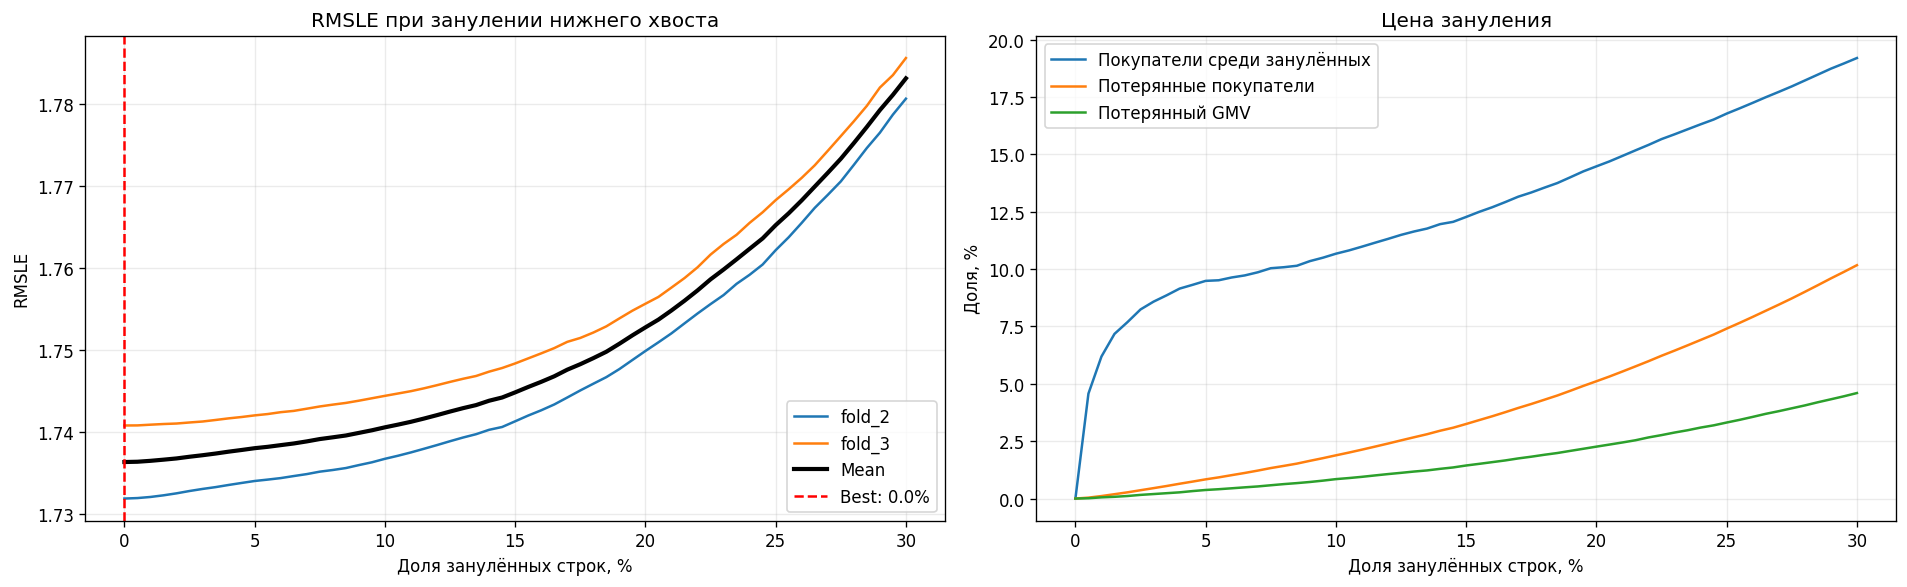

In [51]:
ZEROING_SHARES = np.arange(0.0, 30.5, 0.5)
zeroing_records = []

for fold_spec in CALIBRATION_FOLD_SPECS:
    fold_name = fold_spec["fold"]
    valid_slice = TUNING_SPLITS[fold_name]["valid"]

    probability = walk_forward_probability["sigmoid"][valid_slice].astype(np.float64)
    predicted_log = tuned_regressor_oof_predicted_log[valid_slice].astype(np.float64)
    actual_gmv = np.asarray(y_gmv[valid_slice], dtype=np.float64)

    base_prediction = combine_two_stage_predictions(
        probability, predicted_log, scale=1.0, gamma=1.0
    ).prediction

    probability_order = np.argsort(probability)
    positive_mask = actual_gmv > 0
    total_positive_rows = positive_mask.sum()
    total_gmv = actual_gmv.sum()

    for zeroed_share in ZEROING_SHARES:
        zeroed_rows = round(len(actual_gmv) * zeroed_share / 100)
        zeroed_positions = probability_order[:zeroed_rows]

        prediction = base_prediction.copy()
        prediction[zeroed_positions] = 0.0
        result = pipeline_metrics(actual_gmv, prediction)

        zeroed_positive_rows = positive_mask[zeroed_positions].sum()
        zeroed_gmv = actual_gmv[zeroed_positions].sum()

        zeroing_records.append({
            "fold": fold_name,
            "zeroed_share": zeroed_share,
            "zeroed_rows": zeroed_rows,
            "probability_cutoff": probability[zeroed_positions[-1]] if zeroed_rows else 0.0,
            "rmsle": result["rmsle"],
            "sum_ratio": result["sum_ratio"],
            "log_bias": result["log_bias"],
            "positive_share_in_zeroed": zeroed_positive_rows / zeroed_rows if zeroed_rows else 0.0,
            "missed_positive_share": zeroed_positive_rows / total_positive_rows,
            "zeroed_gmv_share": zeroed_gmv / total_gmv,
        })

zeroing_results = pd.DataFrame(zeroing_records)

zeroing_summary = zeroing_results.groupby("zeroed_share").agg(
    mean_rmsle=("rmsle", "mean"),
    worst_rmsle=("rmsle", "max"),
    rmsle_std=("rmsle", "std"),
    mean_probability_cutoff=("probability_cutoff", "mean"),
    mean_positive_share_in_zeroed=("positive_share_in_zeroed", "mean"),
    mean_missed_positive_share=("missed_positive_share", "mean"),
    mean_zeroed_gmv_share=("zeroed_gmv_share", "mean"),
)

fold_rmsle = zeroing_results.pivot(
    index="zeroed_share", columns="fold", values="rmsle"
).add_prefix("rmsle_")

baseline_rmsle = zeroing_summary.loc[0.0, "mean_rmsle"]
zeroing_summary["rmsle_improvement"] = baseline_rmsle - zeroing_summary["mean_rmsle"]
zeroing_summary = zeroing_summary.join(fold_rmsle)

best_zeroed_share = zeroing_summary["mean_rmsle"].idxmin()
best_zeroing_result = zeroing_summary.loc[best_zeroed_share]

print(f"Baseline mean RMSLE: {baseline_rmsle:.6f}")
print(f"Best zeroed share: {best_zeroed_share:.1f}%")
print(f"Best mean RMSLE: {best_zeroing_result['mean_rmsle']:.6f}")
print(f"OOF improvement: {best_zeroing_result['rmsle_improvement']:.6f}")

zeroing_top = zeroing_summary.sort_values("mean_rmsle").head(15).round({
    "mean_rmsle": 6,
    "worst_rmsle": 6,
    "rmsle_std": 6,
    "rmsle_improvement": 6,
    "mean_probability_cutoff": 4,
    "mean_positive_share_in_zeroed": 4,
    "mean_missed_positive_share": 4,
    "mean_zeroed_gmv_share": 4,
    "rmsle_fold_2": 6,
    "rmsle_fold_3": 6,
})

display(zeroing_top)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for fold_name, fold_data in zeroing_results.groupby("fold"):
    axes[0].plot(fold_data["zeroed_share"], fold_data["rmsle"], label=fold_name)

axes[0].plot(
    zeroing_summary.index,
    zeroing_summary["mean_rmsle"],
    color="black",
    linewidth=2.5,
    label="Mean",
)
axes[0].axvline(best_zeroed_share, color="red", linestyle="--", label=f"Best: {best_zeroed_share:.1f}%")
axes[0].set(title="RMSLE при занулении нижнего хвоста", xlabel="Доля занулённых строк, %", ylabel="RMSLE")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(
    zeroing_summary.index,
    zeroing_summary["mean_positive_share_in_zeroed"] * 100,
    label="Покупатели среди занулённых",
)
axes[1].plot(
    zeroing_summary.index,
    zeroing_summary["mean_missed_positive_share"] * 100,
    label="Потерянные покупатели",
)
axes[1].plot(
    zeroing_summary.index,
    zeroing_summary["mean_zeroed_gmv_share"] * 100,
    label="Потерянный GMV",
)
axes[1].set(title="Цена зануления", xlabel="Доля занулённых строк, %", ylabel="Доля, %")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

Зануление нужно отвергнуть:
- ухудшение начинается уже при 0.5%: −0.000035 RMSLE
- оно наблюдается на обоих фолдах
- дальше ошибка монотонно растёт
- даже среди нижних 0.5% находятся примерно 4.6% покупателей. 

Несколько ошибочно занулённых покупателей дают больший штраф, чем выигрыш на множестве настоящих нулей.
Это подтверждает, что soft_log уже корректно создаёт очень маленькие, но ненулевые прогнозы.

Попробуем stacked-калибровку классификатора.
Вместо текущей калибровки

```
logit(raw_probability) → sigmoid → calibrated_probability
```

используем:

```
logit(raw_probability) + predicted_log_gmv
                    ↓
          LogisticRegression
                    ↓
        calibrated_probability
                    ↓
                 soft_log
```

Регрессор здесь сообщает калибратору «ценность/профиль» потенциального покупателя. Это обратное направление относительно уже проверенного эксперимента, где вероятность добавлялась в регрессор.

Проверка останется честной:
- для fold_2 метакалибратор обучается только на OOF fold_1
- для fold_3 — только на OOF fold_1 + fold_2
- сравниваем обычный sigmoid и stacked_sigmoid
- основная метрика — pipeline RMSLE
- дополнительно проверяем logloss, Brier и стабильность между фолдами

fold_2: sigmoid=1.731902, stacked=1.732167
fold_3: sigmoid=1.740817, stacked=1.740791


average_precision   logloss     brier  precision  \
fold   method                                                              
fold_2 sigmoid                   0.889064  0.471013  0.155195   0.803247   
       stacked_sigmoid           0.889017  0.471137  0.155233   0.802653   
fold_3 sigmoid                   0.885210  0.474114  0.156424   0.779224   
       stacked_sigmoid           0.885226  0.474117  0.156413   0.779697   

                          recall        f1  pipeline_rmsle  \
fold   method                                                
fold_2 sigmoid          0.795243  0.799225        1.731902   
       stacked_sigmoid  0.796232  0.799430        1.732167   
fold_3 sigmoid          0.822732  0.800387        1.740817   
       stacked_sigmoid  0.822285  0.800425        1.740791   

                        pipeline_sum_ratio  pipeline_log_bias  
fold   method                                                  
fold_2 sigmoid                    0.415215          -0.047779  
       stacked_sigmoid            0.413963          -0.047901  
fold_3 sigmoid                    0.474353           0.124616  
       stacked_sigmoid            0.475877           0.125546

,average_precision,logloss,brier,precision,recall,f1,pipeline_rmsle,pipeline_sum_ratio,pipeline_log_bias
method,,,,,,,,,
sigmoid,0.887137,0.472563,0.155809,0.791235,0.808988,0.799806,1.736359,0.444784,0.038418
stacked_sigmoid,0.887122,0.472627,0.155823,0.791175,0.809258,0.799927,1.736479,0.444920,0.038822


method,sigmoid,stacked_sigmoid,stacked_improvement
fold,,,
fold_2,1.731902,1.732167,-0.000265
fold_3,1.740817,1.740791,0.000027


Mean stacked improvement: -0.000119
Stacked calibration: REJECT


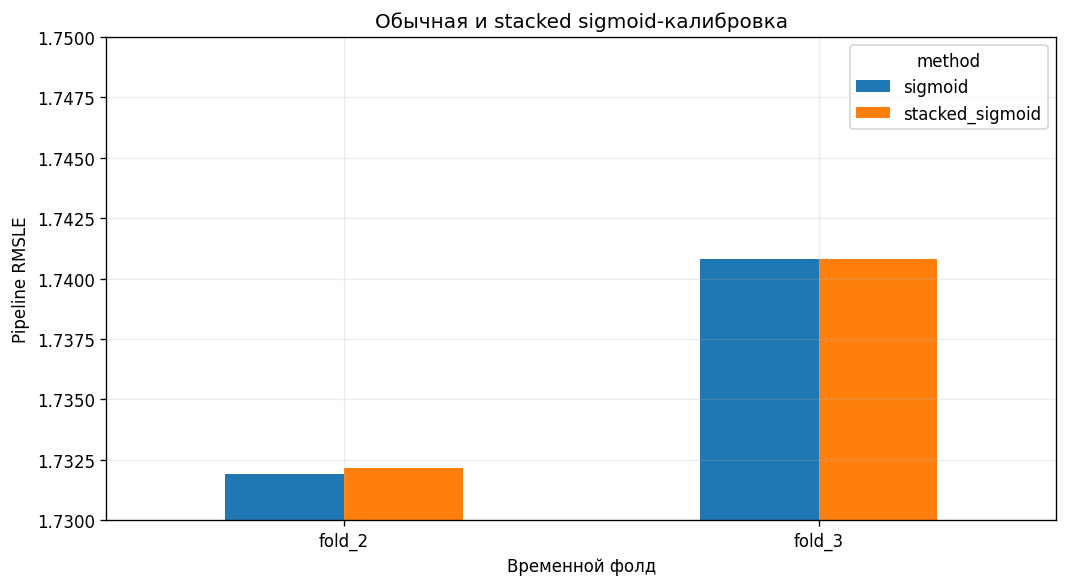

In [57]:
from sklearn.linear_model import LogisticRegression


stacked_walk_forward_probability = np.full(len(X), np.nan, dtype=np.float32)
stacked_walk_forward_calibrators = {}
stacked_calibration_records = []

for fold_spec in CALIBRATION_FOLD_SPECS:
    fold_name = fold_spec["fold"]

    calibration_positions = np.concatenate([
        np.arange(
            TUNING_SPLITS[calibration_fold]["valid"].start,
            TUNING_SPLITS[calibration_fold]["valid"].stop,
        )
        for calibration_fold in fold_spec["calibration_folds"]
    ])

    valid_slice = TUNING_SPLITS[fold_name]["valid"]
    valid_positions = np.arange(valid_slice.start, valid_slice.stop)

    assert calibration_positions.max() < valid_positions.min()

    calibration_raw_probability = tuned_classifier_oof_probability[
        calibration_positions
    ].astype(np.float64)

    calibration_predicted_log = tuned_regressor_oof_predicted_log[
        calibration_positions
    ].astype(np.float64)

    valid_raw_probability = tuned_classifier_oof_probability[
        valid_positions
    ].astype(np.float64)

    valid_predicted_log = tuned_regressor_oof_predicted_log[
        valid_positions
    ].astype(np.float64)

    meta_train = np.column_stack([
        to_logit(calibration_raw_probability).ravel(),
        calibration_predicted_log,
    ])

    meta_valid = np.column_stack([
        to_logit(valid_raw_probability).ravel(),
        valid_predicted_log,
    ])

    calibration_target = np.asarray(
        y_nonzero[calibration_positions],
        dtype=np.int8,
    )

    assert np.isfinite(meta_train).all()
    assert np.isfinite(meta_valid).all()
    assert np.array_equal(np.unique(calibration_target), [0, 1])

    stacked_calibrator = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        max_iter=1_000,
    )

    stacked_calibrator.fit(meta_train, calibration_target)

    stacked_probability = stacked_calibrator.predict_proba(meta_valid)[:, 1]
    stacked_walk_forward_probability[valid_positions] = stacked_probability
    stacked_walk_forward_calibrators[fold_name] = stacked_calibrator

    actual_class = np.asarray(y_nonzero[valid_positions], dtype=np.int8)
    actual_gmv = np.asarray(y_gmv[valid_positions], dtype=np.float64)

    probability_variants = {
        "sigmoid": walk_forward_probability["sigmoid"][valid_positions].astype(
            np.float64
        ),
        "stacked_sigmoid": stacked_probability,
    }

    for method, probability in probability_variants.items():
        classifier_result = classification_metrics(actual_class, probability)

        prediction = combine_two_stage_predictions(
            probability,
            valid_predicted_log,
            scale=1.0,
            gamma=1.0,
        ).prediction

        pipeline_result = pipeline_metrics(actual_gmv, prediction)

        stacked_calibration_records.append({
            "fold": fold_name,
            "method": method,
            **classifier_result,
            "pipeline_rmsle": pipeline_result["rmsle"],
            "pipeline_sum_ratio": pipeline_result["sum_ratio"],
            "pipeline_log_bias": pipeline_result["log_bias"],
        })

    print(
        f"{fold_name}: "
        f"sigmoid={stacked_calibration_records[-2]['pipeline_rmsle']:.6f}, "
        f"stacked={stacked_calibration_records[-1]['pipeline_rmsle']:.6f}"
    )

stacked_valid_positions = np.concatenate([
    np.arange(
        TUNING_SPLITS[fold_spec["fold"]]["valid"].start,
        TUNING_SPLITS[fold_spec["fold"]]["valid"].stop,
    )
    for fold_spec in CALIBRATION_FOLD_SPECS
])

assert np.isfinite(
    stacked_walk_forward_probability[stacked_valid_positions]
).all()

stacked_calibration_results = pd.DataFrame(
    stacked_calibration_records
).set_index(["fold", "method"])

stacked_calibration_summary = (
    stacked_calibration_results
    .groupby("method")
    .mean(numeric_only=True)
)

rmsle_comparison = stacked_calibration_results[
    "pipeline_rmsle"
].unstack("method")

rmsle_comparison["stacked_improvement"] = (
    rmsle_comparison["sigmoid"]
    - rmsle_comparison["stacked_sigmoid"]
)

display(stacked_calibration_results.round(6))
display(stacked_calibration_summary.round(6))
display(rmsle_comparison.round(6))

mean_improvement = rmsle_comparison["stacked_improvement"].mean()

print(f"Mean stacked improvement: {mean_improvement:+.6f}")
print(
    "Stacked calibration:",
    "PASS" if (rmsle_comparison["stacked_improvement"] > 0).all() else "REJECT",
)

ax = rmsle_comparison[
    ["sigmoid", "stacked_sigmoid"]
].plot.bar(figsize=(9, 5), rot=0)

ax.set(
    title="Обычная и stacked sigmoid-калибровка",
    xlabel="Временной фолд",
    ylabel="Pipeline RMSLE",
    ylim=(1.73, 1.75)
)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

Stacked-калибровку отклоняем:
- fold_2: ухудшение 0.000265
- fold_3: улучшение всего 0.000027
- среднее ухудшение: 0.000119
- AP, logloss и Brier также немного хуже.

Значит, прогноз регрессора практически не содержит нового сигнала о факте покупки поверх классификатора. На holdout это переносить не нужно.

Следующий шаг — короткий диагностический spike без обучения. Разложим OOF RMSLE на:
- ошибку на настоящих нулях
- ошибку на покупателях
- вклад разных диапазонов вероятности
- потенциальный выигрыш от oracle-классификатора в каждом диапазоне
- низковероятных покупателей и высоковероятных непокупателей.

По результату выберу направленние изменений:
- если основная исправимая ошибка у покупателей — обучать классификатор с повышенным весом дорогих false negative
- если у непокупателей — усиливать борьбу с false positive
- если даже oracle оставляет большую ошибку — переходить к улучшению/ансамблю регрессора или одностадийной модели.

In [59]:
diagnostic_parts = []

for fold_spec in CALIBRATION_FOLD_SPECS:
    fold_name = fold_spec["fold"]
    valid_slice = TUNING_SPLITS[fold_name]["valid"]

    probability = walk_forward_probability["sigmoid"][valid_slice].astype(np.float64)
    predicted_positive_log = np.maximum(
        tuned_regressor_oof_predicted_log[valid_slice].astype(np.float64),
        0.0,
    )

    actual_gmv = np.asarray(y_gmv[valid_slice], dtype=np.float64)
    actual_class = np.asarray(y_nonzero[valid_slice], dtype=np.int8)
    actual_log = np.log1p(actual_gmv)

    predicted_log = probability * predicted_positive_log
    oracle_predicted_log = actual_class * predicted_positive_log

    diagnostic_parts.append(pd.DataFrame({
        "fold": fold_name,
        "probability": probability,
        "actual_class": actual_class,
        "actual_log": actual_log,
        "predicted_positive_log": predicted_positive_log,
        "squared_error": np.square(predicted_log - actual_log),
        "oracle_squared_error": np.square(oracle_predicted_log - actual_log),
    }))

classification_diagnostics = pd.concat(
    diagnostic_parts,
    ignore_index=True,
)

classification_diagnostics["recoverable_error"] = (
    classification_diagnostics["squared_error"]
    - classification_diagnostics["oracle_squared_error"]
)

classification_diagnostics["predicted_class"] = (
    classification_diagnostics["probability"] >= 0.5
).astype(np.int8)

classification_diagnostics["case"] = np.select(
    [
        (classification_diagnostics["actual_class"] == 0)
        & (classification_diagnostics["predicted_class"] == 0),

        (classification_diagnostics["actual_class"] == 0)
        & (classification_diagnostics["predicted_class"] == 1),

        (classification_diagnostics["actual_class"] == 1)
        & (classification_diagnostics["predicted_class"] == 0),

        (classification_diagnostics["actual_class"] == 1)
        & (classification_diagnostics["predicted_class"] == 1),
    ],
    ["TN", "FP", "FN", "TP"],
    default="UNKNOWN",
)

assert not classification_diagnostics["case"].eq("UNKNOWN").any()

classification_diagnostics["probability_bin"] = pd.cut(
    classification_diagnostics["probability"],
    bins=np.linspace(0.0, 1.0, 21),
    include_lowest=True,
)

assert np.isfinite(
    classification_diagnostics[
        [
            "probability",
            "actual_log",
            "predicted_positive_log",
            "squared_error",
            "oracle_squared_error",
        ]
    ].to_numpy()
).all()

assert (
    classification_diagnostics["oracle_squared_error"].sum()
    < classification_diagnostics["squared_error"].sum()
)

fold_diagnostic_records = []

for fold_name, fold_data in classification_diagnostics.groupby("fold"):
    current_rmsle = np.sqrt(fold_data["squared_error"].mean())
    oracle_rmsle = np.sqrt(fold_data["oracle_squared_error"].mean())

    fold_diagnostic_records.append({
        "fold": fold_name,
        "rows": len(fold_data),
        "current_rmsle": current_rmsle,
        "oracle_classifier_rmsle": oracle_rmsle,
        "potential_improvement": current_rmsle - oracle_rmsle,
        "recoverable_error_share": (
            fold_data["recoverable_error"].sum()
            / fold_data["squared_error"].sum()
        ),
    })

fold_diagnostics = pd.DataFrame(
    fold_diagnostic_records
).set_index("fold")

display(fold_diagnostics.round(6))

,rows,current_rmsle,oracle_classifier_rmsle,potential_improvement,recoverable_error_share
fold,,,,,
fold_2,244983,1.731902,0.838102,0.893799,0.765821
fold_3,250000,1.740817,0.843560,0.897257,0.765185


In [65]:
class_diagnostics = (
    classification_diagnostics
    .groupby(["fold", "actual_class"])
    .agg(
        rows=("actual_class", "size"),
        probability_mean=("probability", "mean"),
        actual_log_mean=("actual_log", "mean"),
        squared_error_sum=("squared_error", "sum"),
        oracle_error_sum=("oracle_squared_error", "sum"),
        recoverable_error_sum=("recoverable_error", "sum"),
    )
)

fold_total_error = (
    classification_diagnostics
    .groupby("fold")["squared_error"]
    .sum()
)

class_diagnostics["rmse_inside_class"] = np.sqrt(
    class_diagnostics["squared_error_sum"]
    / class_diagnostics["rows"]
)

class_diagnostics["current_error_share"] = (
    class_diagnostics["squared_error_sum"]
    / class_diagnostics.index.get_level_values("fold").map(fold_total_error)
)

class_diagnostics["recoverable_error_share"] = (
    class_diagnostics["recoverable_error_sum"]
    / class_diagnostics.index.get_level_values("fold").map(fold_total_error)
)

display(class_diagnostics.round(6))

rows  probability_mean  actual_log_mean  \
fold   actual_class                                              
fold_2 0             105481          0.346342         0.000000   
       1             139502          0.721472         4.300624   
fold_3 0             109230          0.382994         0.000000   
       1             140770          0.744280         4.292543   

                     squared_error_sum  oracle_error_sum  \
fold   actual_class                                        
fold_2 0                 290332.611524          0.000000   
       1                 444489.718371     172079.897691   
fold_3 0                 355632.812456          0.000000   
       1                 401978.529945     177898.558063   

                     recoverable_error_sum  rmse_inside_class  \
fold   actual_class                                             
fold_2 0                     290332.611524           1.659055   
       1                     272409.820680           1.785010   
fold_3 0                     355632.812456           1.804388   
       1                     224079.971882           1.689843   

                     current_error_share  recoverable_error_share  
fold   actual_class                                                
fold_2 0                        0.395106                 0.395106  
       1                        0.604894                 0.370715  
fold_3 0                        0.469413                 0.469413  
       1                        0.530587                 0.295772

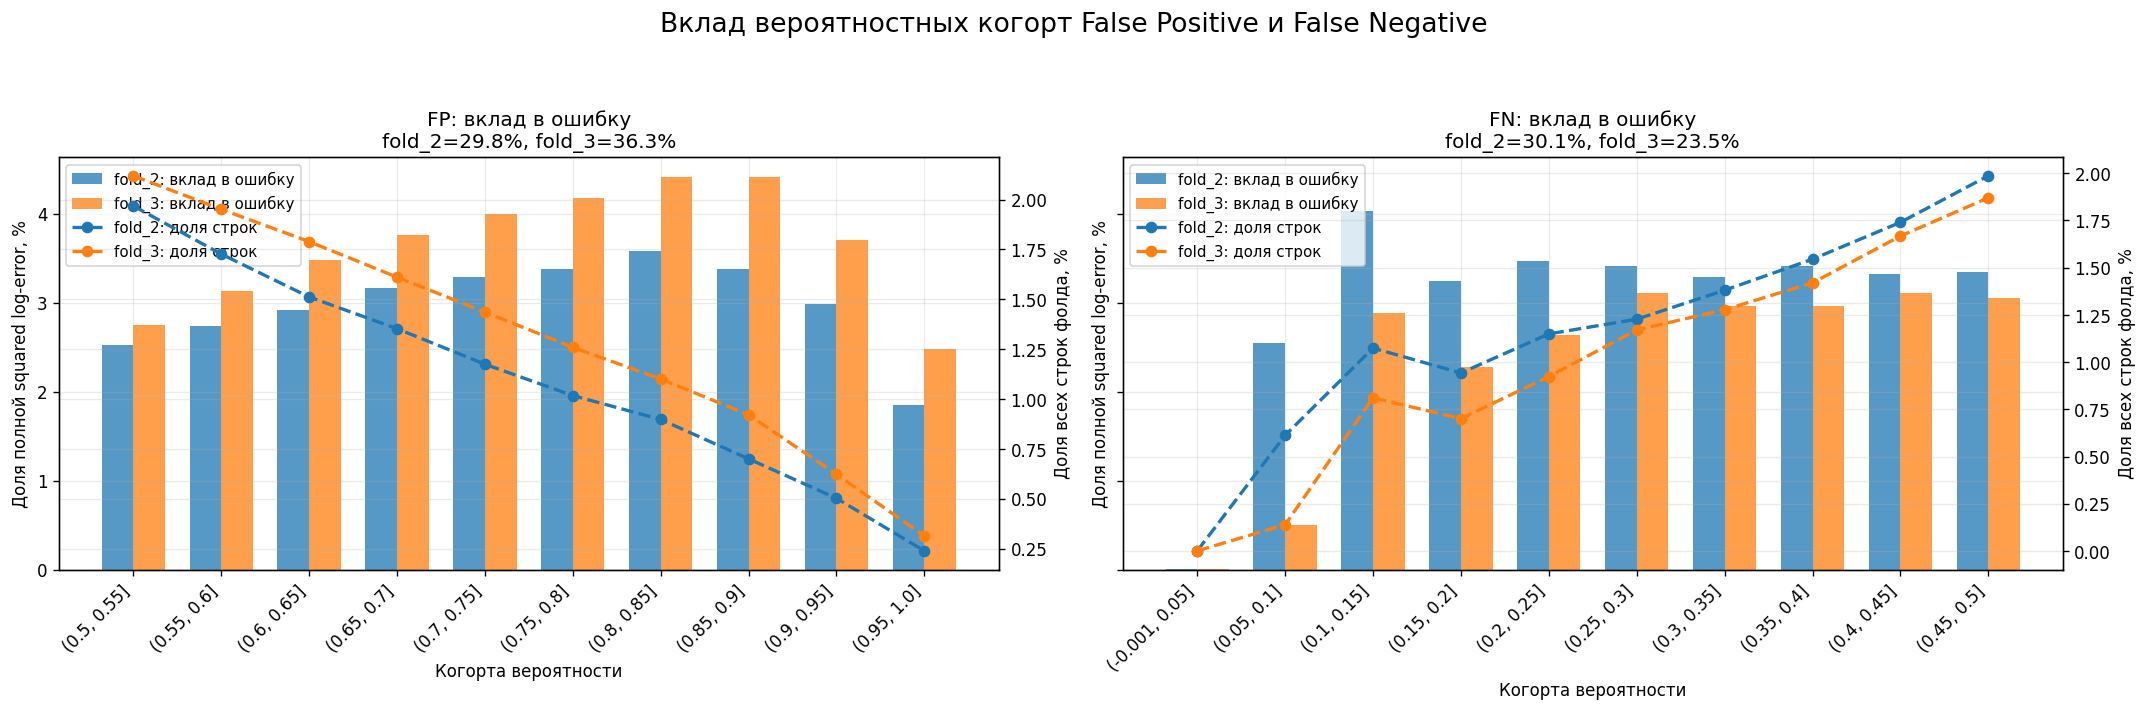

In [67]:
fold_total_error = classification_diagnostics.groupby("fold")[
    "squared_error"
].sum()

fold_total_rows = classification_diagnostics.groupby("fold").size()

case_probability_contribution = (
    classification_diagnostics
    .loc[classification_diagnostics["case"].isin(["FP", "FN"])]
    .groupby(
        ["case", "fold", "probability_bin"],
        observed=True,
    )
    .agg(
        rows=("case", "size"),
        squared_error_sum=("squared_error", "sum"),
        probability_mean=("probability", "mean"),
    )
    .reset_index()
)

case_probability_contribution["error_share"] = (
    case_probability_contribution["squared_error_sum"]
    / case_probability_contribution["fold"].map(fold_total_error)
)

case_probability_contribution["row_share"] = (
    case_probability_contribution["rows"]
    / case_probability_contribution["fold"].map(fold_total_rows)
)

fold_names = ["fold_2", "fold_3"]
fold_colors = {
    "fold_2": "#1f77b4",
    "fold_3": "#ff7f0e",
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(18, 6),
    sharey=True,
)

for axis, case in zip(axes, ["FP", "FN"]):
    case_data = case_probability_contribution.query(
        "case == @case"
    ).copy()

    bins = sorted(
        case_data["probability_bin"].unique(),
        key=lambda interval: interval.left,
    )

    x = np.arange(len(bins))
    width = 0.36
    row_axis = axis.twinx()

    for fold_number, fold_name in enumerate(fold_names):
        fold_data = (
            case_data
            .query("fold == @fold_name")
            .set_index("probability_bin")
            .reindex(bins)
            .fillna(0.0)
        )

        offset = (fold_number - 0.5) * width

        axis.bar(
            x + offset,
            fold_data["error_share"] * 100,
            width=width,
            color=fold_colors[fold_name],
            alpha=0.75,
            label=f"{fold_name}: вклад в ошибку",
        )

        row_axis.plot(
            x,
            fold_data["row_share"] * 100,
            color=fold_colors[fold_name],
            marker="o",
            linewidth=2,
            linestyle="--",
            label=f"{fold_name}: доля строк",
        )

    case_total = (
        case_data
        .groupby("fold")["error_share"]
        .sum()
        .mul(100)
    )

    axis.set_title(
        f"{case}: вклад в ошибку\n"
        f"fold_2={case_total.get('fold_2', 0):.1f}%, "
        f"fold_3={case_total.get('fold_3', 0):.1f}%"
    )

    axis.set_xticks(x)
    axis.set_xticklabels(
        [str(interval) for interval in bins],
        rotation=45,
        ha="right",
    )

    axis.set_xlabel("Когорта вероятности")
    axis.set_ylabel("Доля полной squared log-error, %")
    row_axis.set_ylabel("Доля всех строк фолда, %")
    axis.grid(axis="y", alpha=0.25)

    handles_1, labels_1 = axis.get_legend_handles_labels()
    handles_2, labels_2 = row_axis.get_legend_handles_labels()

    axis.legend(
        handles_1 + handles_2,
        labels_1 + labels_2,
        loc="upper left",
        fontsize=9,
    )

fig.suptitle(
    "Вклад вероятностных когорт False Positive и False Negative",
    fontsize=16,
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

Главный вывод: ошибка распределена по всему диапазону вероятностей, поэтому один порог или зануление отдельного хвоста не помогут.

- На fold_3 вклад FP вырос с 29.8% до 36.3%, а FN снизился с 30.1% до 23.5%. Модель стала чаще склоняться к покупке — меньше пропускает покупателей, но сильнее ошибается на непокупателях.
- Суммарный вклад FP + FN почти не изменился: около 60% на обоих фолдах. Ошибка не исчезла, а перераспределилась из FN в FP.
- У FP доля строк падает с ростом вероятности, но вклад в ошибку растёт. Значит, высокоуверенные FP (p≈0.75–0.95) редкие, но особенно дорогие: классификатор уверен в покупке, а регрессор дополнительно прогнозирует значительную сумму.
- У FN наиболее опасны низковероятные покупатели. Например, когорты 0.10–0.15 содержат относительно мало строк, но создают около 3–4% всей ошибки каждая.
- FN около порога 0.45–0.50 многочисленнее, но в среднем менее дорогие на одну строку.
- На графике нет одной доминирующей когорты: почти каждый диапазон даёт несколько процентов общей ошибки. До требуемого улучшения не получится добраться локальным исправлением одного диапазона.

Практический смысл:
1. Менять порог 0.5 бесполезно для итоговой модели: soft_log вообще не использует жёсткий порог.
2. Простое уменьшение всех вероятностей сократит FP, но одновременно усилит FN.
3. Нужна немонотонная, признаковая коррекция: отличать настоящих покупателей от непокупателей внутри одинаковой вероятностной когорты.
4. Особый приоритет — высокоуверенные FP на свежем fold_3, поскольку именно их вклад растёт при временном дрейфе.

In [61]:
case_diagnostics = (
    classification_diagnostics
    .groupby(["fold", "case"])
    .agg(
        rows=("case", "size"),
        probability_mean=("probability", "mean"),
        actual_log_mean=("actual_log", "mean"),
        predicted_positive_log_mean=("predicted_positive_log", "mean"),
        squared_error_sum=("squared_error", "sum"),
        recoverable_error_sum=("recoverable_error", "sum"),
    )
)

fold_rows = classification_diagnostics.groupby("fold").size()

case_diagnostics["row_share"] = (
    case_diagnostics["rows"]
    / case_diagnostics.index.get_level_values("fold").map(fold_rows)
)

case_diagnostics["current_error_share"] = (
    case_diagnostics["squared_error_sum"]
    / case_diagnostics.index.get_level_values("fold").map(fold_total_error)
)

case_diagnostics["recoverable_error_share"] = (
    case_diagnostics["recoverable_error_sum"]
    / case_diagnostics.index.get_level_values("fold").map(fold_total_error)
)

display(case_diagnostics.round(6))

rows  probability_mean  actual_log_mean  \
fold   case                                              
fold_2 FN     28564          0.314204         3.631491   
       FP     27174          0.682422         0.000000   
       TN     78307          0.229717         0.000000   
       TP    110938          0.826334         4.472910   
fold_3 FN     24954          0.332389         3.588085   
       FP     32814          0.689125         0.000000   
       TN     76416          0.251538         0.000000   
       TP    115816          0.833027         4.444328   

             predicted_positive_log_mean  squared_error_sum  \
fold   case                                                   
fold_2 FN                       3.641566      220965.764496   
       FP                       3.965806      218977.488451   
       TN                       3.595078       71355.123072   
       TP                       4.446928      223523.953875   
fold_3 FN                       3.660517      178014.060284   
       FP                       4.007711      275050.559898   
       TN                       3.620041       80582.252559   
       TP                       4.503403      223964.469661   

             recoverable_error_sum  row_share  current_error_share  \
fold   case                                                          
fold_2 FN            182525.878780   0.116596             0.300706   
       FP            218977.488451   0.110922             0.298001   
       TN             71355.123072   0.319643             0.097105   
       TP             89883.941901   0.452840             0.304188   
fold_3 FN            144001.810996   0.099816             0.234968   
       FP            275050.559898   0.131256             0.363050   
       TN             80582.252559   0.305664             0.106364   
       TP             80078.160887   0.463264             0.295619   

             recoverable_error_share  
fold   case                           
fold_2 FN                   0.248395  
       FP                   0.298001  
       TN                   0.097105  
       TP                   0.122321  
fold_3 FN                   0.190073  
       FP                   0.363050  
       TN                   0.106364  
       TP                   0.105698

In [62]:
probability_diagnostics = (
    classification_diagnostics
    .groupby("probability_bin", observed=True)
    .agg(
        rows=("actual_class", "size"),
        probability_mean=("probability", "mean"),
        positive_share=("actual_class", "mean"),
        actual_log_mean=("actual_log", "mean"),
        squared_error_sum=("squared_error", "sum"),
        oracle_error_sum=("oracle_squared_error", "sum"),
        recoverable_error_sum=("recoverable_error", "sum"),
    )
)

total_error = classification_diagnostics["squared_error"].sum()

probability_diagnostics["current_error_share"] = (
    probability_diagnostics["squared_error_sum"] / total_error
)

probability_diagnostics["oracle_error_share"] = (
    probability_diagnostics["oracle_error_sum"] / total_error
)

probability_diagnostics["recoverable_error_share"] = (
    probability_diagnostics["recoverable_error_sum"] / total_error
)

display(probability_diagnostics.round(6))

,rows,probability_mean,positive_share,actual_log_mean,squared_error_sum,oracle_error_sum,recoverable_error_sum,current_error_share,oracle_error_share,recoverable_error_share
probability_bin,,,,,,,,,,
"(-0.001, 0.05]",400,0.042360,0.012500,0.038464,58.143539,6.505364,51.638174,0.000039,0.000004,0.000035
"(0.05, 0.1]",19301,0.085016,0.095850,0.342923,24137.968279,2729.508092,21408.460187,0.016174,0.001829,0.014345
"(0.1, 0.15]",37655,0.124457,0.123755,0.439473,58099.075461,6643.611434,51455.464027,0.038929,0.004452,0.034478
"(0.15, 0.2]",23789,0.173759,0.170793,0.609729,48748.396778,5762.026879,42986.369898,0.032664,0.003861,0.028803
"(0.2, 0.25]",23179,0.225538,0.221062,0.784163,57443.812496,6978.016261,50465.796235,0.038490,0.004676,0.033814
"(0.25, 0.3]",22164,0.274687,0.267686,0.965485,64746.615289,8007.471282,56739.144007,0.043383,0.005365,0.038018
"(0.3, 0.35]",20803,0.324749,0.316108,1.130550,66615.378713,8749.978698,57865.400015,0.044635,0.005863,0.038773
"(0.35, 0.4]",20007,0.374909,0.366622,1.332906,71536.434749,9785.871325,61750.563424,0.047933,0.006557,0.041376
"(0.4, 0.45]",20400,0.425228,0.413284,1.509126,77432.612616,11036.258813,66396.353804,0.051883,0.007395,0.044489


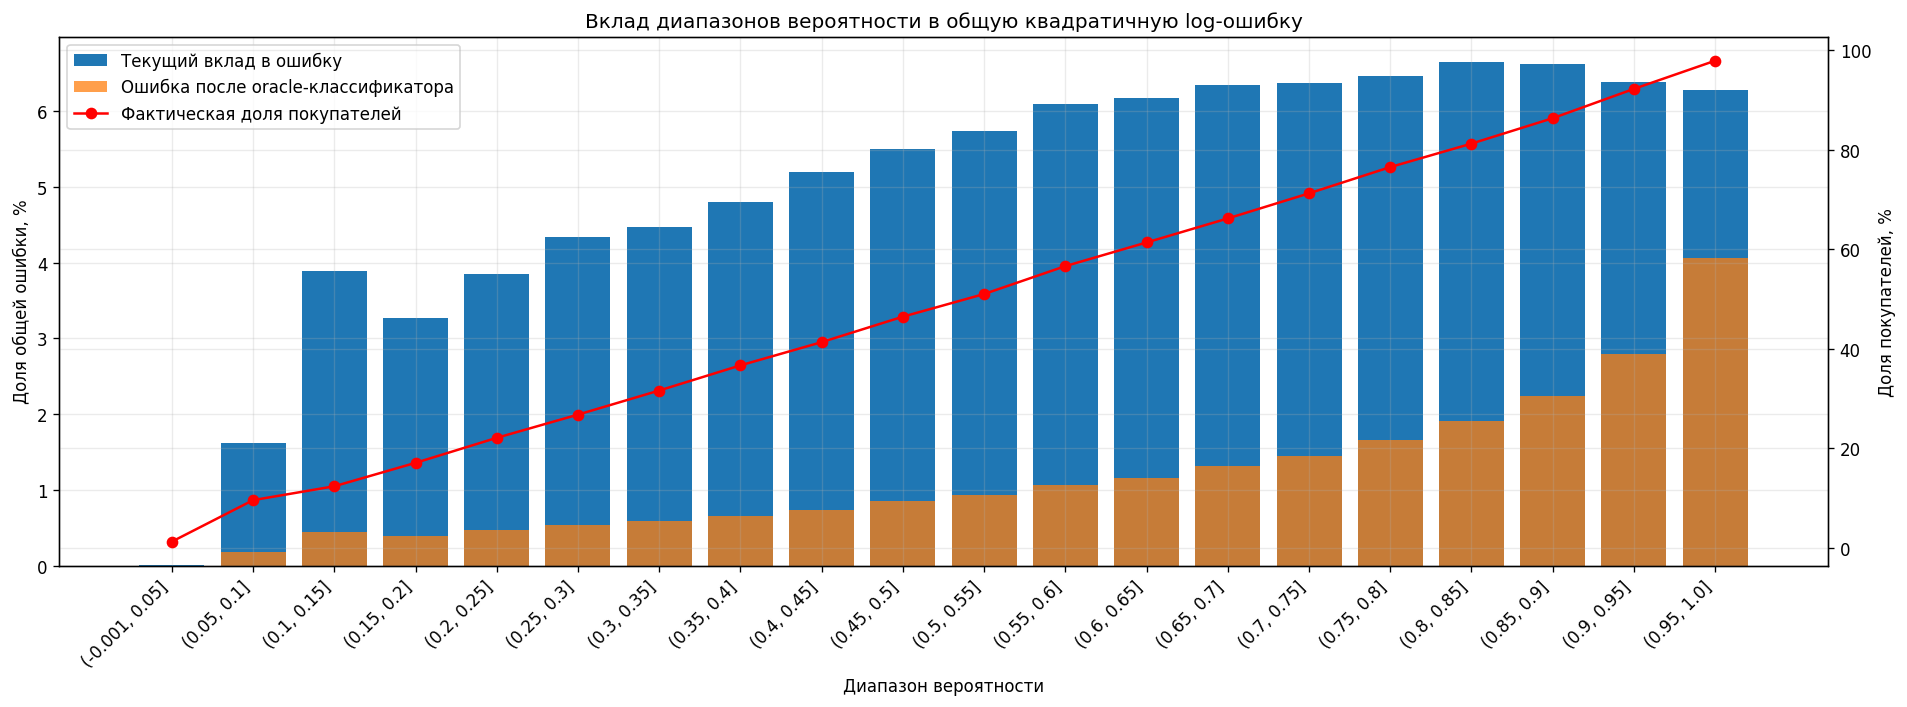

In [63]:
plot_data = probability_diagnostics.reset_index()
x = np.arange(len(plot_data))

fig, axis = plt.subplots(figsize=(16, 6))
axis.bar(
    x,
    plot_data["current_error_share"] * 100,
    label="Текущий вклад в ошибку",
)
axis.bar(
    x,
    plot_data["oracle_error_share"] * 100,
    label="Ошибка после oracle-классификатора",
    alpha=0.75,
)

axis.set(
    title="Вклад диапазонов вероятности в общую квадратичную log-ошибку",
    xlabel="Диапазон вероятности",
    ylabel="Доля общей ошибки, %",
)
axis.set_xticks(x)
axis.set_xticklabels(
    plot_data["probability_bin"].astype(str),
    rotation=45,
    ha="right",
)
axis.grid(axis="y", alpha=0.25)

positive_axis = axis.twinx()
positive_axis.plot(
    x,
    plot_data["positive_share"] * 100,
    color="red",
    marker="o",
    label="Фактическая доля покупателей",
)
positive_axis.set_ylabel("Доля покупателей, %")

lines_1, labels_1 = axis.get_legend_handles_labels()
lines_2, labels_2 = positive_axis.get_legend_handles_labels()
axis.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper left")

plt.tight_layout()
plt.show()

Диагностика подтверждает исходную гипотезу: около 76.5% квадратичной log-ошибки потенциально связано с первой стадией и способом объединения.

Ключевые выводы:
- Oracle-классификатор снижает OOF RMSLE примерно с 1.74 до 0.84.
- На ближайшем к тесту fold_3 главный источник ошибки — false positive: 36.3% всей ошибки.
- Доля ошибки false negative снизилась с 30.1% до 23.5%.
- Даже TN дают около 10% ошибки: soft_log оставляет ненулевой прогноз при p < 0.5.
- Простое зануление не работает, потому что покупатели и непокупатели смешаны во всех диапазонах вероятности.
- Значит, нужен новый способ разделения объектов, а не ещё один порог или калибровка текущей вероятности.

## Эксперимент с блендингом

```
Все строки
    ↓
LightGBMRegressor(target = log1p(GMV))
    ↓
direct_predicted_log

two_stage_predicted_log = calibrated_probability × positive_predicted_log

final_log = α × two_stage_predicted_log
          + (1 − α) × direct_predicted_log
```

Почему это перспективно:
- regression_l2 на log1p(GMV) напрямую оптимизирует RMSLE
- модель одновременно учится выдавать ноль непокупателям и оценивать сумму покупателям
- она может исправлять высокоуверенные false positive, которые сейчас дают наибольшую ошибку
- двухстадийная модель сохраняется, а прямой регрессор добавляет разнообразие
- коэффициент α подберём только на трёх временных OOF-фолдах
- проверим standalone direct-модель и blend
- holdout не трогаем до фиксации α.

Чтобы перейти с лидерборда 1.654654 к 1.6440, нужен выигрыш около 0.010654. Предыдущие постпроцессинги слишком малы, а blend с моделью, обученной непосредственно под RMSLE, имеет заметно больший потенциал.

In [64]:
def direct_rmsle_metric(actual_log, predicted_log):
    predicted_log = np.maximum(np.asarray(predicted_log, dtype=np.float64), 0.0)
    actual_log = np.asarray(actual_log, dtype=np.float64)
    return "direct_rmsle", float(np.sqrt(np.mean(np.square(predicted_log - actual_log)))), False


direct_oof_predicted_log = np.full(len(X), np.nan, dtype=np.float32)
direct_regressor_models = {}
direct_regressor_histories = {}
direct_regressor_records = []

for fold_name, split in TUNING_SPLITS.items():
    started = perf_counter()
    train_slice, valid_slice = split["train"], split["valid"]

    X_train, X_valid = X.iloc[train_slice], X.iloc[valid_slice]
    y_train_log = np.log1p(y_gmv[train_slice])
    y_valid_log = np.log1p(y_gmv[valid_slice])
    y_valid_gmv = y_gmv[valid_slice]

    assert train_slice.stop <= valid_slice.start
    assert np.isfinite(y_train_log).all()
    assert np.isfinite(y_valid_log).all()

    history = {}
    model = lgb.LGBMRegressor(
        objective="regression_l2",
        metric="None",
        n_estimators=MAX_BOOST_ROUNDS,
        **regressor_best_params,
    )

    model.fit(
        X_train,
        y_train_log,
        eval_set=[(X_train, y_train_log), (X_valid, y_valid_log)],
        eval_names=["train", "validation"],
        eval_metric=direct_rmsle_metric,
        callbacks=[
            lgb.early_stopping(
                EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False,
            ),
            lgb.record_evaluation(history),
        ],
    )

    raw_predicted_log = model.predict(
        X_valid,
        num_iteration=model.best_iteration_,
    ).astype(np.float64)

    predicted_log = np.maximum(raw_predicted_log, 0.0)
    prediction = np.expm1(predicted_log)
    result = pipeline_metrics(y_valid_gmv, prediction)

    direct_oof_predicted_log[valid_slice] = predicted_log.astype(np.float32)
    direct_regressor_models[fold_name] = model
    direct_regressor_histories[fold_name] = history

    direct_regressor_records.append({
        "fold": fold_name,
        "best_iteration": model.best_iteration_,
        "duration_seconds": perf_counter() - started,
        "rmsle": result["rmsle"],
        "sum_ratio": result["sum_ratio"],
        "log_bias": result["log_bias"],
        "negative_raw_log_share": np.mean(raw_predicted_log < 0),
    })

    print(
        f"{fold_name}: RMSLE={result['rmsle']:.6f}, "
        f"iteration={model.best_iteration_}, "
        f"time={direct_regressor_records[-1]['duration_seconds']:.1f}s"
    )

direct_regressor_results = pd.DataFrame(
    direct_regressor_records
).set_index("fold")

expected_oof_mask = np.zeros(len(X), dtype=bool)

for split in TUNING_SPLITS.values():
    expected_oof_mask[split["valid"]] = True

assert np.isfinite(direct_oof_predicted_log[expected_oof_mask]).all()
assert not np.isfinite(direct_oof_predicted_log[~expected_oof_mask]).any()

display(direct_regressor_results.round(6))
print(
    "Direct mean RMSLE:",
    f"{direct_regressor_results['rmsle'].mean():.6f}",
)

fold_1: RMSLE=1.714945, iteration=751, time=133.1s
fold_2: RMSLE=1.732343, iteration=1394, time=326.8s
fold_3: RMSLE=1.746292, iteration=1489, time=508.2s


,best_iteration,duration_seconds,rmsle,sum_ratio,log_bias,negative_raw_log_share
fold,,,,,,
fold_1,751,133.081441,1.714945,0.453316,0.072237,0.000170
fold_2,1394,326.786231,1.732343,0.432717,0.006271,0.000273
fold_3,1489,508.167303,1.746292,0.488265,0.171694,0.000160


Direct mean RMSLE: 1.731193


Direct mean RMSLE: 1.739317
Two-stage mean RMSLE: 1.736359
Best alpha: 1.00
Best blend RMSLE: 1.736359
Improvement over two-stage: +0.000000


,mean_rmsle,worst_rmsle,rmsle_range,mean_sum_ratio,mean_absolute_log_bias,rmsle_fold_2,rmsle_fold_3
alpha,,,,,,,
1.00,1.736359,1.740817,0.008916,0.444784,0.086197,1.731902,1.740817
0.99,1.736360,1.740844,0.008967,0.444917,0.086162,1.731877,1.740844
0.98,1.736361,1.740870,0.009018,0.445051,0.086128,1.731852,1.740870
0.97,1.736363,1.740898,0.009069,0.445185,0.086093,1.731828,1.740898
0.96,1.736365,1.740926,0.009120,0.445320,0.086058,1.731805,1.740926
0.95,1.736368,1.740954,0.009171,0.445455,0.086023,1.731783,1.740954
0.94,1.736372,1.740983,0.009222,0.445591,0.085988,1.731761,1.740983
0.93,1.736376,1.741013,0.009273,0.445727,0.085953,1.731739,1.741013
0.92,1.736381,1.741043,0.009324,0.445863,0.085918,1.731718,1.741043


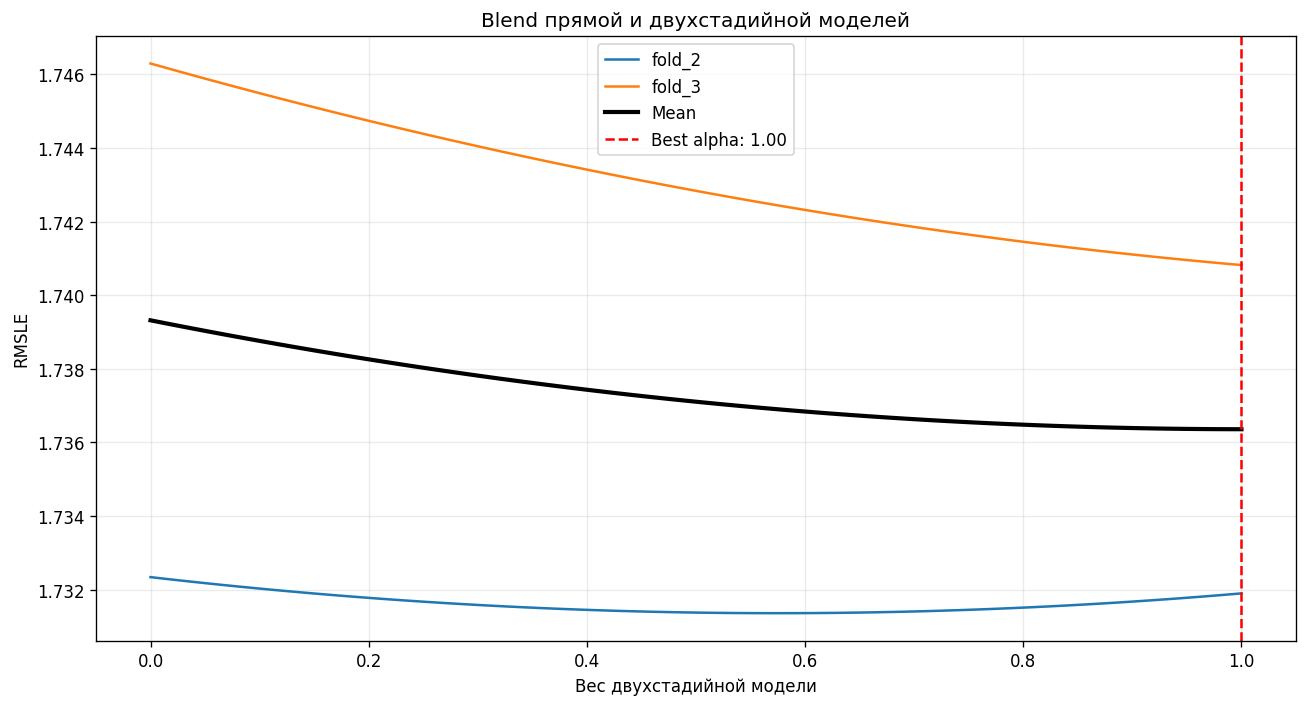

In [66]:
BLEND_ALPHAS = np.linspace(0.0, 1.0, 101)
blend_records = []

for fold_spec in CALIBRATION_FOLD_SPECS:
    fold_name = fold_spec["fold"]
    valid_slice = TUNING_SPLITS[fold_name]["valid"]

    actual_gmv = np.asarray(y_gmv[valid_slice], dtype=np.float64)
    probability = walk_forward_probability["sigmoid"][valid_slice].astype(np.float64)

    positive_log = np.maximum(
        tuned_regressor_oof_predicted_log[valid_slice].astype(np.float64),
        0.0,
    )

    two_stage_log = probability * positive_log
    direct_log = direct_oof_predicted_log[valid_slice].astype(np.float64)

    assert np.isfinite(two_stage_log).all()
    assert np.isfinite(direct_log).all()

    for alpha in BLEND_ALPHAS:
        blended_log = alpha * two_stage_log + (1.0 - alpha) * direct_log
        result = pipeline_metrics(actual_gmv, np.expm1(blended_log))

        blend_records.append({
            "fold": fold_name,
            "alpha": alpha,
            "rmsle": result["rmsle"],
            "sum_ratio": result["sum_ratio"],
            "log_bias": result["log_bias"],
            "absolute_log_bias": abs(result["log_bias"]),
        })

blend_results = pd.DataFrame(blend_records)

blend_summary = blend_results.groupby("alpha").agg(
    mean_rmsle=("rmsle", "mean"),
    worst_rmsle=("rmsle", "max"),
    rmsle_range=("rmsle", lambda values: values.max() - values.min()),
    mean_sum_ratio=("sum_ratio", "mean"),
    mean_absolute_log_bias=("absolute_log_bias", "mean"),
)

fold_rmsle = blend_results.pivot(
    index="alpha",
    columns="fold",
    values="rmsle",
).add_prefix("rmsle_")

blend_summary = blend_summary.join(fold_rmsle)
best_blend_alpha = blend_summary["mean_rmsle"].idxmin()
best_blend_result = blend_summary.loc[best_blend_alpha]

direct_mean_rmsle = blend_summary.loc[0.0, "mean_rmsle"]
two_stage_mean_rmsle = blend_summary.loc[1.0, "mean_rmsle"]

print(f"Direct mean RMSLE: {direct_mean_rmsle:.6f}")
print(f"Two-stage mean RMSLE: {two_stage_mean_rmsle:.6f}")
print(f"Best alpha: {best_blend_alpha:.2f}")
print(f"Best blend RMSLE: {best_blend_result['mean_rmsle']:.6f}")
print(f"Improvement over two-stage: {two_stage_mean_rmsle - best_blend_result['mean_rmsle']:+.6f}")

display(blend_summary.sort_values("mean_rmsle").head(15).round(6))

fig, axis = plt.subplots(figsize=(11, 6))

for fold_name, fold_data in blend_results.groupby("fold"):
    axis.plot(fold_data["alpha"], fold_data["rmsle"], label=fold_name)

axis.plot(
    blend_summary.index,
    blend_summary["mean_rmsle"],
    color="black",
    linewidth=2.5,
    label="Mean",
)

axis.axvline(
    best_blend_alpha,
    color="red",
    linestyle="--",
    label=f"Best alpha: {best_blend_alpha:.2f}",
)

axis.set(
    title="Blend прямой и двухстадийной моделей",
    xlabel="Вес двухстадийной модели",
    ylabel="RMSLE",
)
axis.legend()
axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

Прямую модель и blend отклоняем: на fold_3 любое добавление direct-прогноза ухудшает результат, а общий оптимум остаётся alpha=1. Это показывает, что проблема не решается ещё одним регрессором на тех же признаках.

Нелинейный pipeline-aware gate вместо обычной вероятности.
Сейчас итоговый log-прогноз:
```
classifier_probability × positive_predicted_log
```

Предлагаю обучить небольшой LightGBM gate непосредственно под квадратичную log-ошибку:
```
m = positive_predicted_log
gate_target = log1p(actual_gmv) / m
sample_weight = m ** 2
```
Тогда функция потерь:
```
weight × (gate − target)²
=
(m × gate − log1p(actual_gmv))²
```
То есть она математически совпадает с ошибкой, из которой получается RMSLE.
Gate получит:
- исходные 91 признак
- raw probability классификатора
- predicted log положительного регрессора.

Обучение будет честным и быстрым:
- для fold_2 gate обучается на OOF fold_1
- для fold_3 — на OOF fold_1 + fold_2
- LightGBM будет небольшим и с early stopping по pipeline RMSLE
- gate не ограничиваем единицей: значение выше 1 сможет исправлять недооценённых покупателей
- отрицательный итоговый log обрезаем до нуля
- сравниваем с текущим sigmoid + soft_log
- holdout пока не используем.

Это развитие неудачной stacked-калибровки: LogisticRegression могла сделать только линейную поправку, а новый gate сможет находить нелинейные сегменты высокоуверенных false positive.

In [68]:
GATE_EPSILON = 1e-3

PIPELINE_GATE_PARAMS = {
    **BASE_LGBM_PARAMS,
    "learning_rate": 0.03,
    "max_depth": 5,
    "num_leaves": 31,
    "min_child_samples": 500,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.9,
    "reg_alpha": 1.0,
    "reg_lambda": 5.0,
}


def make_pipeline_gate_metric(base_log, actual_log):
    base_log = np.asarray(base_log, dtype=np.float64)
    actual_log = np.asarray(actual_log, dtype=np.float64)

    def pipeline_gate_metric(_, predicted_gate):
        predicted_log = np.maximum(
            np.asarray(predicted_gate, dtype=np.float64) * base_log,
            0.0,
        )
        value = np.sqrt(np.mean(np.square(predicted_log - actual_log)))
        return "pipeline_gate_rmsle", float(value), False

    return pipeline_gate_metric


pipeline_gate_oof_factor = np.full(len(X), np.nan, dtype=np.float32)
pipeline_gate_oof_predicted_log = np.full(len(X), np.nan, dtype=np.float32)
pipeline_gate_models = {}
pipeline_gate_histories = {}
pipeline_gate_records = []

for fold_spec in CALIBRATION_FOLD_SPECS:
    fold_name = fold_spec["fold"]
    started = perf_counter()

    train_positions = np.concatenate([
        np.arange(
            TUNING_SPLITS[train_fold]["valid"].start,
            TUNING_SPLITS[train_fold]["valid"].stop,
        )
        for train_fold in fold_spec["calibration_folds"]
    ])

    valid_slice = TUNING_SPLITS[fold_name]["valid"]
    valid_positions = np.arange(valid_slice.start, valid_slice.stop)

    assert train_positions.max() < valid_positions.min()

    train_base_log = np.maximum(
        tuned_regressor_oof_predicted_log[train_positions].astype(np.float64),
        GATE_EPSILON,
    )

    valid_base_log = np.maximum(
        tuned_regressor_oof_predicted_log[valid_positions].astype(np.float64),
        GATE_EPSILON,
    )

    train_actual_log = np.log1p(
        np.asarray(y_gmv[train_positions], dtype=np.float64)
    )

    valid_actual_log = np.log1p(
        np.asarray(y_gmv[valid_positions], dtype=np.float64)
    )

    gate_train_target = train_actual_log / train_base_log
    gate_valid_target = valid_actual_log / valid_base_log
    gate_train_weight = np.square(train_base_log)

    # Проверяем математическое соответствие gate-loss и squared log-error.
    probe_gate = 0.37

    assert np.allclose(
        gate_train_weight * np.square(probe_gate - gate_train_target),
        np.square(probe_gate * train_base_log - train_actual_log),
    )

    X_gate_train = X.iloc[train_positions].copy()
    X_gate_valid = X.iloc[valid_positions].copy()

    X_gate_train["gate_raw_probability"] = (
        tuned_classifier_oof_probability[train_positions]
    )

    X_gate_valid["gate_raw_probability"] = (
        tuned_classifier_oof_probability[valid_positions]
    )

    X_gate_train["gate_positive_predicted_log"] = train_base_log
    X_gate_valid["gate_positive_predicted_log"] = valid_base_log

    assert np.isfinite(gate_train_target).all()
    assert np.isfinite(gate_valid_target).all()
    assert np.isfinite(gate_train_weight).all()
    assert (gate_train_weight > 0).all()

    history = {}

    gate_model = lgb.LGBMRegressor(
        objective="regression_l2",
        metric="None",
        n_estimators=MAX_BOOST_ROUNDS,
        **PIPELINE_GATE_PARAMS,
    )

    gate_model.fit(
        X_gate_train,
        gate_train_target,
        sample_weight=gate_train_weight,
        eval_set=[(X_gate_valid, gate_valid_target)],
        eval_names=["validation"],
        eval_metric=make_pipeline_gate_metric(
            valid_base_log,
            valid_actual_log,
        ),
        callbacks=[
            lgb.early_stopping(
                EARLY_STOPPING_ROUNDS,
                first_metric_only=True,
                verbose=False,
            ),
            lgb.record_evaluation(history),
        ],
    )

    predicted_gate = gate_model.predict(
        X_gate_valid,
        num_iteration=gate_model.best_iteration_,
    ).astype(np.float64)

    gate_predicted_log = np.maximum(
        predicted_gate * valid_base_log,
        0.0,
    )

    current_probability = walk_forward_probability[
        "sigmoid"
    ][valid_positions].astype(np.float64)

    current_predicted_log = (
        current_probability
        * np.maximum(
            tuned_regressor_oof_predicted_log[
                valid_positions
            ].astype(np.float64),
            0.0,
        )
    )

    actual_gmv = np.asarray(
        y_gmv[valid_positions],
        dtype=np.float64,
    )

    current_result = pipeline_metrics(
        actual_gmv,
        np.expm1(current_predicted_log),
    )

    gate_result = pipeline_metrics(
        actual_gmv,
        np.expm1(gate_predicted_log),
    )

    pipeline_gate_oof_factor[valid_positions] = predicted_gate.astype(
        np.float32
    )

    pipeline_gate_oof_predicted_log[valid_positions] = (
        gate_predicted_log.astype(np.float32)
    )

    pipeline_gate_models[fold_name] = gate_model
    pipeline_gate_histories[fold_name] = history

    pipeline_gate_records.append({
        "fold": fold_name,
        "train_rows": len(train_positions),
        "valid_rows": len(valid_positions),
        "best_iteration": gate_model.best_iteration_,
        "duration_seconds": perf_counter() - started,
        "current_rmsle": current_result["rmsle"],
        "gate_rmsle": gate_result["rmsle"],
        "improvement": current_result["rmsle"] - gate_result["rmsle"],
        "current_sum_ratio": current_result["sum_ratio"],
        "gate_sum_ratio": gate_result["sum_ratio"],
        "current_log_bias": current_result["log_bias"],
        "gate_log_bias": gate_result["log_bias"],
        "gate_mean": predicted_gate.mean(),
        "gate_p01": np.quantile(predicted_gate, 0.01),
        "gate_p99": np.quantile(predicted_gate, 0.99),
        "negative_gate_share": np.mean(predicted_gate < 0),
        "above_one_gate_share": np.mean(predicted_gate > 1),
    })

    print(
        f"{fold_name}: current={current_result['rmsle']:.6f}, "
        f"gate={gate_result['rmsle']:.6f}, "
        f"improvement={current_result['rmsle'] - gate_result['rmsle']:+.6f}, "
        f"iteration={gate_model.best_iteration_}, "
        f"time={pipeline_gate_records[-1]['duration_seconds']:.1f}s"
    )

pipeline_gate_results = pd.DataFrame(
    pipeline_gate_records
).set_index("fold")

expected_gate_positions = np.concatenate([
    np.arange(
        TUNING_SPLITS[fold_spec["fold"]]["valid"].start,
        TUNING_SPLITS[fold_spec["fold"]]["valid"].stop,
    )
    for fold_spec in CALIBRATION_FOLD_SPECS
])

assert np.isfinite(
    pipeline_gate_oof_predicted_log[expected_gate_positions]
).all()

display(pipeline_gate_results.round(6))

mean_current_rmsle = pipeline_gate_results["current_rmsle"].mean()
mean_gate_rmsle = pipeline_gate_results["gate_rmsle"].mean()
mean_gate_improvement = pipeline_gate_results["improvement"].mean()

print(f"Current mean RMSLE: {mean_current_rmsle:.6f}")
print(f"Gate mean RMSLE: {mean_gate_rmsle:.6f}")
print(f"Mean improvement: {mean_gate_improvement:+.6f}")
print(
    "Pipeline-aware gate:",
    "PASS"
    if (pipeline_gate_results["improvement"] > 0).all()
    else "REJECT",
)

fold_2: current=1.731902, gate=1.732982, improvement=-0.001080, iteration=165, time=10.4s
fold_3: current=1.740817, gate=1.741815, improvement=-0.000998, iteration=122, time=16.8s


,train_rows,valid_rows,best_iteration,duration_seconds,current_rmsle,gate_rmsle,improvement,current_sum_ratio,gate_sum_ratio,current_log_bias,gate_log_bias,gate_mean,gate_p01,gate_p99,negative_gate_share,above_one_gate_share
fold,,,,,,,,,,,,,,,,
fold_2,240700,244983,165,10.364632,1.731902,1.732982,-0.001080,0.415215,0.389025,-0.047779,-0.076765,0.553471,0.080004,0.987303,0.0,0.000853
fold_3,485683,250000,122,16.802544,1.740817,1.741815,-0.000998,0.474353,0.469292,0.124616,0.134711,0.589147,0.096582,0.993850,0.0,0.000100


Current mean RMSLE: 1.736359
Gate mean RMSLE: 1.737399
Mean improvement: -0.001039
Pipeline-aware gate: REJECT


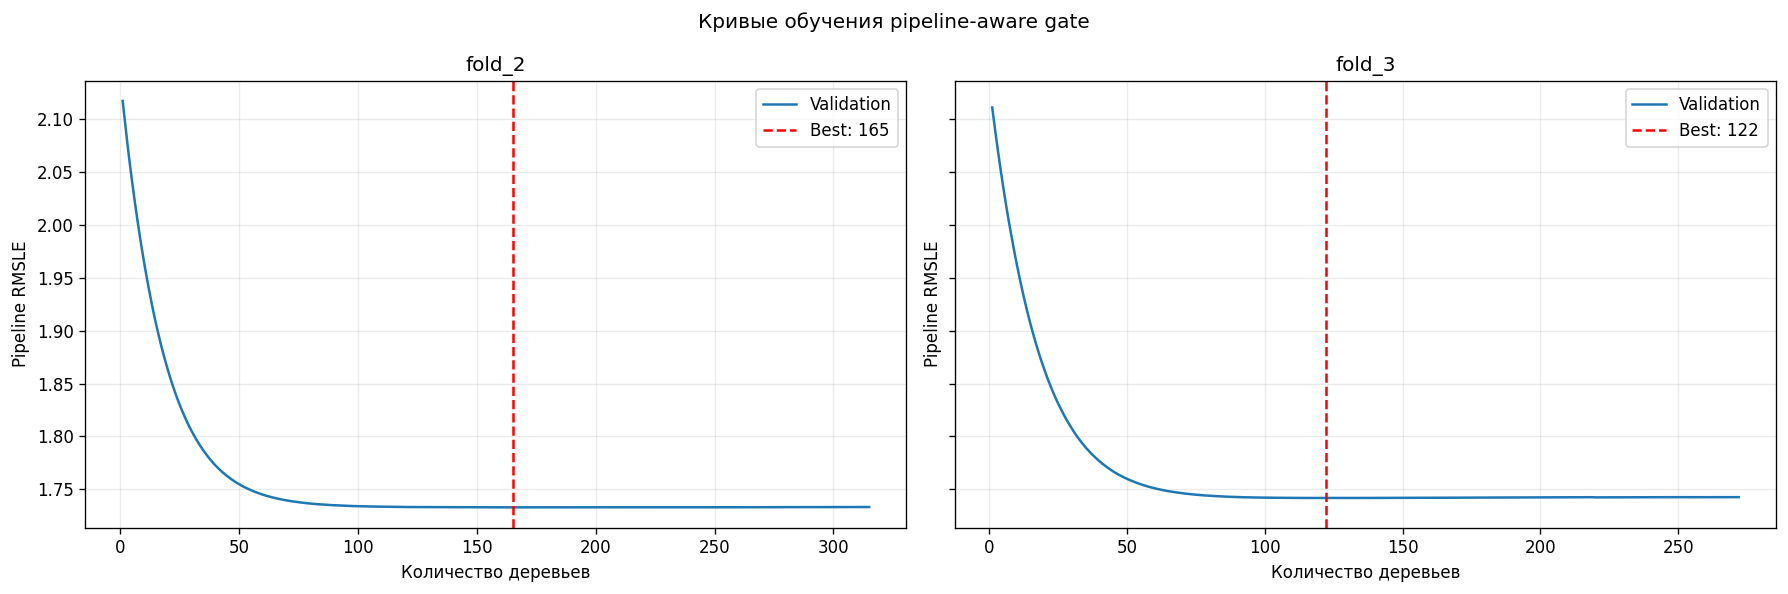

In [69]:
fig, axes = plt.subplots(
    1,
    len(pipeline_gate_histories),
    figsize=(15, 5),
    sharey=True,
)

for axis, (fold_name, history) in zip(
    axes,
    pipeline_gate_histories.items(),
):
    values = history["validation"]["pipeline_gate_rmsle"]
    best_iteration = pipeline_gate_models[fold_name].best_iteration_

    axis.plot(
        np.arange(1, len(values) + 1),
        values,
        label="Validation",
    )

    axis.axvline(
        best_iteration,
        color="red",
        linestyle="--",
        label=f"Best: {best_iteration}",
    )

    axis.set(
        title=fold_name,
        xlabel="Количество деревьев",
        ylabel="Pipeline RMSLE",
    )
    axis.grid(alpha=0.25)
    axis.legend()

fig.suptitle("Кривые обучения pipeline-aware gate")
plt.tight_layout()
plt.show()

Gate отклоняем окончательно:
- ухудшение стабильное на обоих фолдах: около 0.001
- кривые выходят на плато, поэтому изменение числа деревьев не поможет
- gate обучался только на 240–485 тыс. прошлых OOF-строк, тогда как основной классификатор видел 1.6–1.8 млн
- на fold_2 gate заметно усилил недопрогноз: sum_ratio 0.415 → 0.389.

Простые способы объединения исчерпаны: зануление, линейный stacking, direct blend и нелинейный gate не дали результата -> надо менять сам классификатор

### Эксперимент: recency-weighted классификатор

Проверяем, помогает ли повышенный вес свежих данных бороться с временным дрейфом классификатора. Диагностика показала, что на последнем временном фолде ошибка перераспределяется от False Negative к False Positive: модель чаще переоценивает вероятность покупки.

Для обучающих строк применяется экспоненциальное затухание веса:

$$
w = 2^{-\text{age\_months} / \text{half\_life}}
$$

Тестируются периоды полураспада `2`, `4` и `8` месяцев. Чем меньше `half_life`, тем сильнее модель ориентируется на последние периоды.

Для каждого варианта:

1. классификатор обучается с временными весами на `fold_2` и `fold_3`;
2. параметры LightGBM остаются неизменными;
3. sigmoid-калибратор обучается на OOF-прогнозах `fold_2`;
4. качество оценивается на более позднем `fold_3`;
5. positive-регрессор и способ объединения `soft_log` остаются фиксированными.

Сравниваем pipeline RMSLE, классификационные метрики, количество FP/FN и среднюю вероятность. Цель — выяснить, улучшает ли адаптация к свежим данным итоговое качество, а не просто переносит ошибку между FP и FN.

In [70]:
RECENCY_HALF_LIVES = (2.0, 4.0, 8.0)
RECENCY_FOLDS = ("fold_2", "fold_3")


def make_recency_weights(dates, half_life_months):
    dates = pd.to_datetime(dates)
    age_months = (dates.max() - dates).dt.days.to_numpy() / 30.4375
    raw_weights = np.power(2.0, -age_months / half_life_months)

    assert np.isclose(raw_weights[age_months == 0], 1.0).all()
    assert (raw_weights > 0).all()
    assert raw_weights.max() <= 1.0

    return raw_weights / raw_weights.mean()


recency_models = {}
recency_histories = {}
recency_raw_probability = {}
recency_training_records = []

for half_life in RECENCY_HALF_LIVES:
    for fold_name in RECENCY_FOLDS:
        started = perf_counter()
        split = TUNING_SPLITS[fold_name]
        train_slice, valid_slice = split["train"], split["valid"]

        X_train, X_valid = X.iloc[train_slice], X.iloc[valid_slice]
        y_train = y_nonzero[train_slice]
        y_valid = y_nonzero[valid_slice]

        train_weights = make_recency_weights(
            cutoff_dates.iloc[train_slice],
            half_life,
        )

        assert train_slice.stop <= valid_slice.start
        assert len(train_weights) == len(X_train)
        assert np.isclose(train_weights.mean(), 1.0)

        history = {}

        classifier = lgb.LGBMClassifier(
            objective="binary",
            metric="None",
            n_estimators=MAX_BOOST_ROUNDS,
            **classifier_best_params,
        )

        classifier.fit(
            X_train,
            y_train,
            sample_weight=train_weights,
            eval_set=[(X_valid, y_valid)],
            eval_names=["validation"],
            eval_metric="binary_logloss",
            callbacks=[
                lgb.early_stopping(
                    EARLY_STOPPING_ROUNDS,
                    first_metric_only=True,
                    verbose=False,
                ),
                lgb.record_evaluation(history),
            ],
        )

        raw_probability = classifier.predict_proba(
            X_valid,
            num_iteration=classifier.best_iteration_,
        )[:, 1]

        effective_rows = (
            np.square(train_weights.sum())
            / np.square(train_weights).sum()
        )

        key = (half_life, fold_name)
        recency_models[key] = classifier
        recency_histories[key] = history
        recency_raw_probability[key] = raw_probability.astype(np.float32)

        recency_training_records.append({
            "half_life": half_life,
            "fold": fold_name,
            "train_rows": len(X_train),
            "effective_rows": effective_rows,
            "weight_min": train_weights.min(),
            "weight_max": train_weights.max(),
            "best_iteration": classifier.best_iteration_,
            "duration_seconds": perf_counter() - started,
            "raw_logloss": classification_metrics(
                y_valid,
                raw_probability,
            )["logloss"],
        })

        print(
            f"half_life={half_life:.0f}m | {fold_name}: "
            f"logloss={recency_training_records[-1]['raw_logloss']:.6f}, "
            f"iteration={classifier.best_iteration_}, "
            f"time={recency_training_records[-1]['duration_seconds']:.1f}s"
        )

recency_training_results = pd.DataFrame(
    recency_training_records
).set_index(["half_life", "fold"])

display(recency_training_results.round(6))

half_life=2m | fold_2: logloss=0.471054, iteration=303, time=142.6s
half_life=2m | fold_3: logloss=0.475864, iteration=252, time=126.8s
half_life=4m | fold_2: logloss=0.471037, iteration=464, time=144.7s
half_life=4m | fold_3: logloss=0.475813, iteration=417, time=155.1s
half_life=8m | fold_2: logloss=0.470901, iteration=470, time=155.1s
half_life=8m | fold_3: logloss=0.475620, iteration=525, time=170.4s


train_rows  effective_rows  weight_min  weight_max  \
half_life fold                                                         
2.0       fold_2     1602347    1.135607e+06    0.281090    2.182502   
          fold_3     1847330    1.212863e+06    0.220520    2.409398   
4.0       fold_2     1602347    1.441162e+06    0.559042    1.557755   
          fold_3     1847330    1.613087e+06    0.502536    1.661107   
8.0       fold_2     1602347    1.557628e+06    0.758348    1.265890   
          fold_3     1847330    1.780495e+06    0.722080    1.312806   

                  best_iteration  duration_seconds  raw_logloss  
half_life fold                                                   
2.0       fold_2             303        142.591042     0.471054  
          fold_3             252        126.835088     0.475864  
4.0       fold_2             464        144.732193     0.471037  
          fold_3             417        155.142385     0.475813  
8.0       fold_2             470        155.095814     0.470901  
          fold_3             525        170.417290     0.475620

In [71]:
calibration_slice = TUNING_SPLITS["fold_2"]["valid"]
evaluation_slice = TUNING_SPLITS["fold_3"]["valid"]

y_calibration = y_nonzero[calibration_slice]
y_evaluation_class = y_nonzero[evaluation_slice]
y_evaluation_gmv = y_gmv[evaluation_slice]

evaluation_positive_log = np.maximum(
    tuned_regressor_oof_predicted_log[
        evaluation_slice
    ].astype(np.float64),
    0.0,
)

probability_variants = {
    "current_walk_forward": (
        walk_forward_probability["sigmoid"][
            evaluation_slice
        ].astype(np.float64)
    ),
}

recency_calibrators = {}

# Baseline с тем же протоколом: калибровка только на fold_2.
baseline_calibrator = LogisticRegression(
    C=1e6,
    solver="lbfgs",
    max_iter=1_000,
)

baseline_calibrator.fit(
    to_logit(
        tuned_classifier_oof_probability[
            calibration_slice
        ]
    ),
    y_calibration,
)

probability_variants["baseline_fold2_calibration"] = (
    baseline_calibrator.predict_proba(
        to_logit(
            tuned_classifier_oof_probability[
                evaluation_slice
            ]
        )
    )[:, 1]
)

for half_life in RECENCY_HALF_LIVES:
    calibrator = LogisticRegression(
        C=1e6,
        solver="lbfgs",
        max_iter=1_000,
    )

    calibrator.fit(
        to_logit(
            recency_raw_probability[
                (half_life, "fold_2")
            ]
        ),
        y_calibration,
    )

    probability_variants[
        f"half_life_{half_life:.0f}m"
    ] = calibrator.predict_proba(
        to_logit(
            recency_raw_probability[
                (half_life, "fold_3")
            ]
        )
    )[:, 1]

    recency_calibrators[half_life] = calibrator

recency_evaluation_records = []

for method, probability in probability_variants.items():
    classifier_result = classification_metrics(
        y_evaluation_class,
        probability,
    )

    prediction = combine_two_stage_predictions(
        probability,
        evaluation_positive_log,
        scale=1.0,
        gamma=1.0,
    ).prediction

    pipeline_result = pipeline_metrics(
        y_evaluation_gmv,
        prediction,
    )

    predicted_class = probability >= 0.5
    false_positive = (
        (y_evaluation_class == 0)
        & predicted_class
    )
    false_negative = (
        (y_evaluation_class == 1)
        & ~predicted_class
    )

    recency_evaluation_records.append({
        "method": method,
        **classifier_result,
        "pipeline_rmsle": pipeline_result["rmsle"],
        "pipeline_sum_ratio": pipeline_result["sum_ratio"],
        "pipeline_log_bias": pipeline_result["log_bias"],
        "fp_rows": false_positive.sum(),
        "fn_rows": false_negative.sum(),
        "fp_share": false_positive.mean(),
        "fn_share": false_negative.mean(),
        "probability_mean": probability.mean(),
    })

recency_evaluation_results = (
    pd.DataFrame(recency_evaluation_records)
    .set_index("method")
    .sort_values("pipeline_rmsle")
)

reference_rmsle = recency_evaluation_results.loc[
    "current_walk_forward",
    "pipeline_rmsle",
]

recency_evaluation_results["rmsle_improvement"] = (
    reference_rmsle
    - recency_evaluation_results["pipeline_rmsle"]
)

display(recency_evaluation_results.round(6))

best_recency_method = recency_evaluation_results[
    "pipeline_rmsle"
].idxmin()

print(f"Current fold_3 RMSLE: {reference_rmsle:.6f}")
print(f"Best method: {best_recency_method}")
print(
    "Best improvement:",
    f"{recency_evaluation_results.loc[best_recency_method, 'rmsle_improvement']:+.6f}",
)

,average_precision,logloss,brier,precision,recall,f1,pipeline_rmsle,pipeline_sum_ratio,pipeline_log_bias,fp_rows,fn_rows,fp_share,fn_share,probability_mean,rmsle_improvement
method,,,,,,,,,,,,,,,
current_walk_forward,0.885210,0.474114,0.156424,0.779224,0.822732,0.800387,1.740817,0.474353,0.124616,32814,24954,0.131256,0.099816,0.586427,0.000000
baseline_fold2_calibration,0.885210,0.474880,0.156726,0.775694,0.828422,0.801191,1.742209,0.474924,0.141898,33722,24153,0.134888,0.096612,0.591102,-0.001392
half_life_8m,0.885174,0.475047,0.156772,0.775642,0.828252,0.801084,1.742412,0.475181,0.144028,33725,24177,0.134900,0.096708,0.591643,-0.001595
half_life_4m,0.885151,0.475343,0.156876,0.774720,0.830305,0.801550,1.742852,0.474523,0.148373,33988,23888,0.135952,0.095552,0.592870,-0.002034
half_life_2m,0.885044,0.475697,0.156983,0.774506,0.830482,0.801518,1.743204,0.468570,0.149893,34037,23863,0.136148,0.095452,0.593447,-0.002386


Current fold_3 RMSLE: 1.740817
Best method: current_walk_forward
Best improvement: +0.000000


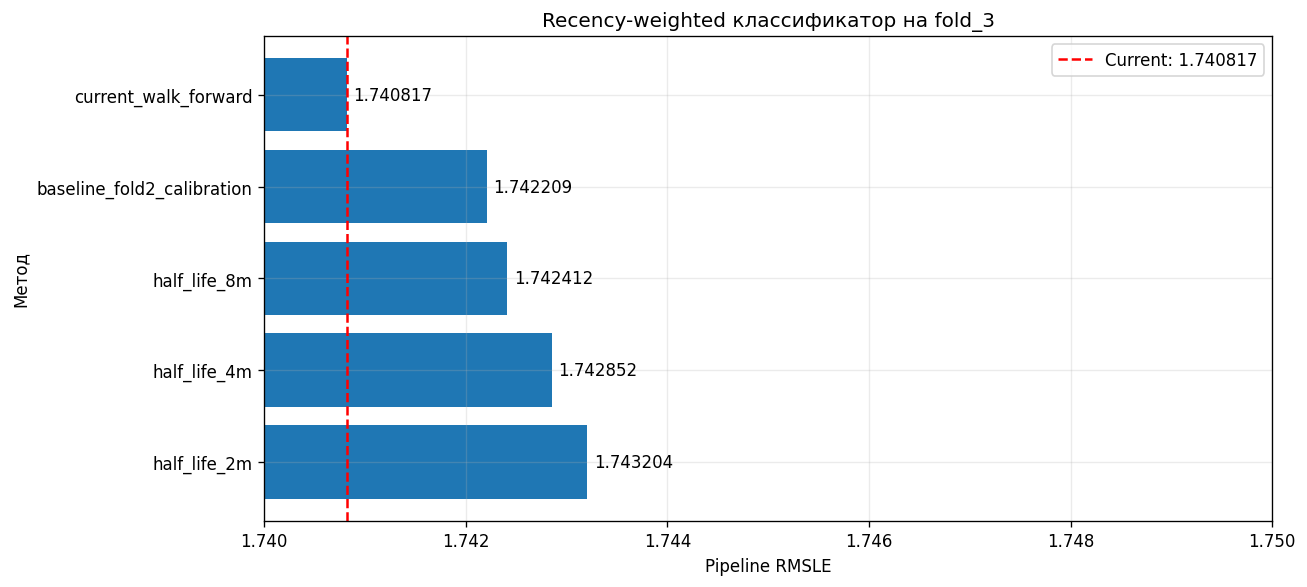

In [73]:
plot_data = recency_evaluation_results.sort_values(
    "pipeline_rmsle",
    ascending=False,
)

fig, axis = plt.subplots(figsize=(11, 5))

bars = axis.barh(
    plot_data.index,
    plot_data["pipeline_rmsle"],
)

axis.axvline(
    reference_rmsle,
    color="red",
    linestyle="--",
    label=f"Current: {reference_rmsle:.6f}",
)

axis.bar_label(
    bars,
    labels=[
        f"{value:.6f}"
        for value in plot_data["pipeline_rmsle"]
    ],
    padding=4,
)

axis.set(
    title="Recency-weighted классификатор на fold_3",
    xlabel="Pipeline RMSLE",
    ylabel="Метод",
    xlim=(1.74, 1.75)
)
axis.legend()
axis.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

Recency weighting нужно отклонить. Лучшим остаётся текущий current_walk_forward с RMSLE 1.740817.

Основные выводы:
- Чем сильнее вес свежих данных, тем хуже результат:
  - 8m: 1.742412
  - 4m: 1.742852
  - 2m: 1.743204
- Recency weighting увеличивает recall, но снижает precision и создаёт больше FP — именно тот тип ошибки, который уже стал проблемой на fold_3.
- F1 немного растёт, но pipeline RMSLE ухудшается. Это хороший пример того, почему нельзя выбирать классификатор только по F1.
- AP, logloss и Brier также ухудшаются — разделение классов объективно не становится лучше.

Есть важный нюанс: baseline_fold2_calibration уже хуже текущего решения на 0.001392, поскольку использует для калибровки только fold_2, тогда как текущий walk-forward использует fold_1 + fold_2. Поэтому чистый эффект weighting правильнее считать относительно этой строки:
- 8m хуже baseline на 0.000203
- 4m — на 0.000643
- 2m — на 0.000995.

То есть большая часть разницы вызвана сокращённой калибровочной выборкой, но само recency weighting тоже последовательно ухудшает качество.

Вывод: старые периоды полезны классификатору как источник отрицательных примеров и стабилизации. Дрейф нельзя исправить простым уменьшением веса истории. Полную OOF-проверку и holdout для этих вариантов проводить не нужно.